In [1]:
import pandas as pd

df_master = pd.read_csv("/kaggle/input/datasets/yoonthiriaung/my-animelist-working-data/myanimelist_cleaned_master_for_ui.csv")

In [2]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mal_id             11500 non-null  int64  
 1   url                11500 non-null  object 
 2   image_url          11500 non-null  object 
 3   trailer_embed_url  5352 non-null   object 
 4   title              11500 non-null  object 
 5   title_english      7182 non-null   object 
 6   title_japanese     11470 non-null  object 
 7   title_synonym      6069 non-null   object 
 8   type               11500 non-null  object 
 9   source             11500 non-null  object 
 10  status             11500 non-null  object 
 11  rating             11500 non-null  object 
 12  score              8401 non-null   float64
 13  scored_by          8401 non-null   float64
 14  rank               11500 non-null  float64
 15  popularity         11500 non-null  int64  
 16  members            115

In [3]:
import ast

def parse_list_col(x):
    """ turn a stringified list like "['Action', 'Adventure']" into an actual list."""

    if isinstance(x, list):
        return x


    if not isinstance(x, str):
        return []

    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except (ValueError, SyntaxError):
        return []

LIST_COLS = ['genres', 'studios','themes', 'producers','demographics']

for col in LIST_COLS:
    df_master[col] = df_master[col].apply(parse_list_col)

df_master[LIST_COLS].head(6)

,genres,studios,themes,producers,demographics
0,"[Action, Drama, Suspense]",[Wit Studio],"[Gore, Military, Survival]","[Production I.G, Dentsu, Mainichi Broadcasting...",[Shounen]
1,"[Supernatural, Suspense]",[Madhouse],[Psychological],"[VAP, Nippon Television Network, Shueisha, D.N...",[Shounen]
2,"[Action, Adventure, Drama, Fantasy]",[Bones],[Military],"[Aniplex, Square Enix, Mainichi Broadcasting S...",[Shounen]
3,"[Action, Comedy]",[Madhouse],"[Adult Cast, Parody, Super Power]","[TV Tokyo, Bandai Visual, Lantis, Asatsu DK, B...",[Seinen]
4,"[Action, Supernatural]",[ufotable],[Historical],"[Aniplex, Studio Mausu, Shueisha]",[Shounen]
5,[Action],[Bones],"[School, Super Power]","[Dentsu, Mainichi Broadcasting System, Movic, ...",[Shounen]


Missing Values Summary:
                n_missing  pct_missing
demographics         6817        59.28
title_english        4318        37.55
themes               3957        34.41
producers            3179        27.64
scored_by            3099        26.95
score                3099        26.95
studios              2772        24.10
genres                162         1.41
title_japanese         30         0.26


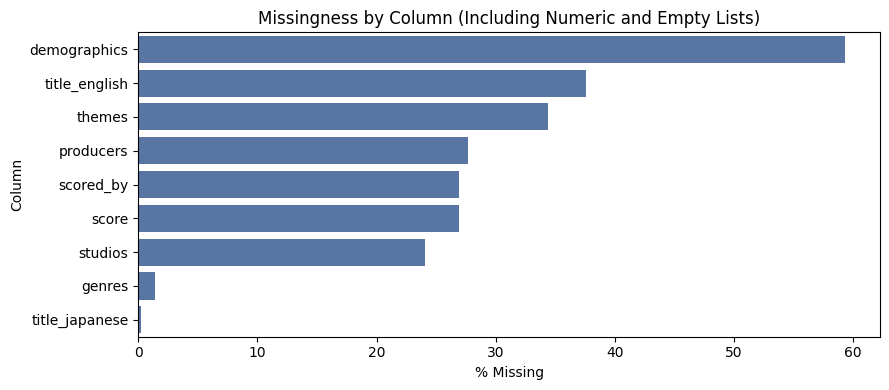

In [7]:
# df master null check

import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. COLUMNS THAT MAY CONTAIN LIST REPRESENTATIONS
# ============================================================

list_cols = [
    "genres",
    "themes",
    "demographics",
    "producers",
    "studios"
]


# ============================================================
# 2. SAFELY CONVERT LIST STRINGS
# ============================================================

def safe_parse_list(x):

    # Already a list
    if isinstance(x, list):
        return np.nan if len(x) == 0 else x

    # Missing value
    if pd.isna(x):
        return np.nan

    # String value
    if isinstance(x, str):

        x = x.strip()

        # Empty string
        if x == "":
            return np.nan

        # Looks like a list
        if x.startswith("[") and x.endswith("]"):

            try:
                value = ast.literal_eval(x)

                if isinstance(value, list):
                    return np.nan if len(value) == 0 else value

            except (ValueError, SyntaxError):
                return x

        return x

    return x


# Apply ONLY to list columns
for col in list_cols:
    df_master[col] = df_master[col].apply(safe_parse_list)


# ============================================================
# 3. COLUMNS TO INCLUDE IN MISSING-VALUE ANALYSIS
# ============================================================

numeric_cols = [
    "score",
    "scored_by",
    "rank",
    "popularity",
    "members",
    "favorites",
    "year",
    "episodes",
    "duration_minutes"
]

categorical_cols = [
    "title_english",
    "title_japanese",
    "type",
    "source",
    "status",
    "rating",
    "season",
    "broadcast_day",
    "synopsis"
]

# Combine list + categorical + numeric columns
missing_check_cols = (
    list_cols
    + categorical_cols
    + numeric_cols
)


# Keep only columns that actually exist
missing_check_cols = [
    col for col in missing_check_cols
    if col in df_master.columns
]


# ============================================================
# 4. CREATE MISSING VALUE SUMMARY
# ============================================================

missing = pd.DataFrame({
    "n_missing": df_master[missing_check_cols].isnull().sum(),
    "pct_missing": (
        df_master[missing_check_cols].isnull().sum()
        / len(df_master)
        * 100
    ).round(2)
})


# Only columns with missing values
missing = missing[
    missing["n_missing"] > 0
].sort_values(
    "pct_missing",
    ascending=False
)


# ============================================================
# 5. PRINT SUMMARY
# ============================================================

print("Missing Values Summary:")
print(missing)


# ============================================================
# 6. VISUALIZE MISSING VALUES
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, max(4, len(missing) * 0.35))
)

sns.barplot(
    x=missing["pct_missing"],
    y=missing.index,
    ax=ax,
    color="#4C72B0"
)

ax.set_xlabel("% Missing")
ax.set_ylabel("Column")
ax.set_title(
    "Missingness by Column (Including Numeric and Empty Lists)"
)

plt.tight_layout()
plt.show()

## in here we will drop the score and scored_by null to do the later data mining. drop entirely from my dataset bc myanimelist doesn't even provide the official score and also there are many missing in the studios, themes and producers bc of the api error and can't scracb anymore so i will reduce by dropping the null score and score_by and see how many left 

In [8]:
df_clean= df_master.copy()


df_clean= df_clean[df_clean['scored_by'].notna()].copy()
df_clean = df_clean[df_clean['score'].notna()].copy()
df_clean = df_clean[df_clean["synopsis_clean"].notna()].copy()

In [17]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8227 entries, 0 to 9485
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mal_id             8227 non-null   int64  
 1   url                8227 non-null   object 
 2   image_url          8227 non-null   object 
 3   trailer_embed_url  5050 non-null   object 
 4   title              8227 non-null   object 
 5   title_english      5979 non-null   object 
 6   title_japanese     8209 non-null   object 
 7   title_synonym      5026 non-null   object 
 8   type               8227 non-null   object 
 9   source             8227 non-null   object 
 10  status             8227 non-null   object 
 11  rating             8227 non-null   object 
 12  score              8227 non-null   float64
 13  scored_by          8227 non-null   float64
 14  rank               8227 non-null   float64
 15  popularity         8227 non-null   int64  
 16  members            8227 non-n

Missing Values Summary:
                n_missing  pct_missing
demographics         5438        66.10
title_english        2248        27.32
themes               2145        26.07
producers             573         6.96
studios               559         6.79
title_japanese         18         0.22


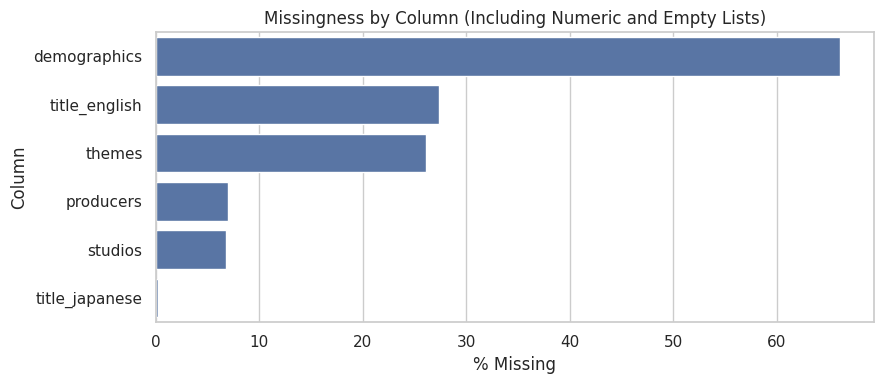

In [18]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# 1. COLUMNS THAT MAY CONTAIN LIST REPRESENTATIONS
# ============================================================

list_cols = [
    "genres",
    "themes",
    "demographics",
    "producers",
    "studios"
]


# ============================================================
# 2. SAFELY CONVERT LIST STRINGS
# ============================================================

def safe_parse_list(x):

    # Already a list
    if isinstance(x, list):
        return np.nan if len(x) == 0 else x

    # Missing value
    if pd.isna(x):
        return np.nan

    # String value
    if isinstance(x, str):

        x = x.strip()

        # Empty string
        if x == "":
            return np.nan

        # Looks like a list
        if x.startswith("[") and x.endswith("]"):

            try:
                value = ast.literal_eval(x)

                if isinstance(value, list):
                    return np.nan if len(value) == 0 else value

            except (ValueError, SyntaxError):
                return x

        return x

    return x


# Apply ONLY to list columns
for col in list_cols:
    df_clean[col] = df_clean[col].apply(safe_parse_list)


# ============================================================
# 3. COLUMNS TO INCLUDE IN MISSING-VALUE ANALYSIS
# ============================================================

numeric_cols = [
    "score",
    "scored_by",
    "rank",
    "popularity",
    "members",
    "favorites",
    "year",
    "episodes",
    "duration_minutes"
]

categorical_cols = [
    "title_english",
    "title_japanese",
    "type",
    "source",
    "status",
    "rating",
    "season",
    "broadcast_day",
    "synopsis_clean"
]

# Combine list + categorical + numeric columns
missing_check_cols = (
    list_cols
    + categorical_cols
    + numeric_cols
)


# Keep only columns that actually exist
missing_check_cols = [
    col for col in missing_check_cols
    if col in df_clean.columns
]


# ============================================================
# 4. CREATE MISSING VALUE SUMMARY
# ============================================================

missing = pd.DataFrame({
    "n_missing": df_clean[missing_check_cols].isnull().sum(),
    "pct_missing": (
        df_clean[missing_check_cols].isnull().sum()
        / len(df_clean)
        * 100
    ).round(2)
})


# Only columns with missing values
missing = missing[
    missing["n_missing"] > 0
].sort_values(
    "pct_missing",
    ascending=False
)


# ============================================================
# 5. PRINT SUMMARY
# ============================================================

print("Missing Values Summary:")
print(missing)


# ============================================================
# 6. VISUALIZE MISSING VALUES
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, max(4, len(missing) * 0.35))
)

sns.barplot(
    x=missing["pct_missing"],
    y=missing.index,
    ax=ax,
    color="#4C72B0"
)

ax.set_xlabel("% Missing")
ax.set_ylabel("Column")
ax.set_title(
    "Missingness by Column (Including Numeric and Empty Lists)"
)

plt.tight_layout()
plt.show()

# in here we can ignore : title japanese and title_english we will impute "Unkown" for the producers and studios and themse and demographics ( demo are just not described by the data itself , not scrapping error ) 

# Data Distribution for categorical columns

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


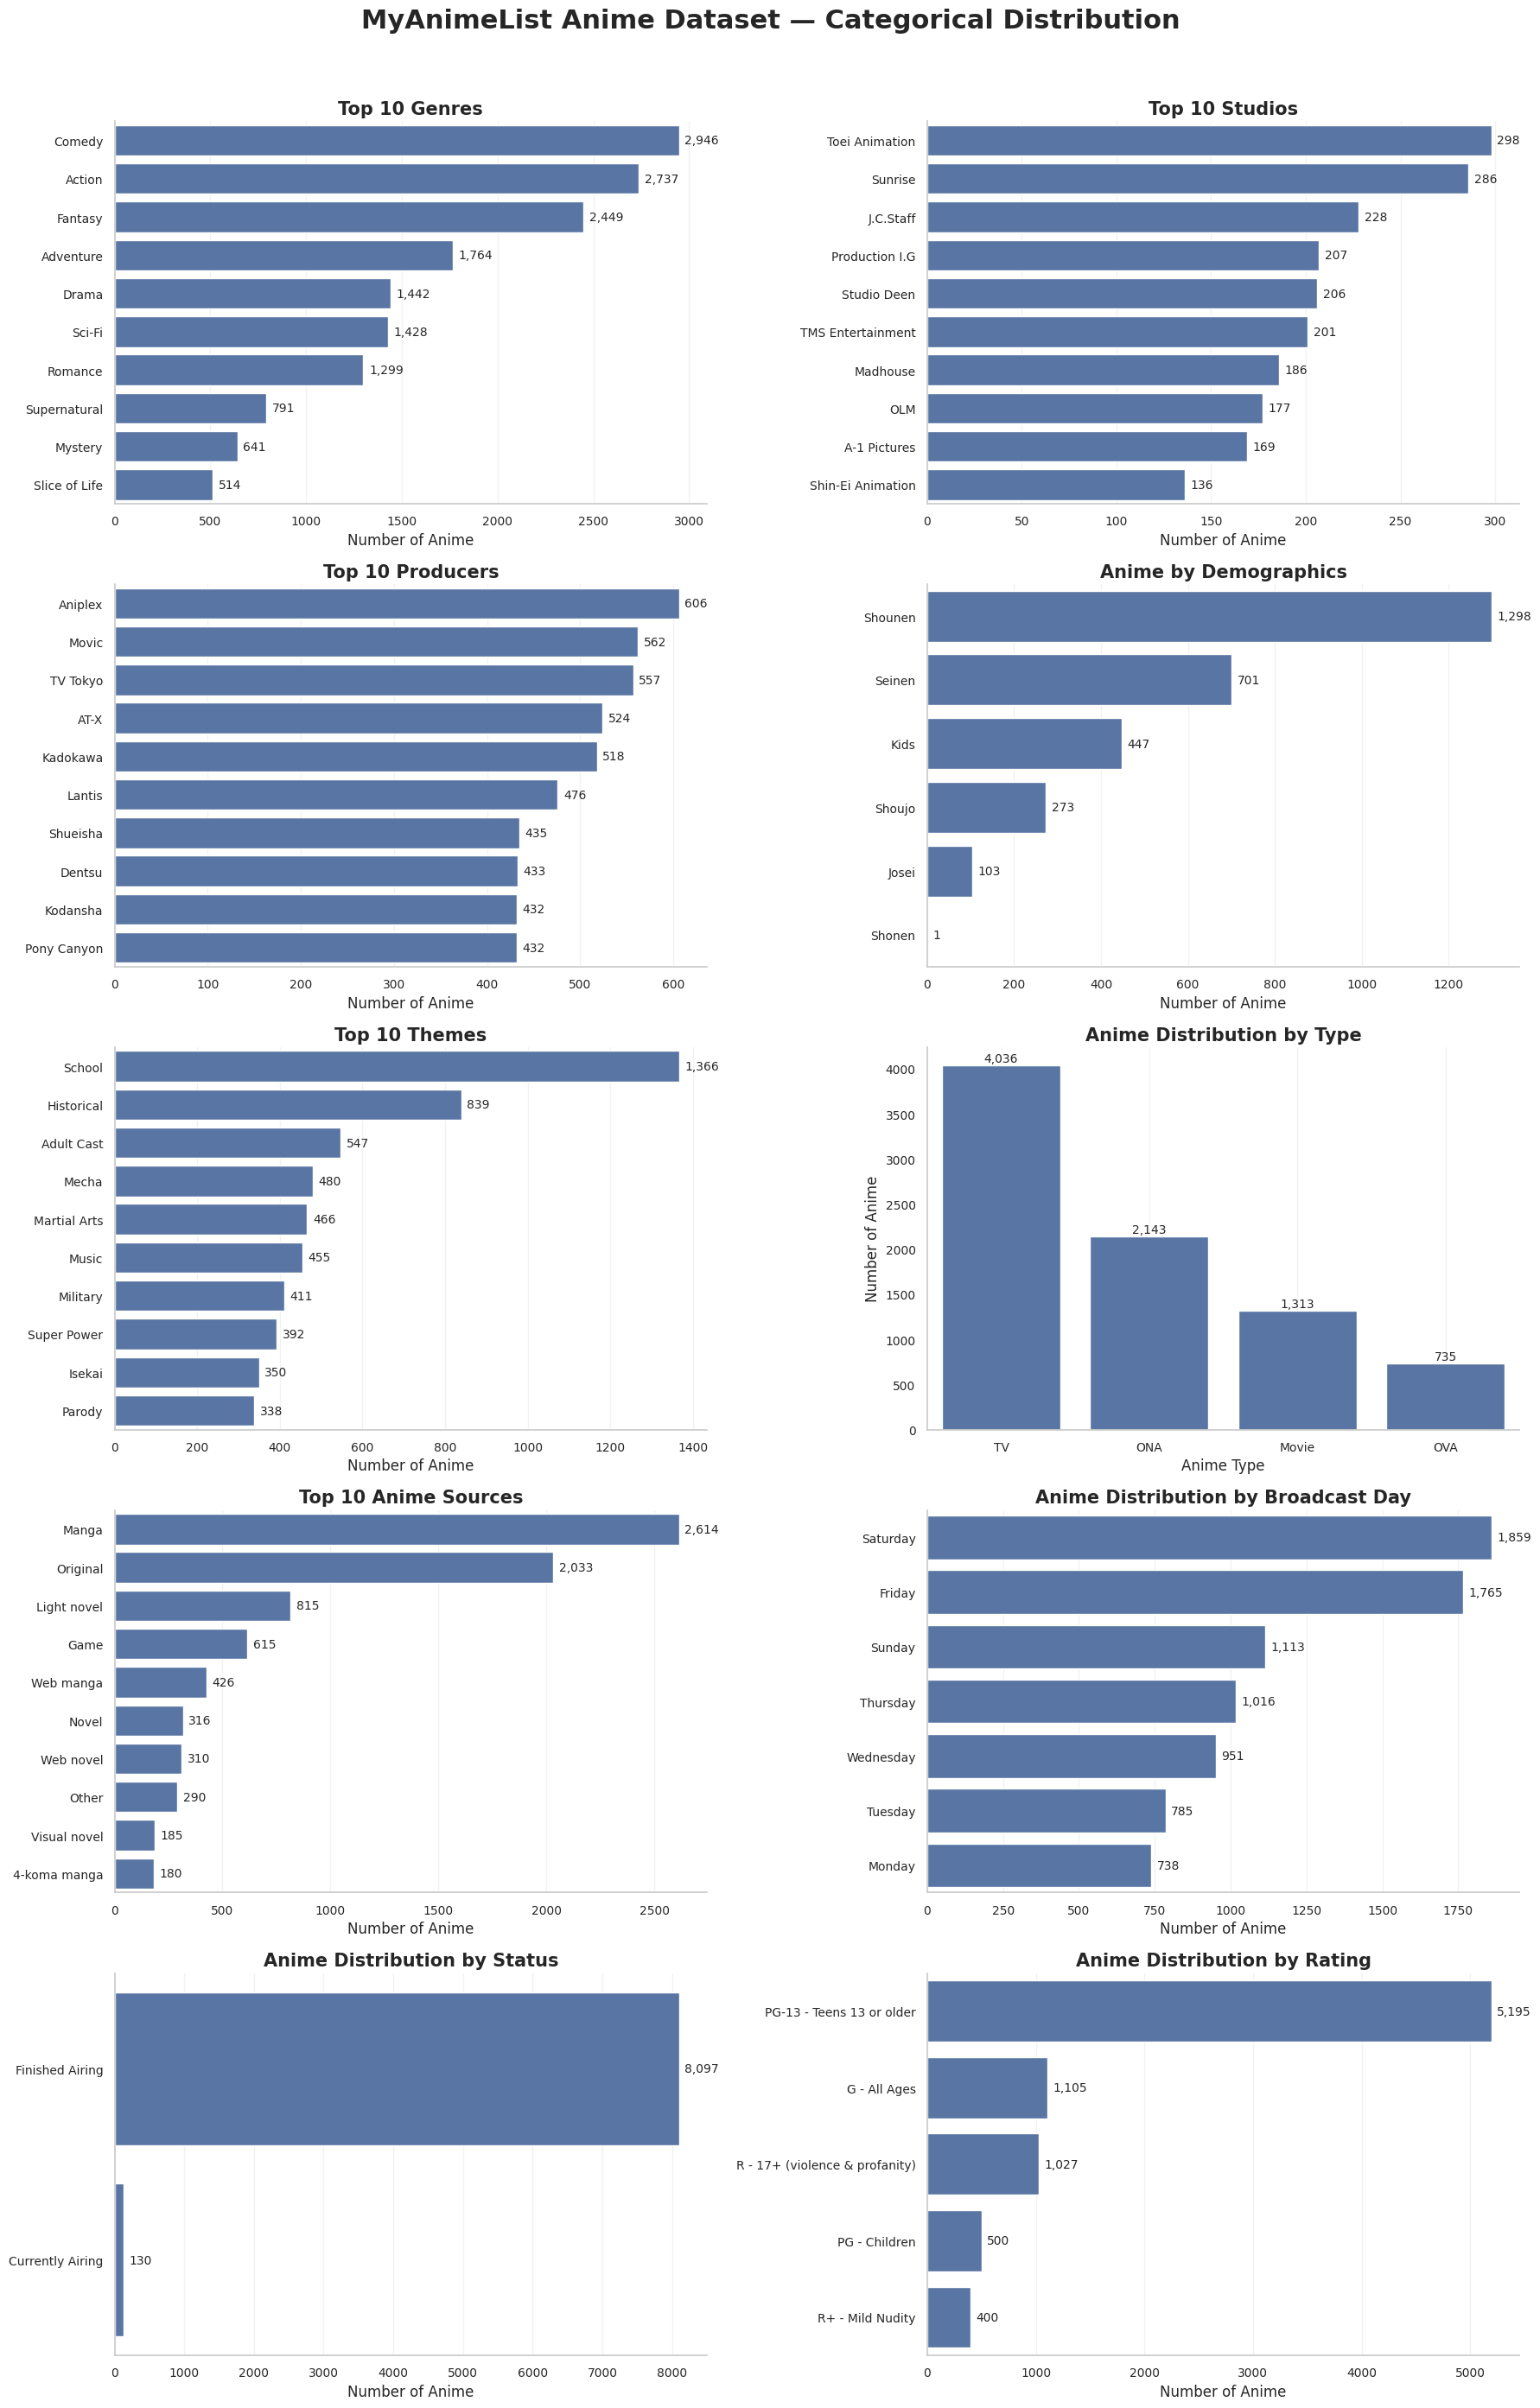

In [19]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# SETTINGS
# ============================================================

TOP_N = 10

sns.set_theme(
    style="whitegrid",
    context="notebook"
)


# ============================================================
# 1. SAFELY CONVERT LIST COLUMNS
# ============================================================

list_cols = [
    "genres",
    "studios",
    "producers",
    "demographics",
    "themes"
]


def safe_parse_list(x):

    if isinstance(x, list):
        return x if len(x) > 0 else np.nan

    if pd.isna(x):
        return np.nan

    if isinstance(x, str):

        x = x.strip()

        if x == "":
            return np.nan

        if x.startswith("[") and x.endswith("]"):

            try:
                value = ast.literal_eval(x)

                if isinstance(value, list):
                    return value if len(value) > 0 else np.nan

            except (ValueError, SyntaxError):
                return x

        return x

    return x


for col in list_cols:
    df_clean[col] = df_clean[col].apply(safe_parse_list)


# ============================================================
# 2. FUNCTION FOR LIST-COLUMN COUNTS
# ============================================================

def get_list_counts(df, column, top_n=10):

    temp = df[[column]].dropna().copy()

    # One anime can have multiple values
    temp = temp.explode(column)

    temp[column] = (
        temp[column]
        .astype(str)
        .str.strip()
    )

    temp = temp[temp[column] != ""]

    return temp[column].value_counts().head(top_n)


# ============================================================
# 3. CREATE FIGURE — 2 COLUMNS
# ============================================================

fig, axes = plt.subplots(
    5, 2,
    figsize=(18, 28)
)

axes = axes.flatten()


# ============================================================
# 4. GENRES
# ============================================================

counts = get_list_counts(
    df_clean,
    "genres",
    TOP_N
)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[0]
)

axes[0].set_title(
    "Top 10 Genres",
    fontsize=15,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Anime")
axes[0].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[0].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 5. STUDIOS
# ============================================================

counts = get_list_counts(
    df_clean,
    "studios",
    TOP_N
)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[1]
)

axes[1].set_title(
    "Top 10 Studios",
    fontsize=15,
    fontweight="bold"
)

axes[1].set_xlabel("Number of Anime")
axes[1].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[1].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 6. PRODUCERS
# ============================================================

counts = get_list_counts(
    df_clean,
    "producers",
    TOP_N
)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[2]
)

axes[2].set_title(
    "Top 10 Producers",
    fontsize=15,
    fontweight="bold"
)

axes[2].set_xlabel("Number of Anime")
axes[2].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[2].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 7. DEMOGRAPHICS
# ============================================================

counts = get_list_counts(
    df_clean,
    "demographics",
    TOP_N
)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[3]
)

axes[3].set_title(
    "Anime by Demographics",
    fontsize=15,
    fontweight="bold"
)

axes[3].set_xlabel("Number of Anime")
axes[3].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[3].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 8. THEMES
# ============================================================

counts = get_list_counts(
    df_clean,
    "themes",
    TOP_N
)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[4]
)

axes[4].set_title(
    "Top 10 Themes",
    fontsize=15,
    fontweight="bold"
)

axes[4].set_xlabel("Number of Anime")
axes[4].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[4].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 9. TYPE
# ============================================================

counts = df_clean["type"].value_counts()

sns.barplot(
    x=counts.index,
    y=counts.values,
    ax=axes[5]
)

axes[5].set_title(
    "Anime Distribution by Type",
    fontsize=15,
    fontweight="bold"
)

axes[5].set_xlabel("Anime Type")
axes[5].set_ylabel("Number of Anime")

for i, v in enumerate(counts.values):
    axes[5].text(
        i,
        v + max(counts.values) * 0.01,
        f"{v:,}",
        ha="center",
        fontsize=10
    )


# ============================================================
# 10. SOURCE
# ============================================================

counts = df_clean["source"].value_counts().head(TOP_N)

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[6]
)

axes[6].set_title(
    "Top 10 Anime Sources",
    fontsize=15,
    fontweight="bold"
)

axes[6].set_xlabel("Number of Anime")
axes[6].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[6].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 11. BROADCAST DAY
# ============================================================

counts = df_clean["broadcast_day"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[7]
)

axes[7].set_title(
    "Anime Distribution by Broadcast Day",
    fontsize=15,
    fontweight="bold"
)

axes[7].set_xlabel("Number of Anime")
axes[7].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[7].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 12. STATUS
# ============================================================

counts = df_clean["status"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[8]
)

axes[8].set_title(
    "Anime Distribution by Status",
    fontsize=15,
    fontweight="bold"
)

axes[8].set_xlabel("Number of Anime")
axes[8].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[8].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 13. RATING
# ============================================================

counts = df_clean["rating"].value_counts()

sns.barplot(
    x=counts.values,
    y=counts.index,
    ax=axes[9]
)

axes[9].set_title(
    "Anime Distribution by Rating",
    fontsize=15,
    fontweight="bold"
)

axes[9].set_xlabel("Number of Anime")
axes[9].set_ylabel("")

for i, v in enumerate(counts.values):
    axes[9].text(
        v + max(counts.values) * 0.01,
        i,
        f"{v:,}",
        va="center",
        fontsize=10
    )


# ============================================================
# 14. FINAL FORMATTING
# ============================================================

for ax in axes:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="x",
        alpha=0.25
    )

    ax.grid(
        axis="y",
        visible=False
    )

    ax.tick_params(
        axis="both",
        labelsize=10
    )


fig.suptitle(
    "MyAnimeList Anime Dataset — Categorical Distribution",
    fontsize=22,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)

plt.show()

# Data Distribution of Numeric columns

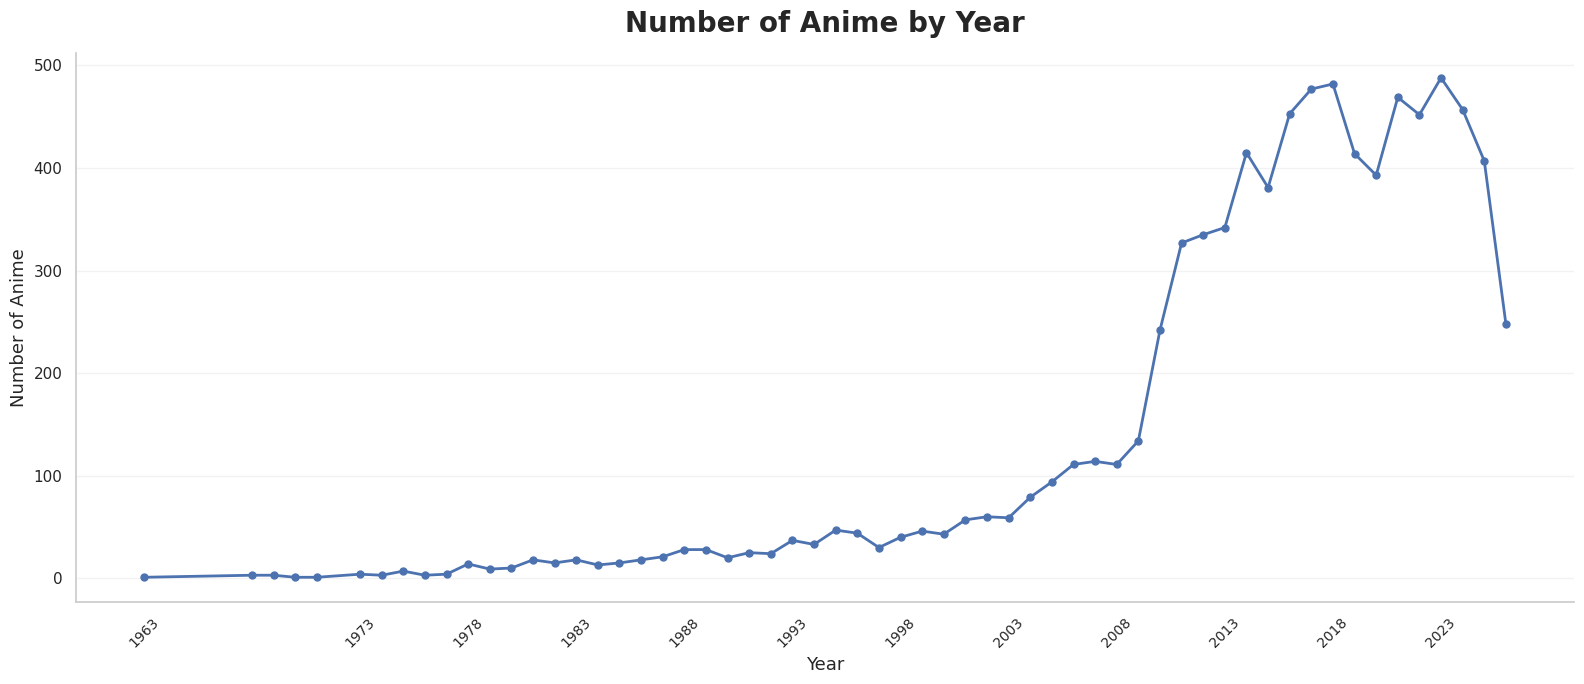

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


year_counts = (
    df_clean["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)


fig, ax = plt.subplots(
    figsize=(16, 7)
)

ax.plot(
    year_counts.index,
    year_counts.values,
    marker="o",
    markersize=5,
    linewidth=2
)


ax.set_title(
    "Number of Anime by Year",
    fontsize=20,
    fontweight="bold",
    pad=15
)

ax.set_xlabel(
    "Year",
    fontsize=13
)

ax.set_ylabel(
    "Number of Anime",
    fontsize=13
)


years = year_counts.index

ax.set_xticks(
    years[::5]
)

ax.tick_params(
    axis="x",
    rotation=45,
    labelsize=10
)


ax.grid(
    axis="y",
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

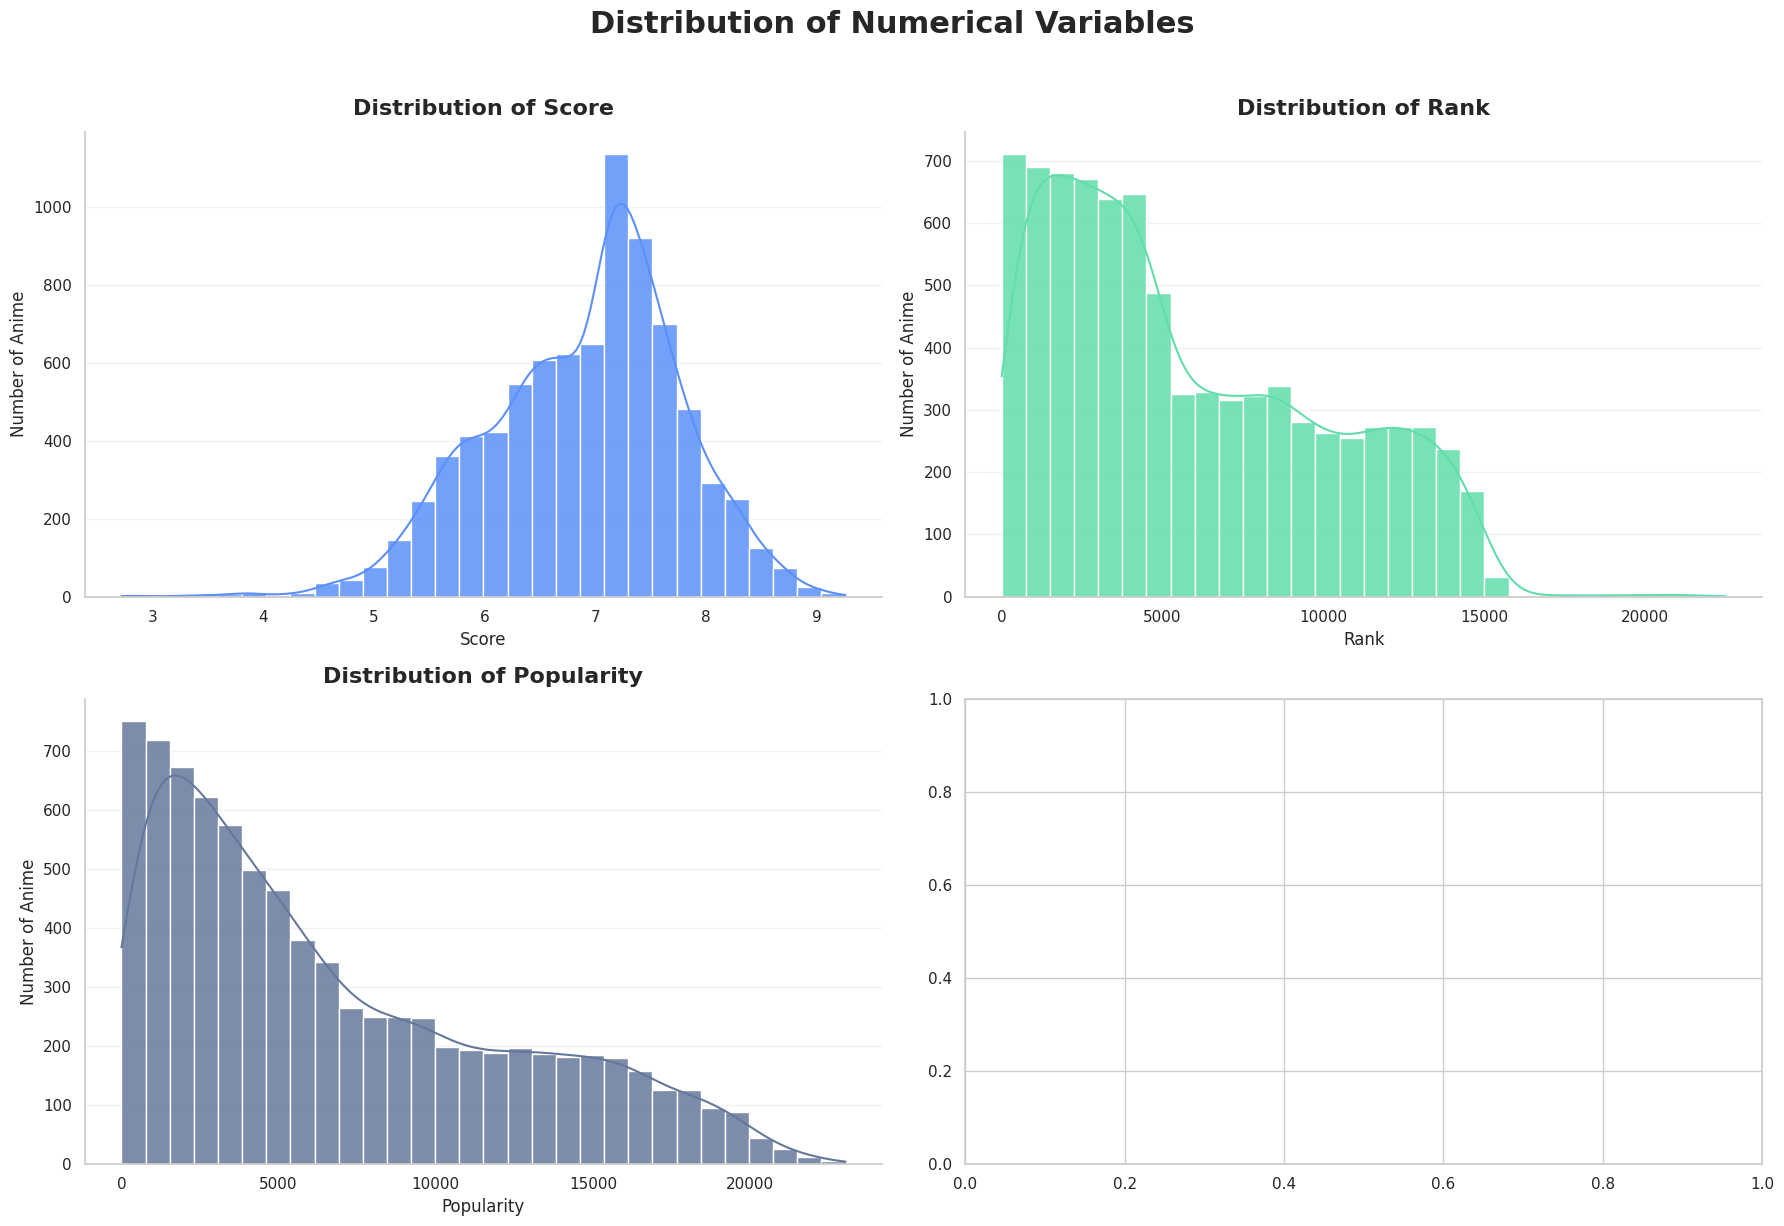

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# ------------------------------------------------------------
# Numeric columns
# ------------------------------------------------------------

numeric_cols = [
    "score",
    "rank",
    "popularity"
]

# ------------------------------------------------------------
# Pretty color palette
# ------------------------------------------------------------

colors = [
    "#5B8FF9",
    "#61DDAA",
    "#65789B",
    "#F6BD16"
]

# ------------------------------------------------------------
# Create 2-column layout
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(18, 12)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    data = df_clean[col].dropna()

    sns.histplot(
        data=data,
        bins=30,
        kde=True,
        ax=axes[i],
        color=colors[i],
        edgecolor="white",
        alpha=0.85
    )

    axes[i].set_title(
        f"Distribution of {col.replace('_', ' ').title()}",
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    axes[i].set_xlabel(
        col.replace("_", " ").title(),
        fontsize=12
    )

    axes[i].set_ylabel(
        "Number of Anime",
        fontsize=12
    )

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    axes[i].grid(
        axis="y",
        alpha=0.25
    )

    axes[i].grid(
        axis="x",
        visible=False
    )

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

Score: Approximately bell-shaped, centered around 7.0–7.5, indicating that most anime receive moderate-to-high ratings.
Rank: Concentrated toward lower rank values with a long right tail, showing that most anime have relatively better ranks while fewer have very high rank numbers.
Popularity: Strongly right-skewed, with most anime having lower popularity values and a small number of anime being extremely popular.

# Scored by original vs log scale

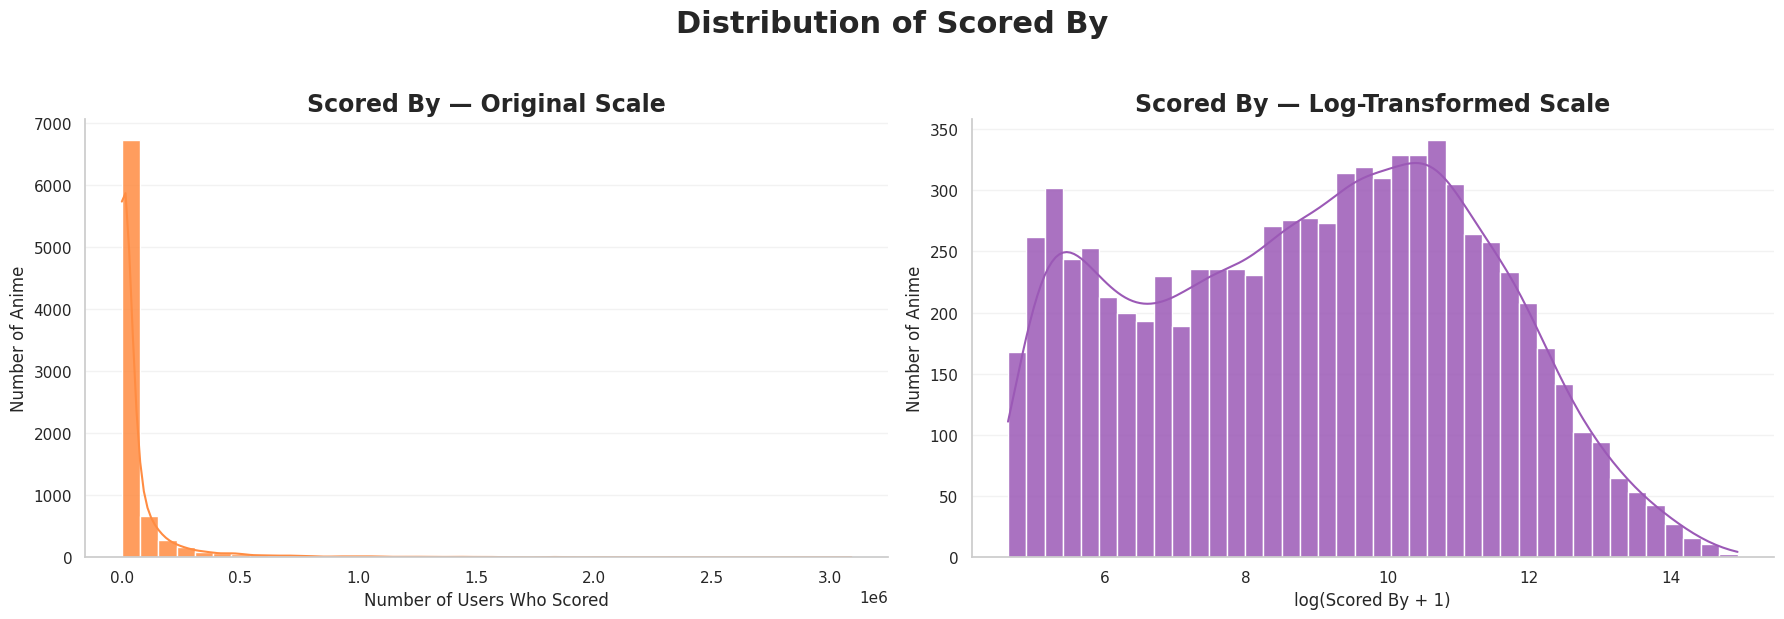

In [23]:
scored_by = df_clean["scored_by"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6)
)

# ------------------------------------------------------------
# Original scale
# ------------------------------------------------------------

sns.histplot(
    scored_by,
    bins=40,
    kde=True,
    ax=axes[0],
    color="#FF8C42",
    edgecolor="white",
    alpha=0.85
)

axes[0].set_title(
    "Scored By — Original Scale",
    fontsize=17,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Users Who Scored")
axes[0].set_ylabel("Number of Anime")

# ------------------------------------------------------------
# Log scale
# ------------------------------------------------------------

sns.histplot(
    np.log1p(scored_by),
    bins=40,
    kde=True,
    ax=axes[1],
    color="#9B59B6",
    edgecolor="white",
    alpha=0.85
)

axes[1].set_title(
    "Scored By — Log-Transformed Scale",
    fontsize=17,
    fontweight="bold"
)

axes[1].set_xlabel("log(Scored By + 1)")
axes[1].set_ylabel("Number of Anime")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

plt.suptitle(
    "Distribution of Scored By",
    fontsize=22,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# Members original vs log scale

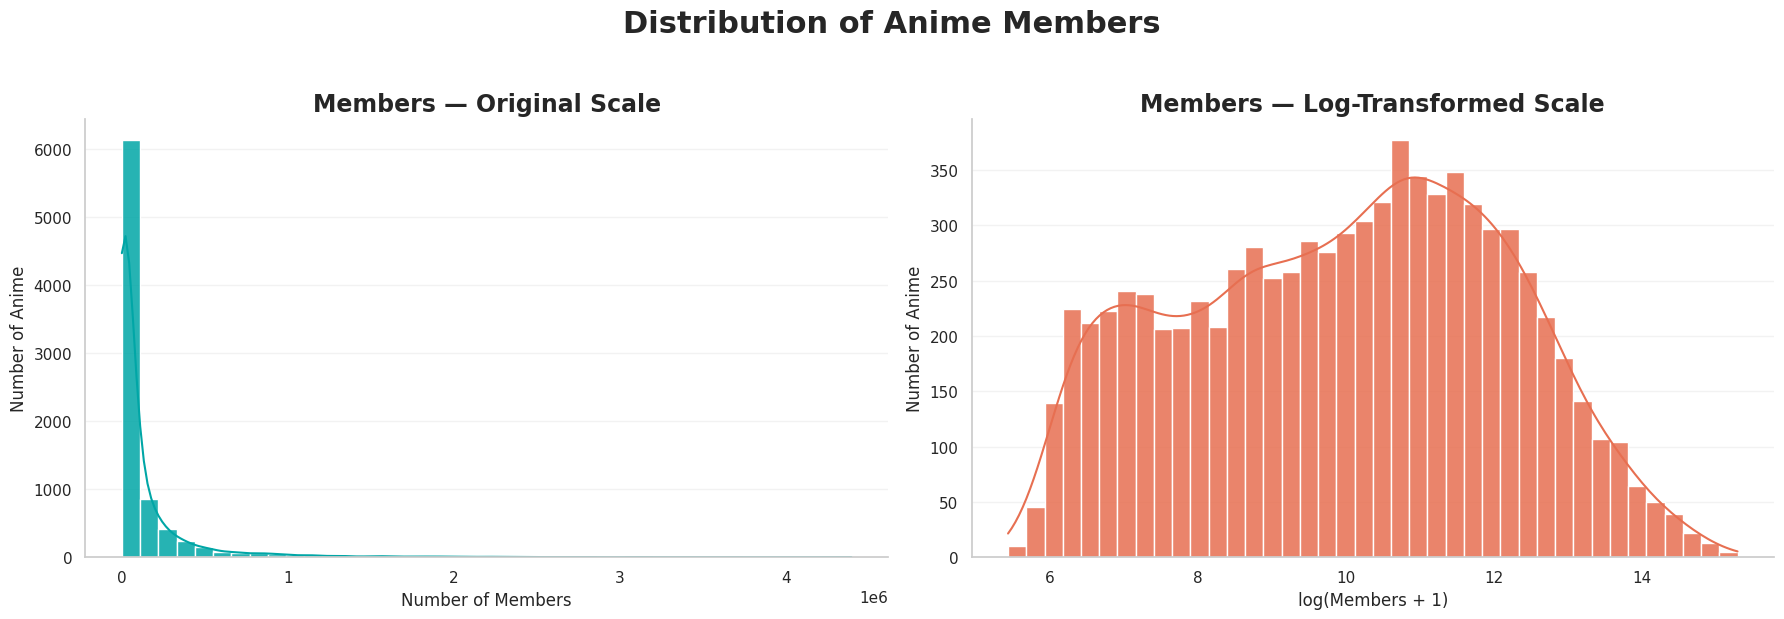

In [24]:
members = df_clean["members"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6)
)

# Original
sns.histplot(
    members,
    bins=40,
    kde=True,
    ax=axes[0],
    color="#00A6A6",
    edgecolor="white",
    alpha=0.85
)

axes[0].set_title(
    "Members — Original Scale",
    fontsize=17,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Members")
axes[0].set_ylabel("Number of Anime")

# Log transformed
sns.histplot(
    np.log1p(members),
    bins=40,
    kde=True,
    ax=axes[1],
    color="#E76F51",
    edgecolor="white",
    alpha=0.85
)

axes[1].set_title(
    "Members — Log-Transformed Scale",
    fontsize=17,
    fontweight="bold"
)

axes[1].set_xlabel("log(Members + 1)")
axes[1].set_ylabel("Number of Anime")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

plt.suptitle(
    "Distribution of Anime Members",
    fontsize=22,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# Favorite Original vs log scale

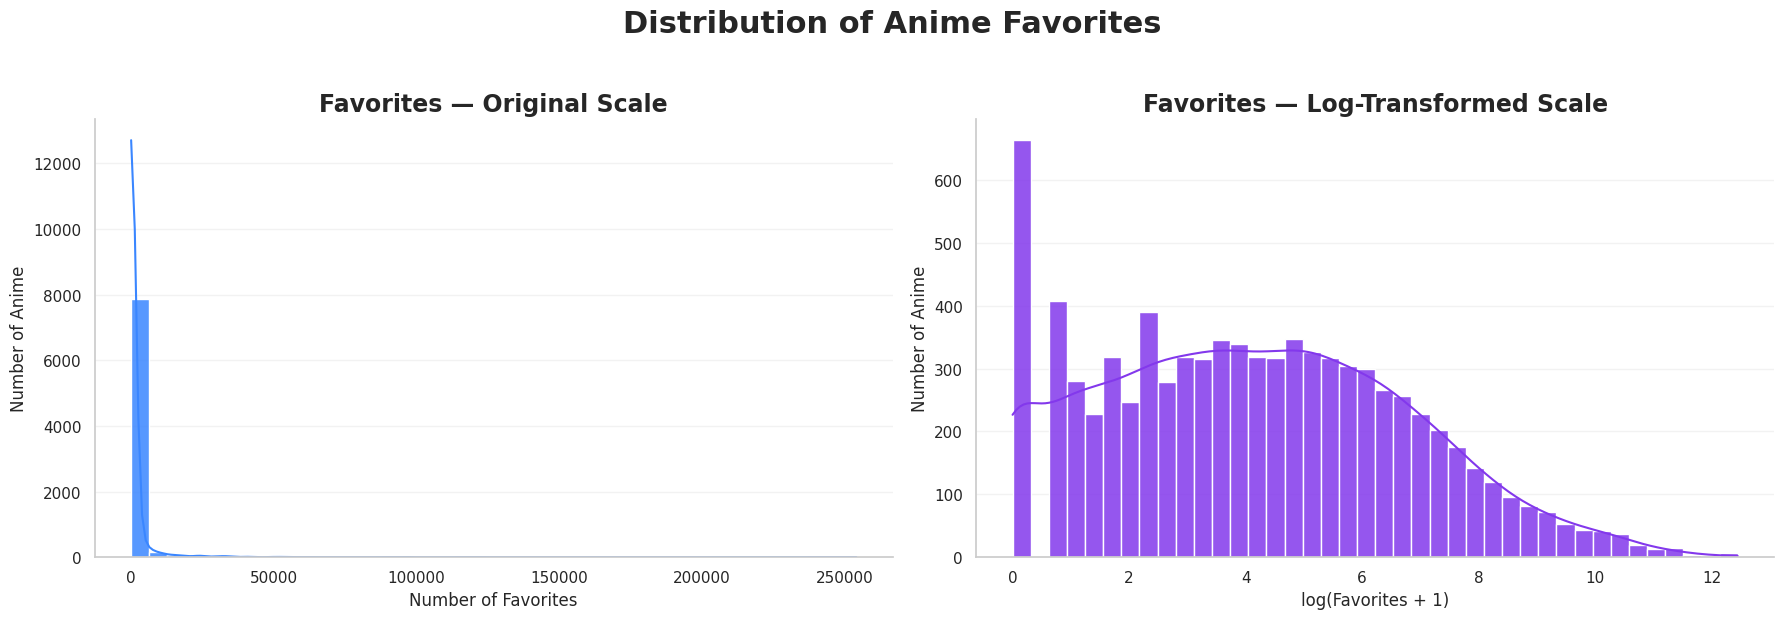

In [25]:
favorites = df_clean["favorites"].dropna()

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 6)
)

# Original
sns.histplot(
    favorites,
    bins=40,
    kde=True,
    ax=axes[0],
    color="#3A86FF",
    edgecolor="white",
    alpha=0.85
)

axes[0].set_title(
    "Favorites — Original Scale",
    fontsize=17,
    fontweight="bold"
)

axes[0].set_xlabel("Number of Favorites")
axes[0].set_ylabel("Number of Anime")

# Log transformed
sns.histplot(
    np.log1p(favorites),
    bins=40,
    kde=True,
    ax=axes[1],
    color="#8338EC",
    edgecolor="white",
    alpha=0.85
)

axes[1].set_title(
    "Favorites — Log-Transformed Scale",
    fontsize=17,
    fontweight="bold"
)

axes[1].set_xlabel("log(Favorites + 1)")
axes[1].set_ylabel("Number of Anime")

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

plt.suptitle(
    "Distribution of Anime Favorites",
    fontsize=22,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

# Episode by anime type (TV,ONA, OVA, Movie)

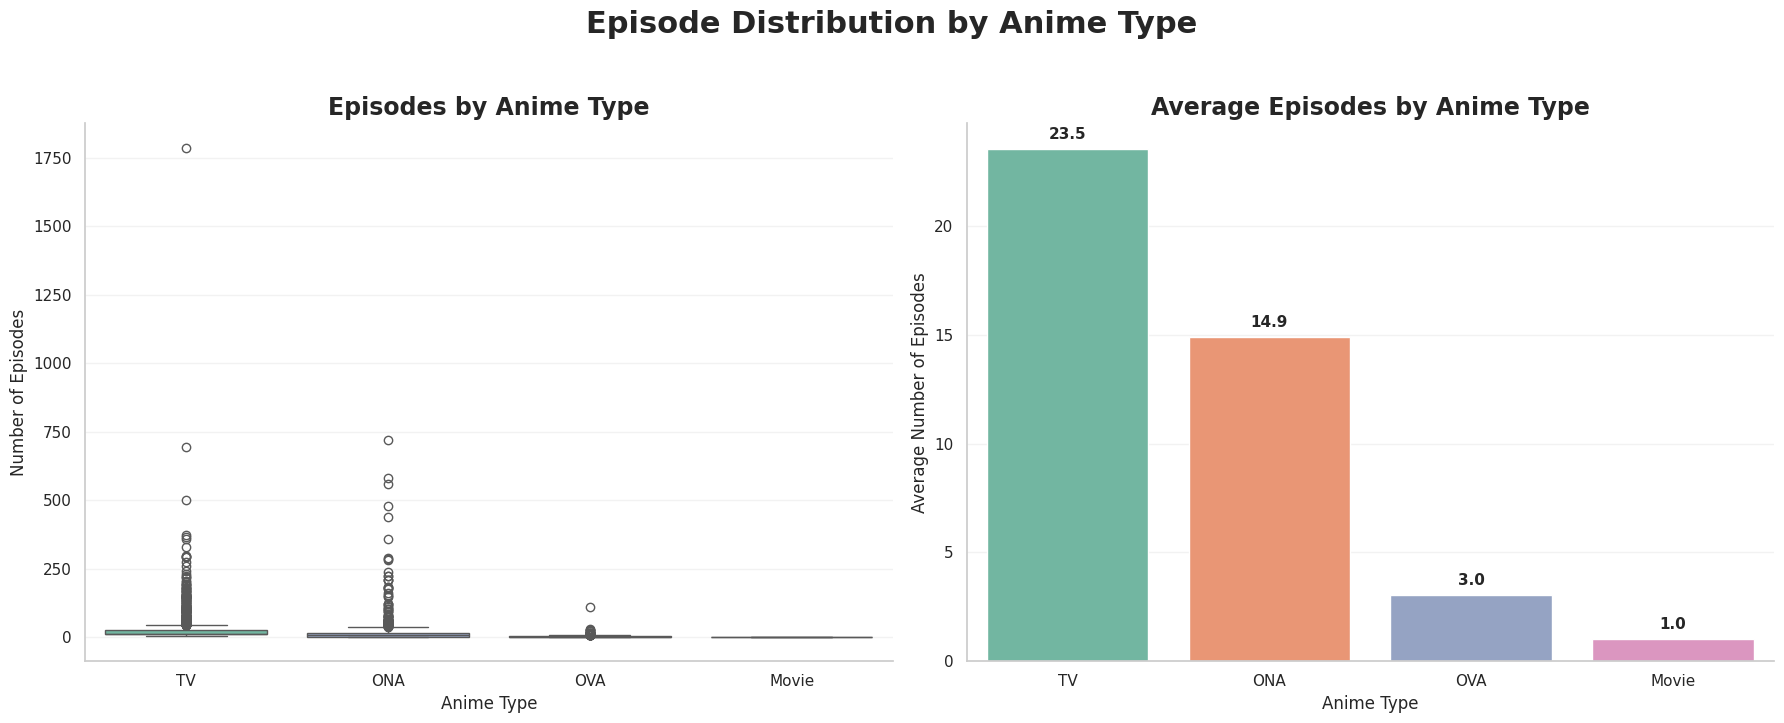

In [26]:
# ------------------------------------------------------------
# Prepare episode data
# ------------------------------------------------------------

episode_data = df_clean[
    df_clean["type"].isin(["TV", "ONA", "OVA", "Movie"])
].copy()

episode_data = episode_data.dropna(
    subset=["episodes", "type"]
)

type_order = ["TV", "ONA", "OVA", "Movie"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7)
)

# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

sns.boxplot(
    data=episode_data,
    x="type",
    y="episodes",
    order=type_order,
    ax=axes[0],
    hue="type",
    palette="Set2",
    legend=False
)

axes[0].set_title(
    "Episodes by Anime Type",
    fontsize=17,
    fontweight="bold"
)

axes[0].set_xlabel("Anime Type")
axes[0].set_ylabel("Number of Episodes")

# ------------------------------------------------------------
# Mean episodes
# ------------------------------------------------------------

mean_episode = (
    episode_data
    .groupby("type")["episodes"]
    .mean()
    .reindex(type_order)
)

sns.barplot(
    x=mean_episode.index,
    y=mean_episode.values,
    ax=axes[1],
    hue=mean_episode.index,
    palette="Set2",
    legend=False
)

for i, value in enumerate(mean_episode.values):
    axes[1].text(
        i,
        value + max(mean_episode.values) * 0.02,
        f"{value:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

axes[1].set_title(
    "Average Episodes by Anime Type",
    fontsize=17,
    fontweight="bold"
)

axes[1].set_xlabel("Anime Type")
axes[1].set_ylabel("Average Number of Episodes")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

plt.suptitle(
    "Episode Distribution by Anime Type",
    fontsize=22,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

In [39]:
df_clean.groupby('type')['episodes'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,1313.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
ONA,2143.0,14.913672,36.172885,1.0,1.0,8.0,15.0,720.0
OVA,735.0,3.047619,5.305045,1.0,1.0,1.0,3.0,110.0
TV,4036.0,23.545094,40.721561,3.0,12.0,13.0,25.0,1787.0


### The episode count was highly right-skewed across ONA, OVA, and TV anime. Although the IQR method identified several statistical outliers, these observations were retained because unusually high episode counts can represent legitimate long-running anime rather than erroneous records. Log transformation was considered to reduce the influence of extreme values during modeling.

# Duration minutes by Anime Type

In [41]:
df_clean.groupby('type')['duration_minutes'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,1313.0,82.801219,29.572038,15.0,62.0,90.0,103.0,168.0
ONA,2143.0,12.305180,13.886569,1.0,3.0,9.0,19.0,140.0
OVA,735.0,28.700680,15.219294,10.0,23.0,25.0,29.0,161.0
TV,4036.0,21.395193,5.945783,3.0,23.0,23.0,24.0,49.0


In [49]:
df_clean.sort_values('duration_minutes', ascending=False)[
    ['title', 'type', 'duration_minutes']
].head(5)

,title,type,duration_minutes
1294,Kono Sekai no Katasumi ni,Movie,168.0
3771,Koukaku Kidoutai: Stand Alone Complex 2nd GIG ...,OVA,161.0
373,Suzumiya Haruhi no Shoushitsu,Movie,161.0
3376,Koukaku Kidoutai: Stand Alone Complex - The La...,OVA,160.0
618,Shin Evangelion Movie:||,Movie,155.0


In [50]:
df_clean.sort_values('duration_minutes', ascending=True)[
    ['title', 'type', 'duration_minutes']
].head(5)

,title,type,duration_minutes
6179,Arifureta Shokugyou de Sekai Saikyou Picture D...,ONA,1.0
6180,Shiroi Suna no Aquatope Mini,ONA,1.0
8932,Funi Funi Marshmallow,ONA,1.0
8942,Bao Ke Meng Donghua Tujian: Xinao Yi Xia,ONA,1.0
8928,MAFF x Chobitto Zukan,ONA,1.0


In [48]:
df_clean[df_clean['duration_minutes'] <= 0][
    ['title', 'type', 'duration_minutes']
]

,title,type,duration_minutes


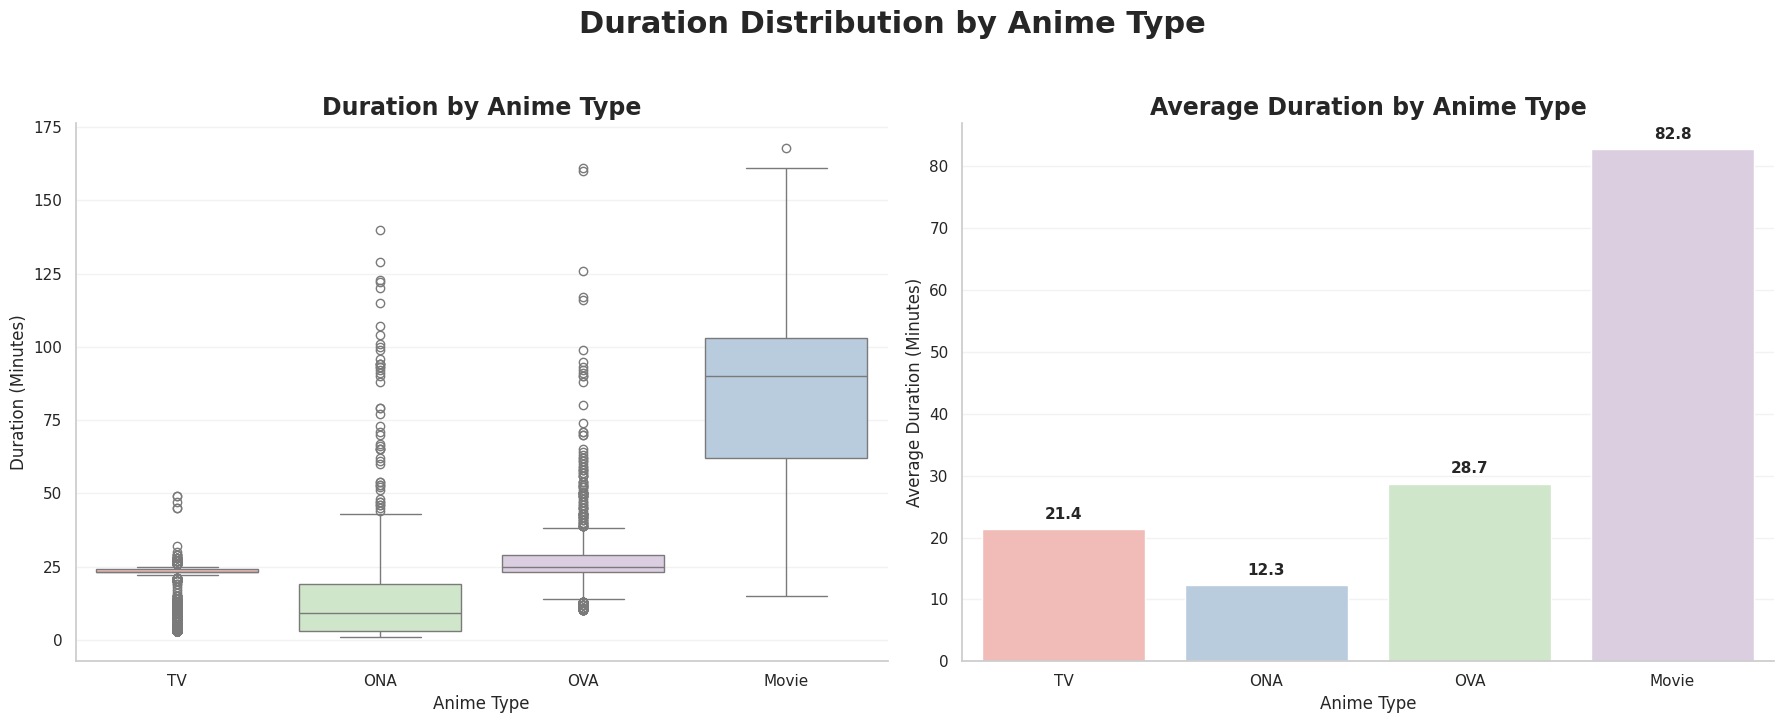

In [29]:
# ------------------------------------------------------------
# Prepare duration data
# ------------------------------------------------------------

duration_data = df_clean[
    df_clean["type"].isin(["TV", "ONA", "OVA", "Movie"])
].copy()

duration_data = duration_data.dropna(
    subset=["duration_minutes", "type"]
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(18, 7)
)

# ------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------

sns.boxplot(
    data=duration_data,
    x="type",
    y="duration_minutes",
    order=type_order,
    ax=axes[0],
    hue="type",
    palette="Pastel1",
    legend=False
)

axes[0].set_title(
    "Duration by Anime Type",
    fontsize=17,
    fontweight="bold"
)

axes[0].set_xlabel("Anime Type")
axes[0].set_ylabel("Duration (Minutes)")

# ------------------------------------------------------------
# Average duration
# ------------------------------------------------------------

mean_duration = (
    duration_data
    .groupby("type")["duration_minutes"]
    .mean()
    .reindex(type_order)
)

sns.barplot(
    x=mean_duration.index,
    y=mean_duration.values,
    ax=axes[1],
    hue=mean_duration.index,
    palette="Pastel1",
    legend=False
)

for i, value in enumerate(mean_duration.values):
    axes[1].text(
        i,
        value + max(mean_duration.values) * 0.02,
        f"{value:.1f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

axes[1].set_title(
    "Average Duration by Anime Type",
    fontsize=17,
    fontweight="bold"
)

axes[1].set_xlabel("Anime Type")
axes[1].set_ylabel("Average Duration (Minutes)")

# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", visible=False)

plt.suptitle(
    "Duration Distribution by Anime Type",
    fontsize=22,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()
plt.show()

### Duration: The duration_minutes variable ranges from 1 to 168 minutes depending on anime type. Although the IQR method identified statistical outliers, these values were retained because they may represent legitimate variations in episode or movie duration. No values below one minute were found, indicating no obvious invalid duration values. Therefore, no outlier removal was applied to duration_minutes.

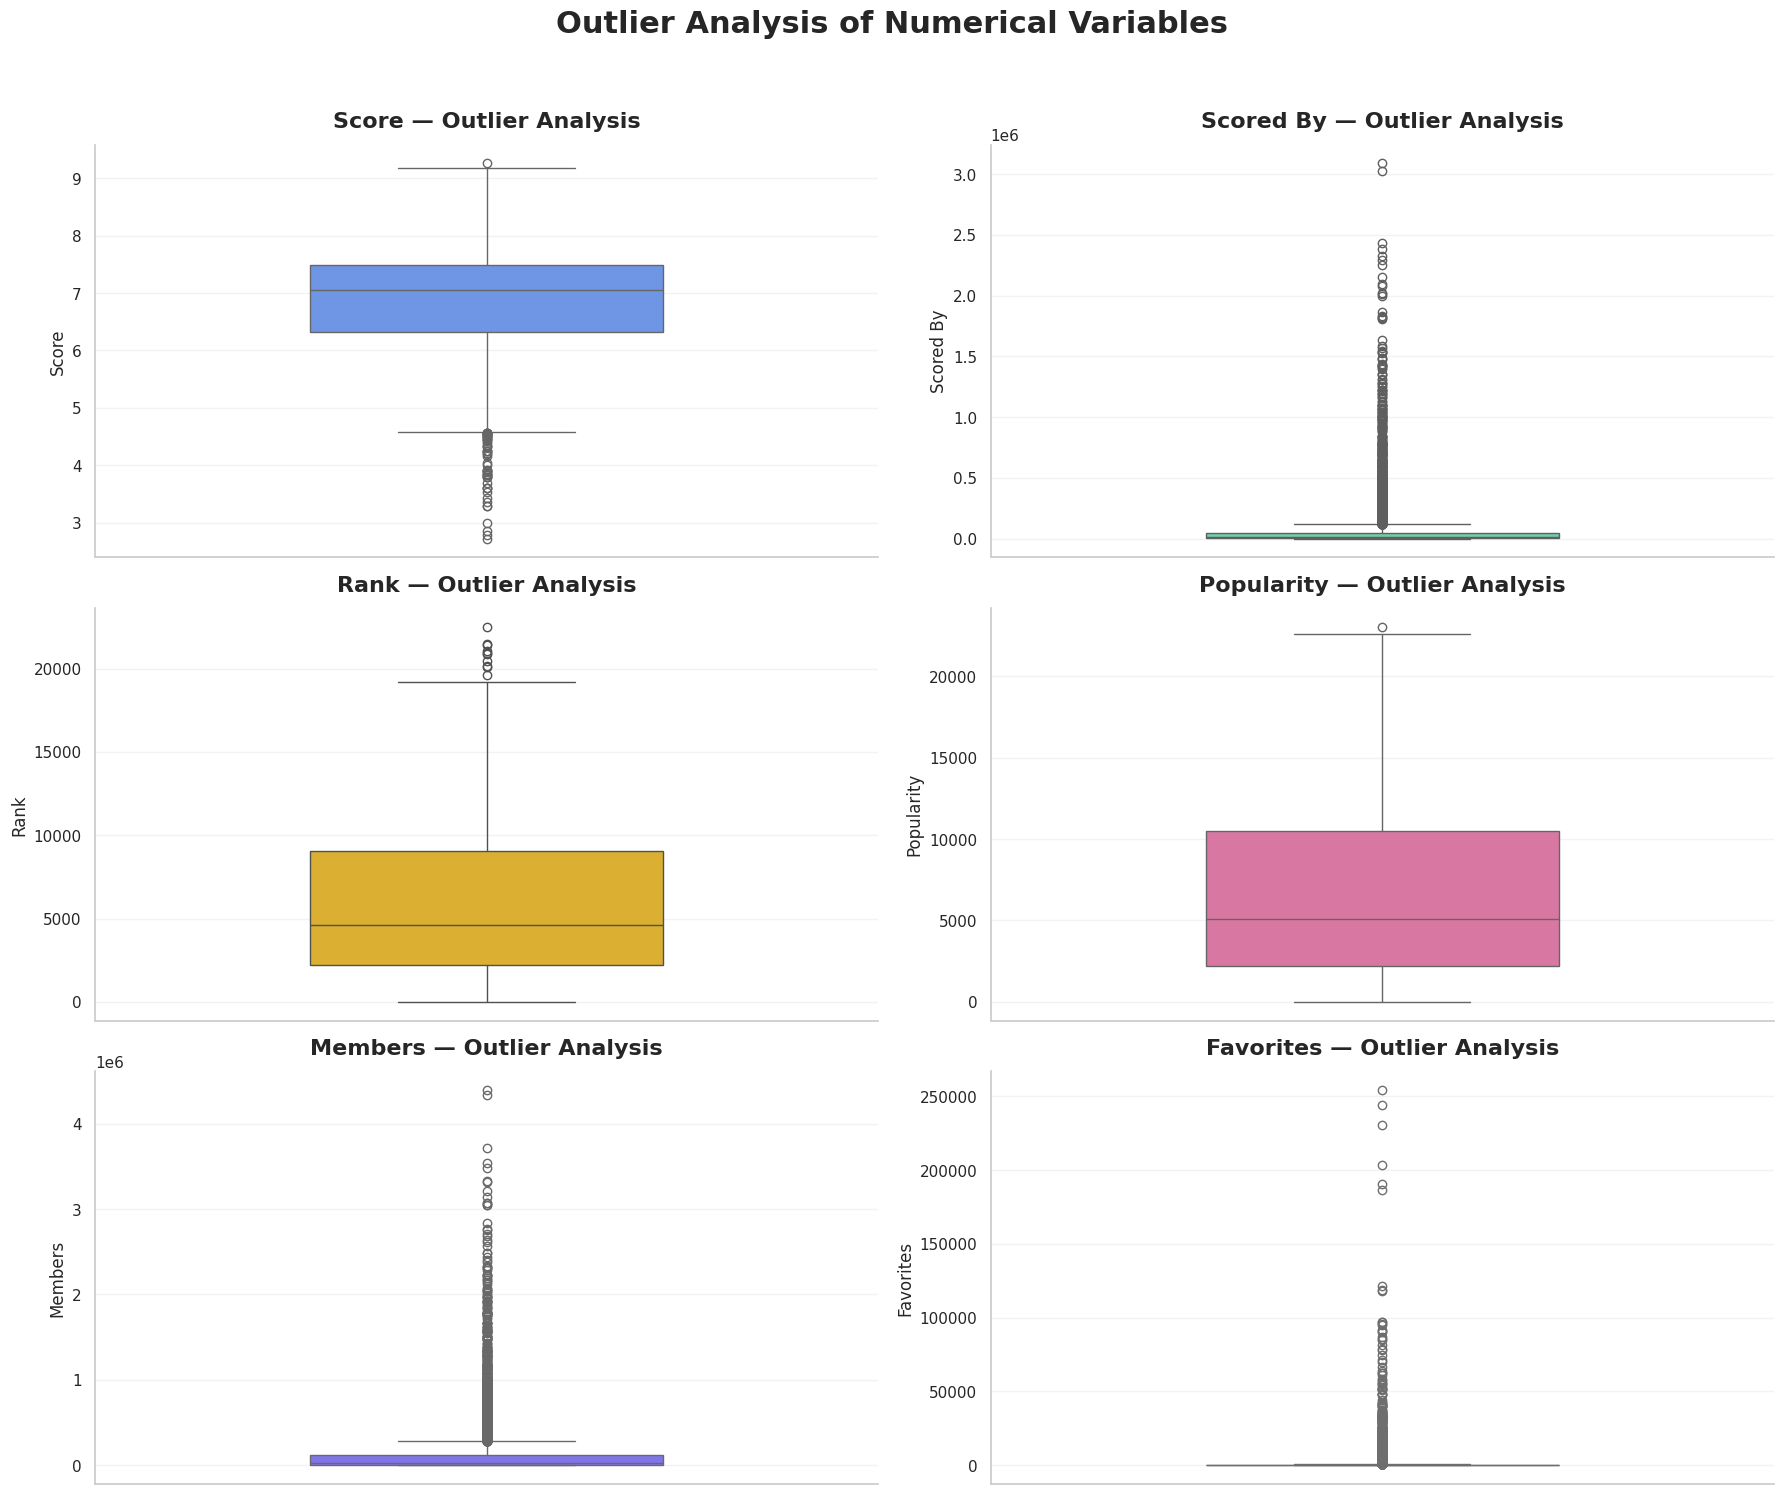

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

outlier_cols = [
    "score",
    "scored_by",
    "rank",
    "popularity",
    "members",
    "favorites"
]

sns.set_theme(style="whitegrid", context="notebook")

fig, axes = plt.subplots(
    3, 2,
    figsize=(18, 15)
)

axes = axes.flatten()

plot_colors = [
    "#5B8FF9",
    "#61DDAA",
    "#F6BD16",
    "#E868A0",
    "#7262FD",
    "#78D3F8"
]

for i, col in enumerate(outlier_cols):

    sns.boxplot(
        y=df_clean[col].dropna(),
        ax=axes[i],
        color=plot_colors[i],
        width=0.45
    )

    axes[i].set_title(
        f"{col.replace('_', ' ').title()} — Outlier Analysis",
        fontsize=16,
        fontweight="bold",
        pad=12
    )

    axes[i].set_ylabel(
        col.replace("_", " ").title(),
        fontsize=12
    )

    axes[i].set_xlabel("")

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    axes[i].grid(
        axis="y",
        alpha=0.25
    )

plt.suptitle(
    "Outlier Analysis of Numerical Variables",
    fontsize=22,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

- An anime with millions of members is expected to be an extreme value.
- An extremely popular anime having many favorites is also legitimate.
- scored_by can naturally be very large for famous anime.


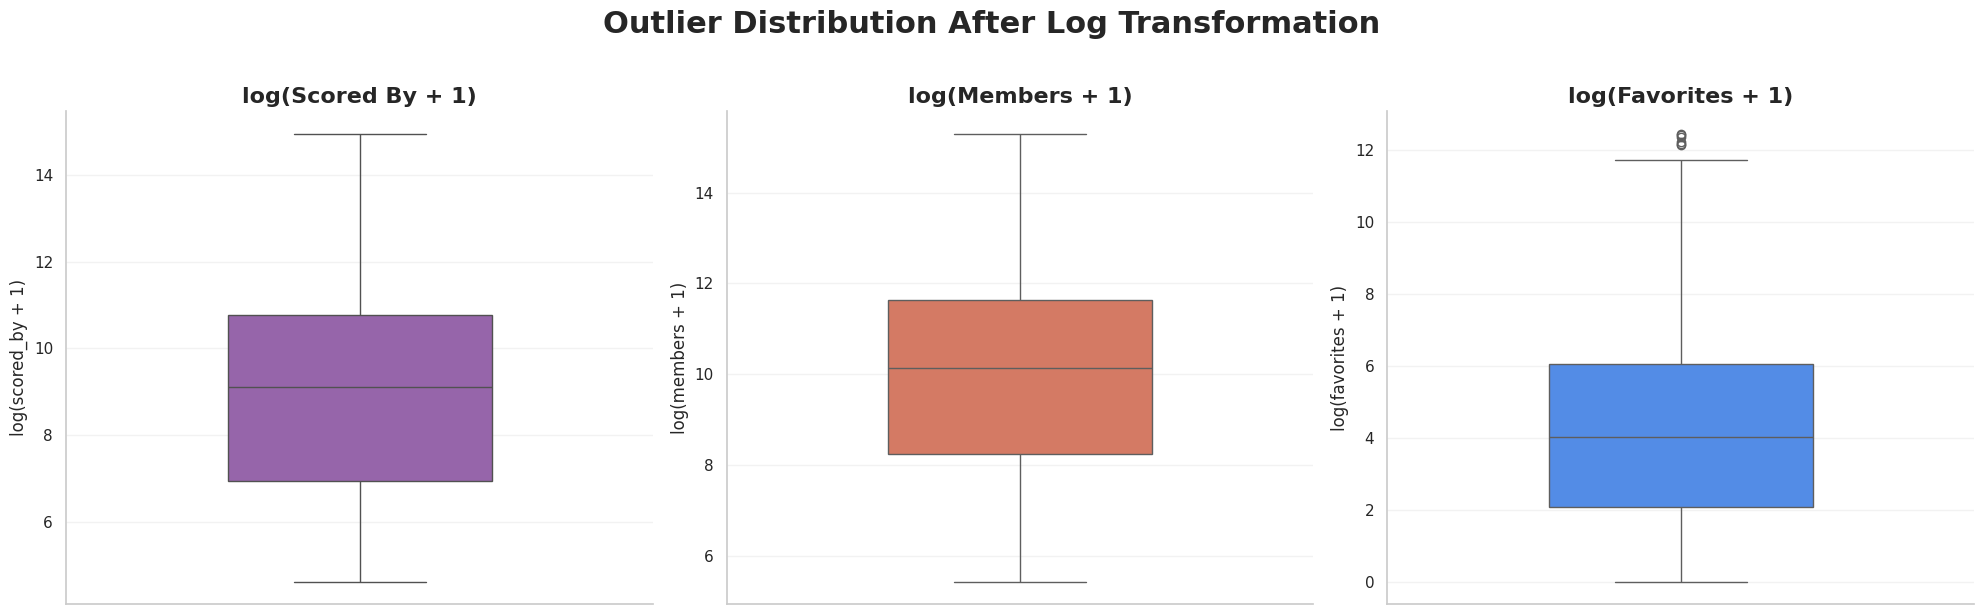

In [33]:
log_cols = [
    "scored_by",
    "members",
    "favorites"
]

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 6)
)

log_colors = [
    "#9B59B6",
    "#E76F51",
    "#3A86FF"
]

for i, col in enumerate(log_cols):

    log_data = np.log1p(
        df_clean[col].dropna()
    )

    sns.boxplot(
        y=log_data,
        ax=axes[i],
        color=log_colors[i],
        width=0.45
    )

    axes[i].set_title(
        f"log({col.replace('_', ' ').title()} + 1)",
        fontsize=16,
        fontweight="bold"
    )

    axes[i].set_ylabel(
        f"log({col} + 1)",
        fontsize=12
    )

    axes[i].set_xlabel("")

    axes[i].spines["top"].set_visible(False)
    axes[i].spines["right"].set_visible(False)

    axes[i].grid(
        axis="y",
        alpha=0.25
    )

plt.suptitle(
    "Outlier Distribution After Log Transformation",
    fontsize=22,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()
plt.show()

## Now let's check the producers, studios, themes, and demographichs, and genre's word similarity to maintain the consistency over the workflow

In [55]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher


LIST_COLS = [
    'producers',
    'themes',
    'genres',
    'studios',
    'demographics'
]


def clean_item(x):
    """Strip whitespace from a list item."""
    if not isinstance(x, str):
        return x
    
    return x.strip()


print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

for col in LIST_COLS:

    # Flatten the lists
    values = (
        df_clean[col]
        .explode()
    )

    # Remove actual NaN values
    values_nonnull = values.dropna()

    # --------------------------------------------------------
    # Basic statistics
    # --------------------------------------------------------

    unique_count = values_nonnull.nunique()

    empty_strings = (
        values_nonnull.astype(str).str.strip().eq('').sum()
    )

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    print(f"Unique values        : {unique_count}")
    print(f"Total non-null items : {len(values_nonnull)}")
    print(f"Empty strings        : {empty_strings}")

    # --------------------------------------------------------
    # Missing / empty lists
    # --------------------------------------------------------

    missing_rows = df_clean[col].apply(
        lambda x: not isinstance(x, list) or len(x) == 0
    ).sum()

    print(f"Missing/empty anime rows: {missing_rows}")

    # --------------------------------------------------------
    # Empty strings inside lists
    # --------------------------------------------------------

    empty_string_rows = df_clean[col].apply(
        lambda x: isinstance(x, list) and any(
            isinstance(item, str) and item.strip() == ''
            for item in x
        )
    ).sum()

    print(f"Rows containing empty strings: {empty_string_rows}")



print("\n\n")
print("=" * 80)
print("CAPITALIZATION VARIANTS")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
    )

    # Group values by lowercase version
    grouped = values.groupby(values.str.lower()).agg(
        lambda x: sorted(set(x))
    )

    # Keep only cases where multiple spellings exist
    variants = grouped[
        grouped.apply(len) > 1
    ]

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    if len(variants) == 0:
        print("No capitalization/spacing variants found.")
    else:
        print(f"Found {len(variants)} possible variant groups:\n")

        for normalized, variants_list in variants.items():
            print(f"{normalized}  -->  {variants_list}")


# ============================================================
# 3. WHITESPACE VARIANTS
# ============================================================

print("\n\n")
print("=" * 80)
print("WHITESPACE / SPACING CHECK")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
    )

    # Compare original with stripped version
    whitespace_values = values[
        values != values.str.strip()
    ].unique()

    print(f"\n{col.upper()}")
    print("-" * 80)

    print(f"Values with leading/trailing spaces: {len(whitespace_values)}")

    if len(whitespace_values) > 0:
        for value in whitespace_values[:30]:
            print(repr(value))


# ============================================================
# 4. POSSIBLE TYPO / SIMILAR-NAME CHECK
# ============================================================
#
# IMPORTANT:
# This does NOT automatically merge values.
# It only gives you suspicious pairs to manually verify.
#
# ============================================================

def similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


print("\n\n")
print("=" * 80)
print("POSSIBLE TYPO / SIMILAR NAME CHECK")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    # Only compare values that have reasonable length
    candidates = [
        v for v in values
        if len(v) >= 4
    ]

    similar_pairs = []

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):

            a = candidates[i]
            b = candidates[j]

            # Skip exact matches ignoring case
            if a.lower() == b.lower():
                continue

            ratio = similarity(a, b)

            # High similarity = possible typo/variant
            if ratio >= 0.90:
                similar_pairs.append(
                    (a, b, round(ratio, 3))
                )

    if similar_pairs:
        print(f"Possible similar/typo pairs: {len(similar_pairs)}")

        for a, b, ratio in sorted(
            similar_pairs,
            key=lambda x: x[2],
            reverse=True
        )[:50]:

            print(f"{ratio:.3f} | {a}  <-->  {b}")

    else:
        print("No highly similar pairs found.")


# ============================================================
# 5. UNIQUE VALUE FREQUENCY
# ============================================================

print("\n\n")
print("=" * 80)
print("UNIQUE VALUE FREQUENCY")
print("=" * 80)

frequency_tables = {}

for col in LIST_COLS:

    counts = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )

    frequency_tables[col] = counts

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    print(counts.head(20))




# ============================================================
# 8. CREATE A SUMMARY TABLE
# ============================================================

summary = []

for col in LIST_COLS:

    values = df_clean[col].explode()

    unique_count = values.dropna().nunique()

    missing_rows = df_clean[col].apply(
        lambda x: not isinstance(x, list) or len(x) == 0
    ).sum()

    summary.append({
        'Column': col,
        'Unique Values': unique_count,
        
    })

summary_df = pd.DataFrame(summary)

print("\n\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

display(summary_df)

DATA QUALITY REPORT

--------------------------------------------------------------------------------
PRODUCERS
--------------------------------------------------------------------------------
Unique values        : 1645
Total non-null items : 25624
Empty strings        : 0
Missing/empty anime rows: 573
Rows containing empty strings: 0

--------------------------------------------------------------------------------
THEMES
--------------------------------------------------------------------------------
Unique values        : 66
Total non-null items : 10685
Empty strings        : 0
Missing/empty anime rows: 2145
Rows containing empty strings: 0

--------------------------------------------------------------------------------
GENRES
--------------------------------------------------------------------------------
Unique values        : 22
Total non-null items : 17811
Empty strings        : 0
Missing/empty anime rows: 0
Rows containing empty strings: 0

------------------------------------

,Column,Unique Values
0,producers,1645
1,themes,66
2,genres,22
3,studios,794
4,demographics,6


In [57]:
# for white space correction

df_clean['producers'] = df_clean['producers'].apply(
    lambda x: [p.strip() for p in x] if isinstance(x, list) else x
)

# correct the variant and standardize

In [58]:
producer_groups = {
    'Shouwa Monogatari Production Committee': [
        'Showa Monogatari Production Committee',
        'Shouwa Monogatari Production Committee'
    ],

    'JR-East Marketing & Communications': [
        'JR East Marketing & Communications',
        'JR-East Marketing & Communications'
    ],

    'MediaWorks': [
        'Media Works',
        'MediaWorks'
    ],

    'The Pokémon Company': [
        'The Pokemon Company',
        'The Pokémon Company'
    ],

    'Primetime': [
        'Prime Time',
        'Primetime'
    ],

    'Plusone': [
        'Plus One',
        'Plusone'
    ],

    'Mages': [
        'MAGES.',
        'Mages.',
        'Mages'
    ],

    '8-Bit': [
        '8-Bit',
        '8-bit'
    ],

    'AMG Music': [
        'AMG MUSIC',
        'AMG Music'
    ],

    'ANIMA': [
        'ANIMA',
        'Anima'
    ],

    'AnyColor': [
        'ANYCOLOR',
        'AnyColor'
    ],

    'Aquaplus': [
        'AQUAPLUS',
        'Aquaplus'
    ],

    'Bilibili': [
        'Bilibili',
        'bilibili'
    ],

    'BioWare': [
        'BioWare',
        'Bioware'
    ],

    'Coly': [
        'Coly',
        'coly'
    ],

    'CREi': [
        'CREi',
        'Crei'
    ],

    'DeNA': [
        'DeNA',
        'DeNa'
    ],

    'Flying Dog': [
        'Flying Dog',
        'flying DOG'
    ],

    'Funimation Entertainment': [
        'FUNimation Entertainment',
        'Funimation Entertainment'
    ],

    'KADOKAWA': [
        'KADOKAWA',
        'Kadokawa'
    ],

    'OLM': [
        'OLM',
        'Olm'
    ],

    'SANZIGEN': [
        'SANZIGEN',
        'Sanzigen'
    ],

    'Science SARU': [
        'Science SARU',
        'Science Saru'
    ],

    'SMIRAL Animation': [
        'SMIRAL Animation',
        'Smiral Animation'
    ],

    'SUBARU': [
        'SUBARU',
        'Subaru'
    ],

    'Syn Sophia': [
        'Syn Sophia',
        'syn Sophia'
    ],

    'T-JOY': [
        'T-JOY',
        'T-Joy'
    ],

    'TOHO': [
        'TOHO',
        'Toho'
    ],

    'TOHO Animation': [
        'TOHO Animation',
        'TOHO animation'
    ],

    'Ufotable': [
        'Ufotable',
        'ufotable'
    ],

    'WAO World': [
        'WAO World',
        'Wao World'
    ],

    'WOWOW': [
        'WOWOW',
        'Wowow'
    ]
}

# Create mapping
producer_mapping = {
    variant: canonical
    for canonical, variants in producer_groups.items()
    for variant in variants
}

# Standardize producers in df_clean
df_clean['producers'] = df_clean['producers'].apply(
    lambda producers: [
        producer_mapping.get(p, p)
        for p in producers
    ] if isinstance(producers, list) else producers
)

# check again

In [59]:
import pandas as pd
import numpy as np
from difflib import SequenceMatcher


LIST_COLS = [
    'producers',
    'themes',
    'genres',
    'studios',
    'demographics'
]


def clean_item(x):
    """Strip whitespace from a list item."""
    if not isinstance(x, str):
        return x
    
    return x.strip()


print("=" * 80)
print("DATA QUALITY REPORT")
print("=" * 80)

for col in LIST_COLS:

    # Flatten the lists
    values = (
        df_clean[col]
        .explode()
    )

    # Remove actual NaN values
    values_nonnull = values.dropna()

    # --------------------------------------------------------
    # Basic statistics
    # --------------------------------------------------------

    unique_count = values_nonnull.nunique()

    empty_strings = (
        values_nonnull.astype(str).str.strip().eq('').sum()
    )

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    print(f"Unique values        : {unique_count}")
    print(f"Total non-null items : {len(values_nonnull)}")
    print(f"Empty strings        : {empty_strings}")

    # --------------------------------------------------------
    # Missing / empty lists
    # --------------------------------------------------------

    missing_rows = df_clean[col].apply(
        lambda x: not isinstance(x, list) or len(x) == 0
    ).sum()

    print(f"Missing/empty anime rows: {missing_rows}")

    # --------------------------------------------------------
    # Empty strings inside lists
    # --------------------------------------------------------

    empty_string_rows = df_clean[col].apply(
        lambda x: isinstance(x, list) and any(
            isinstance(item, str) and item.strip() == ''
            for item in x
        )
    ).sum()

    print(f"Rows containing empty strings: {empty_string_rows}")



print("\n\n")
print("=" * 80)
print("CAPITALIZATION VARIANTS")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
    )

    # Group values by lowercase version
    grouped = values.groupby(values.str.lower()).agg(
        lambda x: sorted(set(x))
    )

    # Keep only cases where multiple spellings exist
    variants = grouped[
        grouped.apply(len) > 1
    ]

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    if len(variants) == 0:
        print("No capitalization/spacing variants found.")
    else:
        print(f"Found {len(variants)} possible variant groups:\n")

        for normalized, variants_list in variants.items():
            print(f"{normalized}  -->  {variants_list}")


# ============================================================
# 3. WHITESPACE VARIANTS
# ============================================================

print("\n\n")
print("=" * 80)
print("WHITESPACE / SPACING CHECK")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
    )

    # Compare original with stripped version
    whitespace_values = values[
        values != values.str.strip()
    ].unique()

    print(f"\n{col.upper()}")
    print("-" * 80)

    print(f"Values with leading/trailing spaces: {len(whitespace_values)}")

    if len(whitespace_values) > 0:
        for value in whitespace_values[:30]:
            print(repr(value))


# ============================================================
# 4. POSSIBLE TYPO / SIMILAR-NAME CHECK
# ============================================================
#
# IMPORTANT:
# This does NOT automatically merge values.
# It only gives you suspicious pairs to manually verify.
#
# ============================================================

def similarity(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()


print("\n\n")
print("=" * 80)
print("POSSIBLE TYPO / SIMILAR NAME CHECK")
print("=" * 80)

for col in LIST_COLS:

    values = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    # Only compare values that have reasonable length
    candidates = [
        v for v in values
        if len(v) >= 4
    ]

    similar_pairs = []

    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):

            a = candidates[i]
            b = candidates[j]

            # Skip exact matches ignoring case
            if a.lower() == b.lower():
                continue

            ratio = similarity(a, b)

            # High similarity = possible typo/variant
            if ratio >= 0.90:
                similar_pairs.append(
                    (a, b, round(ratio, 3))
                )

    if similar_pairs:
        print(f"Possible similar/typo pairs: {len(similar_pairs)}")

        for a, b, ratio in sorted(
            similar_pairs,
            key=lambda x: x[2],
            reverse=True
        )[:50]:

            print(f"{ratio:.3f} | {a}  <-->  {b}")

    else:
        print("No highly similar pairs found.")


# ============================================================
# 5. UNIQUE VALUE FREQUENCY
# ============================================================

print("\n\n")
print("=" * 80)
print("UNIQUE VALUE FREQUENCY")
print("=" * 80)

frequency_tables = {}

for col in LIST_COLS:

    counts = (
        df_clean[col]
        .explode()
        .dropna()
        .astype(str)
        .str.strip()
        .value_counts()
    )

    frequency_tables[col] = counts

    print(f"\n{'-' * 80}")
    print(f"{col.upper()}")
    print(f"{'-' * 80}")

    print(counts.head(20))




# ============================================================
# 8. CREATE A SUMMARY TABLE
# ============================================================

summary = []

for col in LIST_COLS:

    values = df_clean[col].explode()

    unique_count = values.dropna().nunique()

    missing_rows = df_clean[col].apply(
        lambda x: not isinstance(x, list) or len(x) == 0
    ).sum()

    summary.append({
        'Column': col,
        'Unique Values': unique_count,
        
    })

summary_df = pd.DataFrame(summary)

print("\n\n")
print("=" * 80)
print("SUMMARY")
print("=" * 80)

display(summary_df)

DATA QUALITY REPORT

--------------------------------------------------------------------------------
PRODUCERS
--------------------------------------------------------------------------------
Unique values        : 1611
Total non-null items : 25624
Empty strings        : 0
Missing/empty anime rows: 573
Rows containing empty strings: 0

--------------------------------------------------------------------------------
THEMES
--------------------------------------------------------------------------------
Unique values        : 66
Total non-null items : 10685
Empty strings        : 0
Missing/empty anime rows: 2145
Rows containing empty strings: 0

--------------------------------------------------------------------------------
GENRES
--------------------------------------------------------------------------------
Unique values        : 22
Total non-null items : 17811
Empty strings        : 0
Missing/empty anime rows: 0
Rows containing empty strings: 0

------------------------------------

,Column,Unique Values
0,producers,1611
1,themes,66
2,genres,22
3,studios,794
4,demographics,6


In [60]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8227 entries, 0 to 9485
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   mal_id             8227 non-null   int64  
 1   url                8227 non-null   object 
 2   image_url          8227 non-null   object 
 3   trailer_embed_url  5050 non-null   object 
 4   title              8227 non-null   object 
 5   title_english      5979 non-null   object 
 6   title_japanese     8209 non-null   object 
 7   title_synonym      5026 non-null   object 
 8   type               8227 non-null   object 
 9   source             8227 non-null   object 
 10  status             8227 non-null   object 
 11  rating             8227 non-null   object 
 12  score              8227 non-null   float64
 13  scored_by          8227 non-null   float64
 14  rank               8227 non-null   float64
 15  popularity         8227 non-null   int64  
 16  members            8227 non-n

In [62]:
df_clean.describe()

,mal_id,score,scored_by,rank,popularity,members,favorites,year,episodes,duration_minutes
count,8227.000000,8227.000000,8.227000e+03,8227.000000,8227.000000,8.227000e+03,8227.000000,8227.000000,8227.000000,8227.000000
mean,31835.635469,6.900169,6.638997e+04,5796.549532,6745.070743,1.301038e+05,1544.935092,2014.992707,15.867388,29.480248
std,19530.010093,0.866912,1.851550e+05,4273.981085,5500.997203,3.068927e+05,8677.940663,9.164419,35.153300,28.115530
min,1.000000,2.720000,1.020000e+02,1.000000,1.000000,2.290000e+02,0.000000,1963.000000,1.000000,1.000000
25%,12682.000000,6.320000,1.040500e+03,2227.000000,2209.500000,3.812500e+03,7.000000,2012.000000,1.000000,16.000000
50%,35120.000000,7.050000,8.987000e+03,4593.000000,5066.000000,2.537700e+04,55.000000,2017.000000,12.000000,23.000000
75%,49284.500000,7.490000,4.730000e+04,9042.000000,10510.500000,1.143150e+05,419.000000,2021.000000,13.000000,25.000000
max,64398.000000,9.260000,3.088659e+06,22515.000000,23036.000000,4.393144e+06,254153.000000,2026.000000,1787.000000,168.000000


## and since the null value of the studios , producers , themes and demographics are reduced bc we drop the score and score_by so  i will impute them like ( Unknown) use this dataset so that it doesn't have that much effect when i mine the data 

## Balanced Success=0.40(Score)+0.25(Reach)+0.20(Engagement)+0.15(Popularity)


The fix — a single balanced_score that blends four signals:

Component	What it captures	Transform used
score	Critical/audience reception	Percentile rank among rated titles
members	Total reach (everyone who ever added it to any list)	Percentile rank of log1p(members)
favorites	Depth of fan enthusiasm (people who loved it enough to favorite it)	Percentile rank of log1p(favorites)
popularity	MAL's own popularity rank (1 = most popular, so we invert it)	Percentile rank of -popularity

In [77]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata


def clean_and_impute_anime_dataset(df: pd.DataFrame) -> pd.DataFrame:
    d = df_clean.copy()

    d = d[d['members'] >= 100].copy()

    categorical_cols = [
        'studios',
        'producers',
        'themes',
        'genres',
        'demographics'
    ]

    for col in categorical_cols:
        d[col] = d[col].fillna('Unknown')

    # Missing-value indicators
    # ------------------------------------------------------------
    # These are created BEFORE imputation so they correctly
    # indicate whether the original value was missing.
    d['studios_missing'] = d['studios'].eq('Unknown')
    d['producers_missing'] = d['producers'].eq('Unknown')
    d['themes_missing'] = d['themes'].eq('Unknown')
    d['genres_missing'] = d['genres'].eq('Unknown')
    d['demographics_missing'] = d['demographics'].eq('Unknown')

    
    # ------------------------------------------------------------
    #  Convert success variables to percentile ranks
    # ------------------------------------------------------------
    def pct_rank(series: pd.Series) -> pd.Series:
        """
        Convert values into fractional percentile ranks in (0, 1].
        Higher value = higher percentile.
        """
        return pd.Series(
            rankdata(series, method='average') / len(series),
            index=series.index
        )

    # Members and favorites are highly right-skewed.
    # log1p reduces the influence of extreme mega-hits.
    d['members_pct'] = pct_rank(
        np.log1p(d['members'])
    )

    d['favorites_pct'] = pct_rank(
        np.log1p(d['favorites'])
    )

    # Score: higher score = better
    d['score_pct'] = pct_rank(
        d['score']
    )

    # Popularity: lower numerical rank = more popular.
    # Negating it makes higher popularity rank = higher percentile.
    d['popularity_pct'] = pct_rank(
        -d['popularity']
    )

    # ------------------------------------------------------------
    # Balanced Success Metric
    # ------------------------------------------------------------
    # Quality / Critical acclaim : 40%
    # Audience reach             : 25%
    # User engagement            : 20%
    # Platform popularity        : 15%
    #
    # All four components are available for the retained dataset,
    # so fixed weights are used.

    weights = {'score_pct': 0.40, 'members_pct': 0.25, 'favorites_pct': 0.20, 'popularity_pct': 0.15}
    d['balanced_score'] = sum(d[c] * w for c, w in weights.items())

    print(d['balanced_score'].describe())


    return d


df = clean_and_impute_anime_dataset(df_clean)


print("--- Final Dataset Stats ---")
print(f"Total entries retained: {len(df)}")

print("\nMissing Values:")
print(f"Missing balanced_score: {df['balanced_score'].isna().sum()}")
print(f"Missing studios: {df['studios'].isna().sum()}")
print(f"Missing producers: {df['producers'].isna().sum()}")
print(f"Missing themes: {df['themes'].isna().sum()}")
print(f"Missing genres: {df['genres'].isna().sum()}")
print(f"Missing demographics: {df['demographics'].isna().sum()}")

print("\nBalanced Score Distribution:")
print(df['balanced_score'].describe())

print("\nBalanced Score Range:")
print(
    f"Minimum: {df['balanced_score'].min():.2f}\n"
    f"Maximum: {df['balanced_score'].max():.2f}"
)


weights = {
    'Score': 0.40,
    'Members': 0.25,
    'Favorites': 0.20,
    'Popularity': 0.15
}

print("\nWeight Check:")
print(f"Total weight: {sum(weights.values()):.2f}")

for name, weight in weights.items():
    print(f"{name}: {weight:.2f}")

count    8227.000000
mean        0.500061
std         0.260341
min         0.015704
25%         0.287773
50%         0.507904
75%         0.707418
max         0.999781
Name: balanced_score, dtype: float64
--- Final Dataset Stats ---
Total entries retained: 8227

Missing Values:
Missing balanced_score: 0
Missing studios: 0
Missing producers: 0
Missing themes: 0
Missing genres: 0
Missing demographics: 0

Balanced Score Distribution:
count    8227.000000
mean        0.500061
std         0.260341
min         0.015704
25%         0.287773
50%         0.507904
75%         0.707418
max         0.999781
Name: balanced_score, dtype: float64

Balanced Score Range:
Minimum: 0.02
Maximum: 1.00

Weight Check:
Total weight: 1.00
Score: 0.40
Members: 0.25
Favorites: 0.20
Popularity: 0.15


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8227 entries, 0 to 9485
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mal_id                8227 non-null   int64  
 1   url                   8227 non-null   object 
 2   image_url             8227 non-null   object 
 3   trailer_embed_url     5050 non-null   object 
 4   title                 8227 non-null   object 
 5   title_english         5979 non-null   object 
 6   title_japanese        8209 non-null   object 
 7   title_synonym         5026 non-null   object 
 8   type                  8227 non-null   object 
 9   source                8227 non-null   object 
 10  status                8227 non-null   object 
 11  rating                8227 non-null   object 
 12  score                 8227 non-null   float64
 13  scored_by             8227 non-null   float64
 14  rank                  8227 non-null   float64
 15  popularity            8227

# Now separate into two clean dataset , 1 to UI and 1 for working

In [79]:
# ================================================================
#  Create UI dataset
# ================================================================

ui_exclude_cols = [
    'studios_missing',
    'producers_missing',
    'themes_missing',
    'genres_missing',
    'demographics_missing',
    'members_pct',
    'favorites_pct',
    'score_pct',
    'popularity_pct',
    'balanced_score'
]

df_clean_ui = df.drop(columns=ui_exclude_cols).copy()


# ================================================================
#  Create Working Dataset
# ================================================================

working_exclude_cols = [
    'url',
    'image_url',
    'trailer_embed_url',
    'aired_from'
]

working_dataset = df.drop(columns=working_exclude_cols).copy()


# ================================================================
#  Validation
# ================================================================

print("==================================================")
print("UI DATASET")
print("==================================================")
print(f"Shape: {df_clean_ui.shape}")
print(f"Rows: {len(df_clean_ui)}")
print(f"Columns: {len(df_clean_ui.columns)}")

print("\nExcluded from UI dataset:")
print(ui_exclude_cols)


print("\n==================================================")
print("WORKING DATASET")
print("==================================================")
print(f"Shape: {working_dataset.shape}")
print(f"Rows: {len(working_dataset)}")
print(f"Columns: {len(working_dataset.columns)}")

print("\nExcluded from working dataset:")
print(working_exclude_cols)


# ================================================================
#  Verify excluded columns are actually gone
# ================================================================

print("\n==================================================")
print("COLUMN CHECK")
print("==================================================")

ui_remaining = [
    col for col in ui_exclude_cols
    if col in df_clean_ui.columns
]

working_remaining = [
    col for col in working_exclude_cols
    if col in working_dataset.columns
]

print("UI excluded columns still present:", ui_remaining)
print("Working excluded columns still present:", working_remaining)


# ================================================================
#  Display column names
# ================================================================

print("\nUI Dataset Columns:")
print(df_clean_ui.columns.tolist())

print("\nWorking Dataset Columns:")
print(working_dataset.columns.tolist())

UI DATASET
Shape: (8227, 30)
Rows: 8227
Columns: 30

Excluded from UI dataset:
['studios_missing', 'producers_missing', 'themes_missing', 'genres_missing', 'demographics_missing', 'members_pct', 'favorites_pct', 'score_pct', 'popularity_pct', 'balanced_score']

WORKING DATASET
Shape: (8227, 36)
Rows: 8227
Columns: 36

Excluded from working dataset:
['url', 'image_url', 'trailer_embed_url', 'aired_from']

COLUMN CHECK
UI excluded columns still present: []
Working excluded columns still present: []

UI Dataset Columns:
['mal_id', 'url', 'image_url', 'trailer_embed_url', 'title', 'title_english', 'title_japanese', 'title_synonym', 'type', 'source', 'status', 'rating', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'season', 'year', 'producers', 'episodes', 'aired_from', 'broadcast_day', 'genres', 'themes', 'studios', 'demographics', 'duration_minutes', 'synopsis_clean']

Working Dataset Columns:
['mal_id', 'title', 'title_english', 'title_japanese', 'title_synonym', '

In [80]:
df_clean_ui.to_csv('/kaggle/working/df_clean_ui_10_9_2026_latest.csv', index=False, encoding='utf-8-sig')

working_dataset.to_csv('/kaggle/working/working_dataset_10_9_2026_latest.csv', index=False, encoding='utf-8-sig')

print("Saved successfully!")
print("/kaggle/working/df_clean_ui.csv")
print("/kaggle/working/working_dataset.csv")

Saved successfully!
/kaggle/working/df_clean_ui.csv
/kaggle/working/working_dataset.csv


In [81]:
d =df.copy()

In [82]:
d['score_rank'] = d['score'].rank(ascending=False)
d['balanced_rank'] = d['balanced_score'].rank(ascending=False)
d['rank_shift'] = d['balanced_rank'] - d['score_rank']   # positive = balanced_score demotes it

scored = d[d['score'].notna()].copy()

print('High raw score, but DROPS once reach is factored in (small/late-rated fanbase):')
print(scored.sort_values('rank_shift', ascending=False)[['title','score','members','popularity','favorites','balanced_score']].head(6).to_string(index=False))

print('\nLower raw score, but RISES once reach is factored in (huge audience despite mixed reviews):')
print(scored.sort_values('rank_shift', ascending=True)[['title','score','members','popularity','favorites','balanced_score']].head(6).to_string(index=False))

print('\nCorrelation with raw score (on the scored subset):', round(scored['balanced_score'].corr(scored['score']), 3))


High raw score, but DROPS once reach is factored in (small/late-rated fanbase):
                                      title  score  members  popularity  favorites  balanced_score
    Zhe Tian Movie: Bei Guan Zhan Wang Teng   7.69      760       16529          0        0.369898
                    You Shou Yan 4th Season   7.87     1085       15098          4        0.439556
                    You Shou Yan 3rd Season   7.93     1131       14925          8        0.460830
               Yong Sheng: Tai Yuan Xian Fu   7.62     1004       15370          1        0.385724
Tunshi Xingkong Movie: Juezhan Yuanshi Xing   7.65     1005       15414          2        0.398159
                Wu Dong Qian Kun 6th Season   7.92     1580       13539          5        0.467048

Lower raw score, but RISES once reach is factored in (huge audience despite mixed reviews):
                           title  score  members  popularity  favorites  balanced_score
Yakusoku no Neverland 2nd Season   5.24  10056

**Reading the two tables above:** titles like *One Punch Man 3*, *Boruto: Naruto Next Generations*, and *Yakusoku no Neverland 2nd Season* — all famous for reaching a massive audience despite a lukewarm critical score — rise sharply under `balanced_score`. Meanwhile several niche sequels with very few raters, high scores from a small die-hard base, but limited reach, drop. The 0.87–0.88 correlation with raw score confirms `balanced_score` still broadly agrees with critical reception (it isn't throwing the baby out with the bathwater) while genuinely correcting the specific "high score, low reach" and "low score, huge reach" bias your instructor pointed out. **From this point on, `balanced_score` is the outcome metric used everywhere in this notebook** — association rule "success" buckets, studio/producer performance rankings, and the predictive-modeling targets in Part 7.

## Correlations

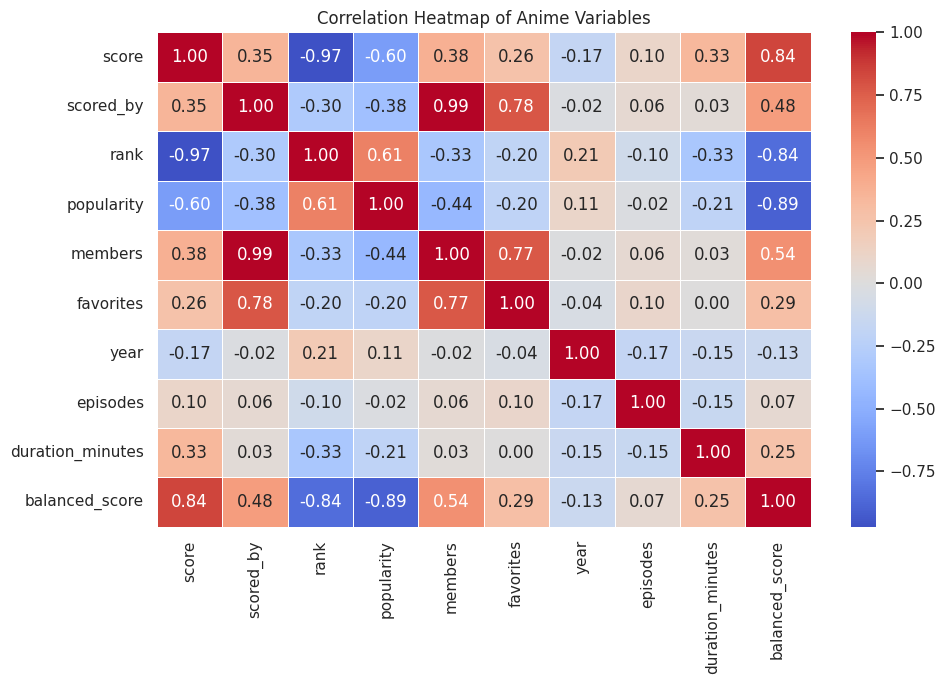

In [84]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
corr_cols = [
    'score',
    'scored_by',
    'rank',
    'popularity',
    'members',
    'favorites',
    'year',
    'episodes',
    'duration_minutes',
    'balanced_score'
]

corr_matrix = df[corr_cols].corr(method='pearson')

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of Anime Variables')
plt.tight_layout()
plt.show()

## RQ1 (Market Evolution & Format Dynamics): How have content delivery formats (TV, ONA, Movie, OVA) and source adaptations evolved over time, and which other structural formats achieve superior market penetration?

=== Source Success Benchmarking (2010–2025) ===
      source  total_titles  valid_scored_count  median_balanced_score  mean_balanced_score  median_members
 Light novel           656                 656                 0.6843               0.6581        190387.0
       Manga          1803                1803                 0.6388               0.6086         69659.0
Visual novel           151                 151                 0.5290               0.5245         49466.0
4-koma manga           159                 159                 0.5224               0.5173         43428.0
   Web manga           387                 387                 0.5130               0.5052         37610.0
 Mixed media           103                 103                 0.4365               0.4514         17782.0
       Novel           231                 231                 0.4163               0.4596         14106.0
   Web novel           276                 276                 0.3989               0.4096      

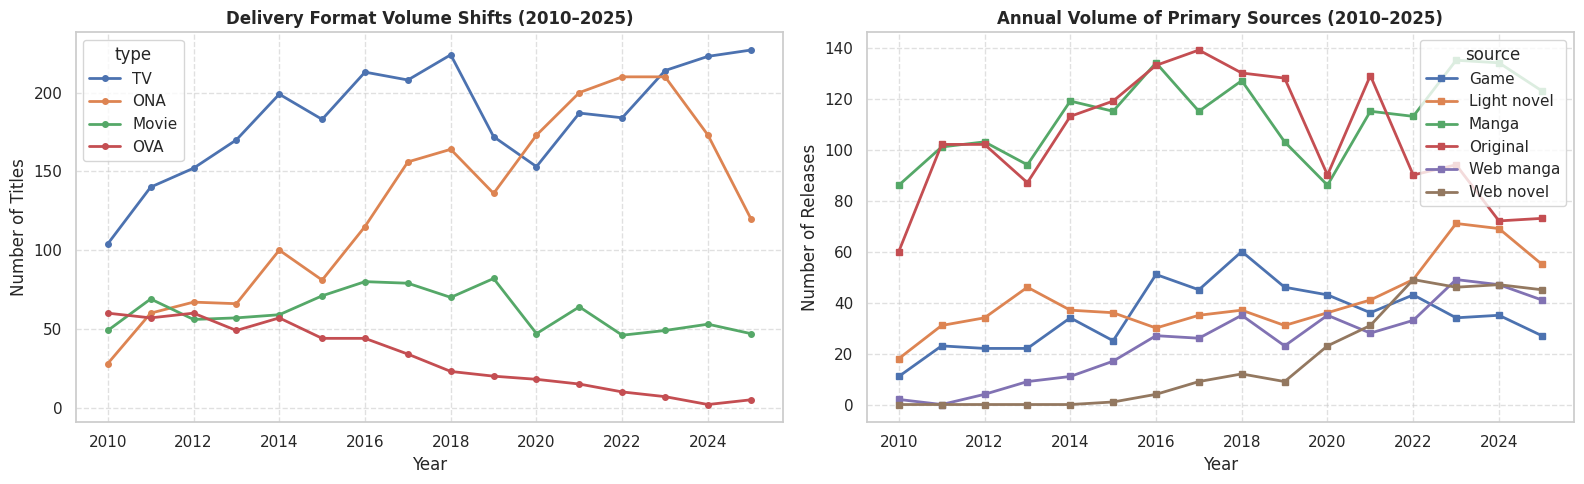

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------------------
# 0. Data Preparation (Strict 2010–2025 Window)
# -------------------------------------------------------------
d = df.copy()

# Ensure numeric types
d['year'] = pd.to_numeric(d['year'], errors='coerce')
d['score'] = pd.to_numeric(d['score'], errors='coerce')
d['members'] = pd.to_numeric(d['members'], errors='coerce')
d['popularity'] = pd.to_numeric(d['popularity'], errors='coerce')
d['balanced_score'] = pd.to_numeric(d['balanced_score'], errors='coerce')

# Filter exactly 2010–2025
# Exclude titles that are not yet aired or currently airing
d = d[
    d['year'].between(2010, 2025) &
    ~d['status'].isin(['Not yet aired', 'Currently Airing'])
].copy()

d['year'] = d['year'].astype(int)


# -------------------------------------------------------------
# 1. Source Success Analysis Using Balanced Score
# -------------------------------------------------------------

source_eval = d.groupby('source').agg(
    total_titles=('title', 'count'),

    # Number of valid titles with balanced score
    valid_scored_count=('balanced_score', 'count'),

    # Balanced success
    median_balanced_score=('balanced_score', 'median'),
    mean_balanced_score=('balanced_score', 'mean'),

    # Audience reach
    median_members=('members', 'median')
).reset_index()


# Round numerical results
source_eval['median_balanced_score'] = (
    source_eval['median_balanced_score'].round(4)
)

source_eval['mean_balanced_score'] = (
    source_eval['mean_balanced_score'].round(4)
)

source_eval = source_eval.sort_values(
    by='median_balanced_score',
    ascending=False
)

print("=== Source Success Benchmarking (2010–2025) ===")
print(source_eval.to_string(index=False))


# -------------------------------------------------------------
# 2. Visualization 1: Format Shifts & Source Trajectories
# -------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))


# -------------------------------------------------------------
# Subplot 1: Format Evolution
# -------------------------------------------------------------

format_counts = pd.crosstab(
    d['year'],
    d['type']
)

top_formats = ['TV', 'ONA', 'Movie', 'OVA']

existing_formats = [
    f for f in top_formats
    if f in format_counts.columns
]

format_counts[existing_formats].plot(
    kind='line',
    marker='o',
    markersize=4,
    ax=ax1,
    linewidth=2
)

ax1.set_title(
    'Delivery Format Volume Shifts (2010–2025)',
    fontsize=12,
    fontweight='bold'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('Number of Titles')
ax1.grid(True, linestyle='--', alpha=0.6)


# -------------------------------------------------------------
# Subplot 2: Annual Trajectory of Top Sources
# -------------------------------------------------------------

top_sources = [
    'Original',
    'Manga',
    'Light novel',
    'Game',
    'Web manga',
    'Web novel'
]

valid_top_sources = [
    s for s in top_sources
    if s in d['source'].values
]

source_yearly = (
    d[d['source'].isin(valid_top_sources)]
    .groupby(['year', 'source'])
    .size()
    .unstack(fill_value=0)
)

source_yearly.plot(
    kind='line',
    marker='s',
    markersize=4,
    ax=ax2,
    linewidth=2
)

ax2.set_title(
    'Annual Volume of Primary Sources (2010–2025)',
    fontsize=12,
    fontweight='bold'
)

ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Releases')
ax2.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

In [79]:
## Genre Trend

In [86]:
genre_trend = df[
    (df['year'] >= 2010) &
    (df['year'] <= 2025)
].copy()

genre_trend = genre_trend.explode('genres')

genre_counts = (
    genre_trend
    .groupby(['year', 'genres'])
    .size()
    .reset_index(name='count')
)

print(genre_counts.head())
top_genres = (
    genre_trend['genres']
    .value_counts()
    .head(10)
    .index
)

print(top_genres)

plot_data = genre_counts[
    genre_counts['genres'].isin(top_genres)
].copy()


     year       genres  count
0  2010.0       Action     66
1  2010.0    Adventure     38
2  2010.0  Avant Garde      3
3  2010.0    Boys Love      3
4  2010.0       Comedy    104
Index(['Comedy', 'Action', 'Fantasy', 'Adventure', 'Sci-Fi', 'Drama',
       'Romance', 'Supernatural', 'Mystery', 'Slice of Life'],
      dtype='object', name='genres')


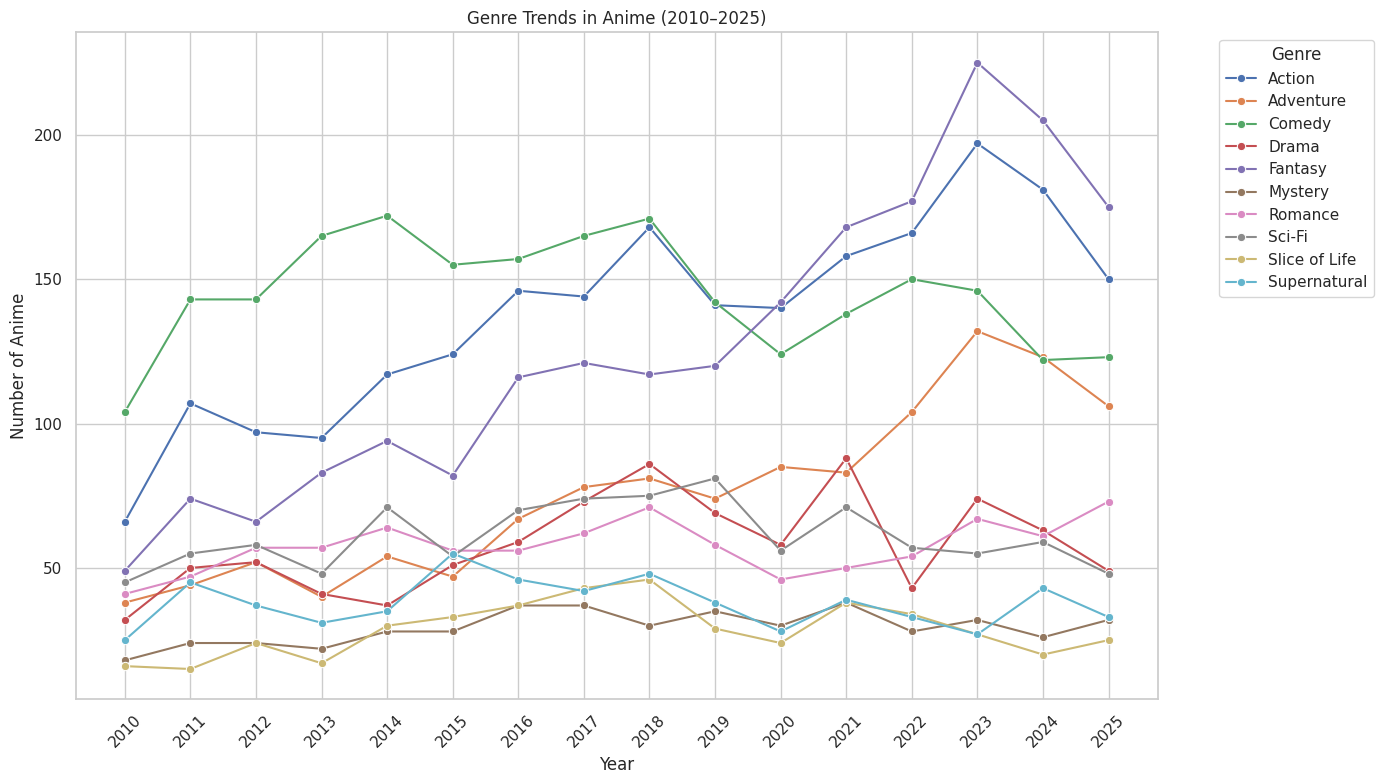

In [87]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=plot_data,
    x='year',
    y='count',
    hue='genres',
    marker='o'
)

plt.title('Genre Trends in Anime (2010–2025)')
plt.xlabel('Year')
plt.ylabel('Number of Anime')
plt.xticks(range(2010, 2026), rotation=45)
plt.legend(
    title='Genre',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

## source performance

We compare anime sources based on their overall success, measured by the median and mean Balanced Success Score, together with audience reach and popularity


- Quality → median_score
- Reach → median_members
- Engagement → median_favorites
- Popularity → median_popularity
- Overall success → median_balanced_score

In [90]:
source_performance = (
    df
    .groupby('source')
    .agg(
        anime_count=('title', 'count'),

        median_balanced_score=('balanced_score', 'median'),
        mean_balanced_score=('balanced_score', 'mean'),

        median_score=('score', 'median'),
        median_members=('members', 'median'),
        median_favorites=('favorites', 'median'),
        median_popularity=('popularity', 'median')
    )
    .sort_values(
        'median_balanced_score',
        ascending=False
    )
)

print(source_performance.round(4))

              anime_count  median_balanced_score  mean_balanced_score  \
source                                                                  
Light novel           815                 0.6755               0.6572   
Manga                2614                 0.6402               0.6198   
Visual novel          185                 0.5619               0.5585   
4-koma manga          180                 0.5265               0.5232   
Web manga             426                 0.4900               0.5016   
Novel                 316                 0.4892               0.4975   
Mixed media           107                 0.4365               0.4501   
Book                   45                 0.4199               0.4246   
Web novel             310                 0.3989               0.4137   
Original             2033                 0.3662               0.3946   
Game                  615                 0.3574               0.3705   
Card game              50                 0.3420   

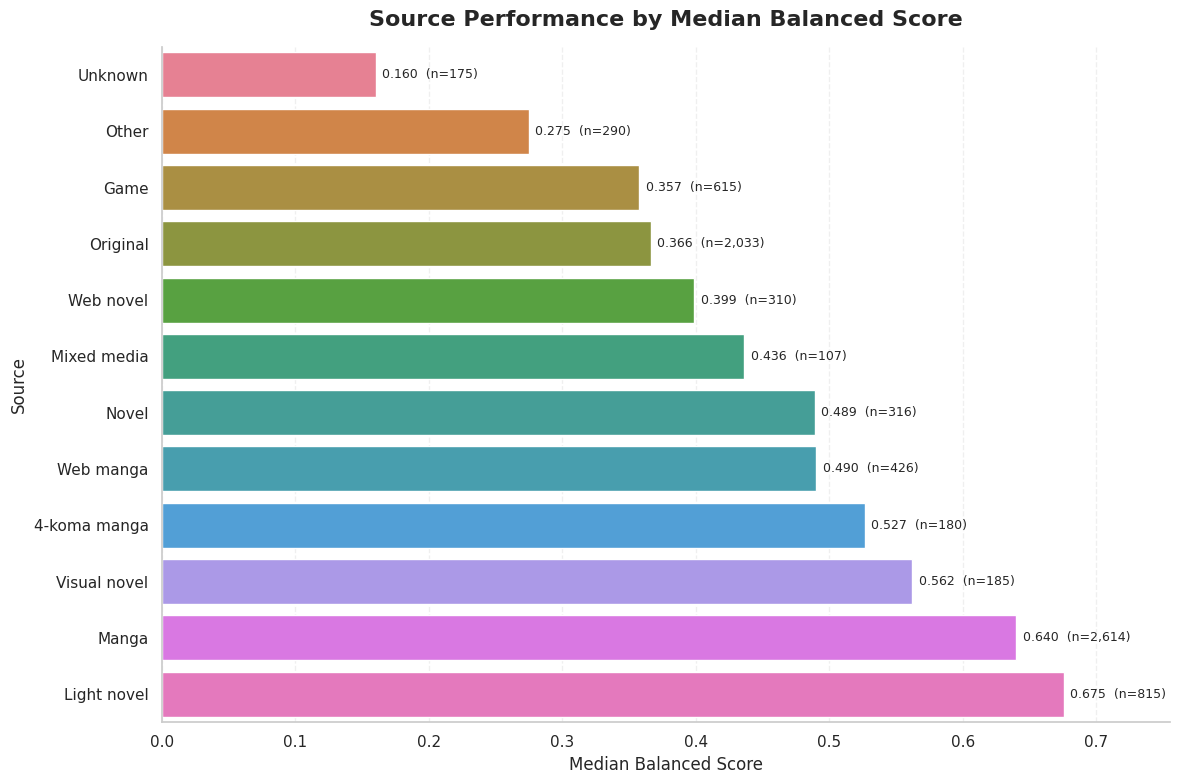

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

MIN_ANIME = 100

plot_data = (
    source_performance[
        source_performance['anime_count'] >= MIN_ANIME
    ]
    .sort_values('median_balanced_score', ascending=True)
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=plot_data,
    x='median_balanced_score',
    y=plot_data.index,
    hue=plot_data.index,
    legend=False
)

# Add balanced score and sample size
for i, (balanced_score, count) in enumerate(
    zip(
        plot_data['median_balanced_score'],
        plot_data['anime_count']
    )
):
    ax.text(
        balanced_score + 0.005,
        i,
        f'{balanced_score:.3f}  (n={count:,})',
        va='center',
        fontsize=9
    )

plt.title(
    'Source Performance by Median Balanced Score',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Median Balanced Score',
    fontsize=12
)

plt.ylabel(
    'Source',
    fontsize=12
)

plt.xlim(
    0,
    plot_data['median_balanced_score'].max() + 0.08
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

sns.despine(
    left=False,
    bottom=False
)

plt.tight_layout()
plt.show()

## Which anime production studios achieve the highest overall industry success by balancing consistent critical acclaim (production quality) with broad audience engagement (market reach)?

In [96]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


d = df.copy()
studio_perf = (
    d.explode("studios")
    .dropna(subset=['balanced_score'])
    .groupby('studios')
    .agg(
        anime_count=('title', 'nunique'),
        median_balanced_score=('balanced_score', 'median'),
        mean_balanced_score=('balanced_score', 'mean'),
        median_members=('members', 'median'),
        median_popularity=('popularity', 'median')
    )
    .reset_index()
)

qualified_studios = studio_perf[
   
    (studio_perf['anime_count'] >= 15)
].copy()

top_25_studios = (
    qualified_studios
    .sort_values('median_balanced_score', ascending=False)
    .head(25)
    .reset_index(drop=True)
)

print(
    top_25_studios[
        [
            'studios',
            'anime_count',
            'median_balanced_score',
            'mean_balanced_score',
            'median_members'
        ]
    ]
)

             studios  anime_count  median_balanced_score  mean_balanced_score  \
0      Studio Ghibli           23               0.912562             0.828725   
1        CloverWorks           52               0.840586             0.748252   
2          White Fox           35               0.837973             0.772680   
3           ufotable           41               0.823617             0.732697   
4    Kyoto Animation           69               0.819369             0.791762   
5              MAPPA           75               0.787839             0.730203   
6   David Production           41               0.760848             0.741659   
7            Trigger           28               0.748238             0.674511   
8              Bones          114               0.747925             0.723579   
9             Lerche           55               0.741057             0.711875   
10      A-1 Pictures          169               0.736952             0.702624   
11        Wit Studio        

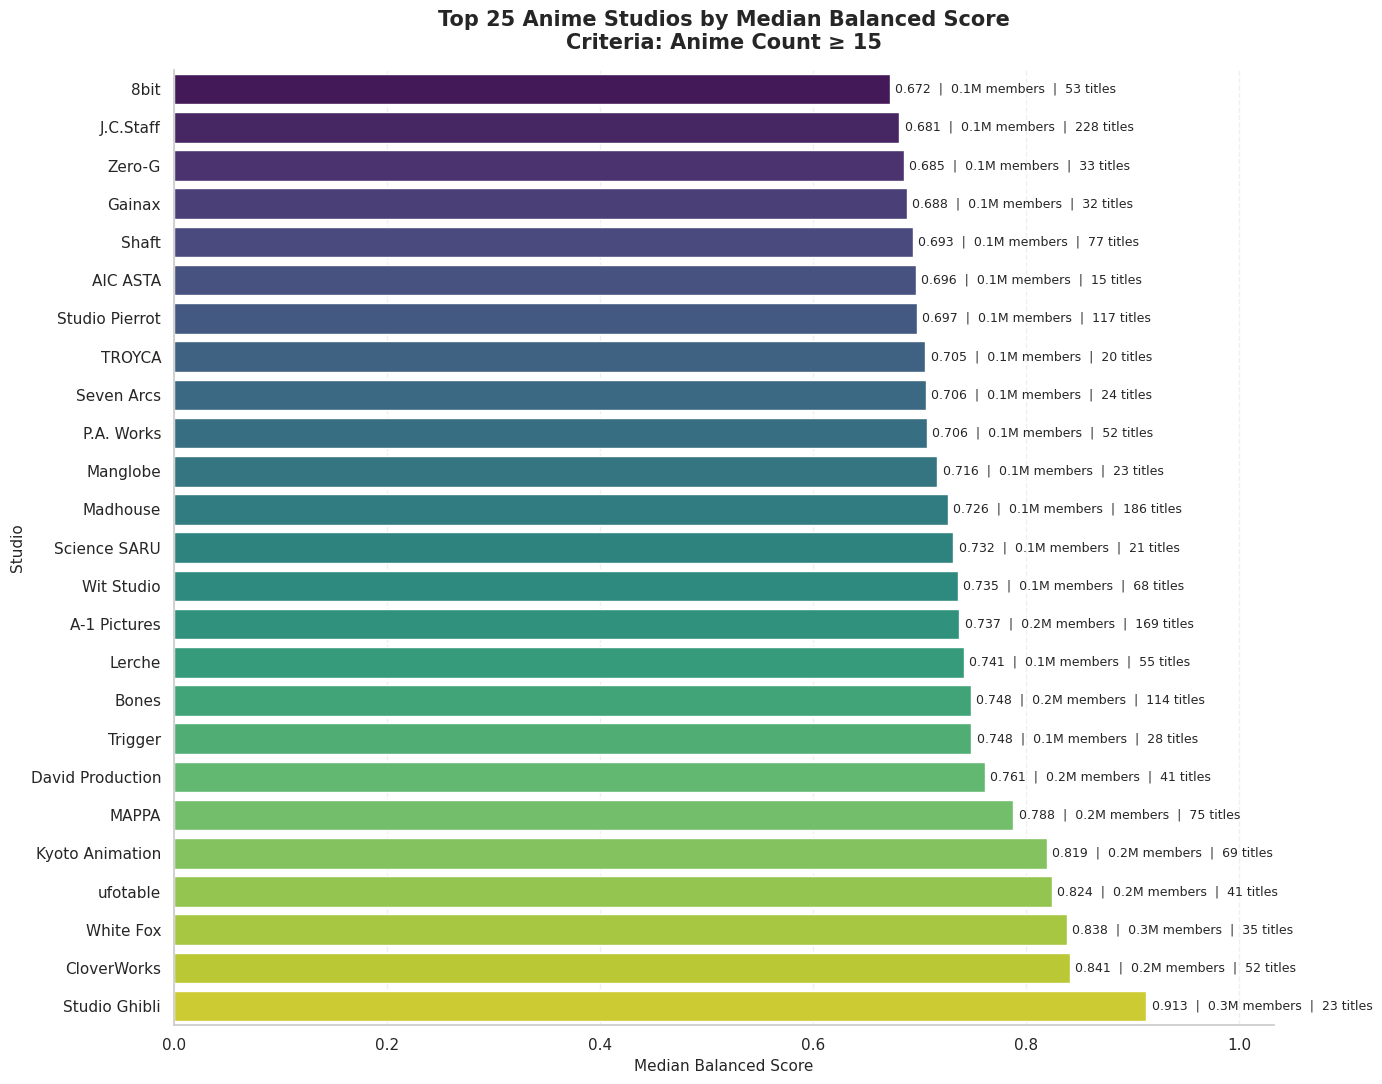

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort for horizontal bar chart
plot_df = (
    top_25_studios
    .sort_values('median_balanced_score', ascending=True)
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 11))

ax = sns.barplot(
    data=plot_df,
    x='median_balanced_score',
    y='studios',
    hue='studios',
    palette='viridis',
    legend=False
)

# Add annotations
for i, row in plot_df.iterrows():

    score = row['median_balanced_score']
    members = row['median_members']
    count = int(row['anime_count'])

    label = (
        f"{score:.3f}  |  "
        f"{members/1e6:.1f}M members  |  "
        f"{count} titles"
    )

    ax.text(
        score + 0.005,
        i,
        label,
        va='center',
        fontsize=9
    )

plt.xlim(
    0,
    plot_df['median_balanced_score'].max() + 0.12
)

plt.title(
    'Top 25 Anime Studios by Median Balanced Score\n'
    'Criteria: Anime Count ≥ 15',
    fontsize=15,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Median Balanced Score',
    fontsize=11
)

plt.ylabel(
    'Studio',
    fontsize=11
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

sns.despine()

plt.tight_layout()
plt.show()

Does release season influence audience reach or score?

In [98]:
seasonal = (
    d.groupby('season')
    .agg(
        anime_count=('title', 'count'),
        median_balanced_score=('balanced_score', 'median'),
        mean_balanced_score=('balanced_score', 'mean'),
        median_members=('members', 'median'),
        median_popularity=('popularity', 'median')
    )
    .sort_values('median_balanced_score', ascending=False)
)

print(seasonal)

        anime_count  median_balanced_score  mean_balanced_score  \
season                                                            
spring         2129               0.522487             0.515781   
fall           2206               0.513638             0.509707   
summer         1926               0.508788             0.498955   
winter         1966               0.481681             0.473297   

        median_members  median_popularity  
season                                     
spring         29193.0             4770.0  
fall           26304.5             4978.0  
summer         26787.0             4940.5  
winter         19260.0             5662.5  


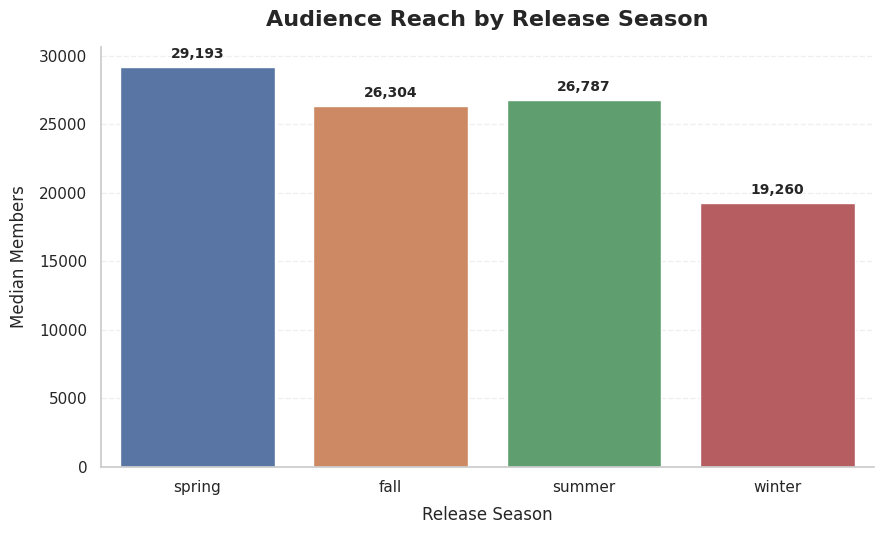

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = seasonal.reset_index()

plt.figure(figsize=(9, 5.5))

ax = sns.barplot(
    data=plot_data,
    x='season',
    y='median_members',
    hue='season',
    legend=False
)

# Add values above each bar
for i, value in enumerate(plot_data['median_members']):
    ax.text(
        i,
        value + plot_data['median_members'].max() * 0.015,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    'Audience Reach by Release Season',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Release Season',
    fontsize=12,
    labelpad=8
)

plt.ylabel(
    'Median Members',
    fontsize=12,
    labelpad=8
)

# Add horizontal grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

# Clean borders
sns.despine(
    top=True,
    right=True
)

plt.tight_layout()
plt.show()

## Audience Analysis

In [100]:
audience = d['members'].dropna()

print("Mean:", audience.mean())
print("Median:", audience.median())
print("Minimum:", audience.min())
print("Maximum:", audience.max())

Mean: 130103.76601434301
Median: 25377.0
Minimum: 229
Maximum: 4393144


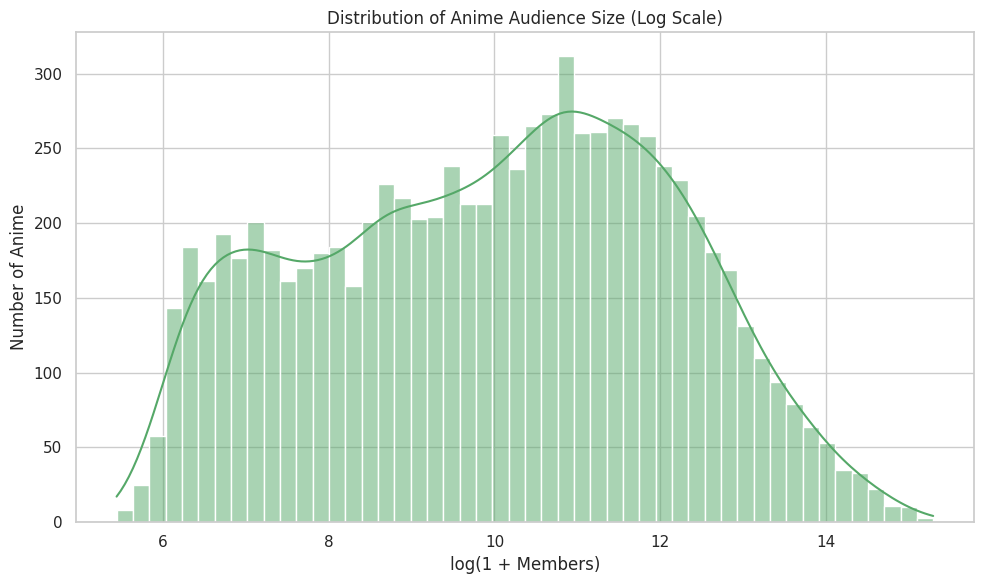

In [101]:
# since member is right skew
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(d['members'].dropna()),
    bins=50,
    kde=True,
    color= "#55A868"
)

plt.title('Distribution of Anime Audience Size (Log Scale)')
plt.xlabel('log(1 + Members)')
plt.ylabel('Number of Anime')

plt.tight_layout()
plt.show()

In [102]:
genre_audience = (
    d[['genres', 'members', 'balanced_score']]
    .explode('genres')
    .dropna(subset=['genres', 'members', 'balanced_score'])
    .groupby('genres')
    .agg(
        anime_count=('members', 'count'),
        median_members=('members', 'median'),
        mean_members=('members', 'mean'),
        median_balanced_score=('balanced_score', 'median'),
        mean_balanced_score=('balanced_score', 'mean')
    )
    .sort_values('median_balanced_score', ascending=False)
)

print(genre_audience)

               anime_count  median_members   mean_members  \
genres                                                      
Suspense               329        157224.0  394573.306991   
Girls Love              61         70645.0  103888.131148   
Romance               1299         93260.0  207486.889915   
Drama                 1442         51211.0  187754.378641   
Mystery                641         52403.0  169060.524181   
Supernatural           791         60773.0  216747.355247   
Ecchi                  389        107870.0  222179.539846   
Sports                 359         30371.0  102992.802228   
Boys Love               92         32163.0   63997.217391   
Action                2737         37401.0  180043.473877   
Horror                 235         36505.0  191880.936170   
Sci-Fi                1428         26395.0  114072.133053   
Adventure             1764         21289.0  134360.538549   
Gourmet                104         27868.0  121632.817308   
Fantasy               24

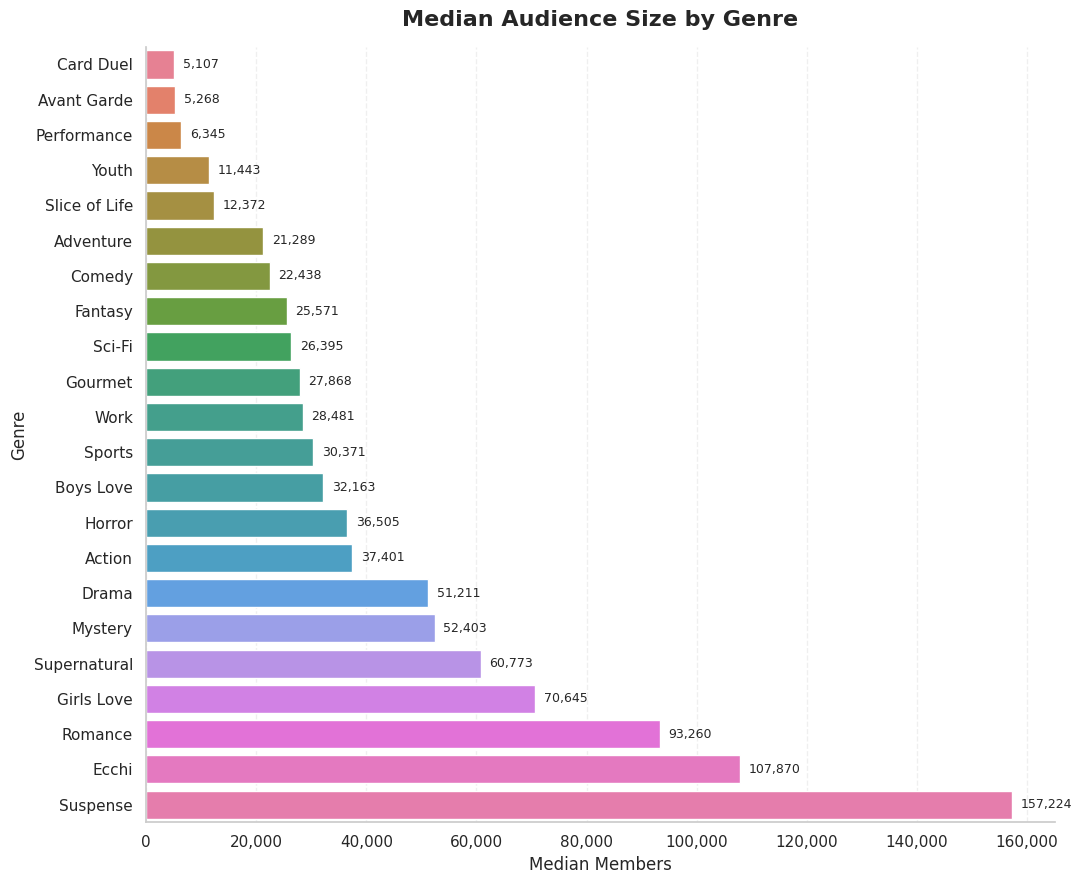

In [105]:
plot_df = (
    genre_audience
    .sort_values('median_members', ascending=True)
    .reset_index()
)

plt.figure(figsize=(11, 9))

ax = sns.barplot(
    data=plot_df,
    x='median_members',
    y='genres',
    hue='genres',
    legend=False
)

# Add values at the end of each bar
for i, value in enumerate(plot_df['median_members']):
    ax.text(
        value + plot_df['median_members'].max() * 0.01,
        i,
        f'{value:,.0f}',
        va='center',
        fontsize=9
    )

plt.title(
    'Median Audience Size by Genre',
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Median Members',
    fontsize=12
)

plt.ylabel(
    'Genre',
    fontsize=12
)

# Format x-axis
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'{x:,.0f}')
)

ax.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

ax.set_axisbelow(True)

sns.despine(
    top=True,
    right=True
)

plt.tight_layout()
plt.show()

# Genre Performance analysis

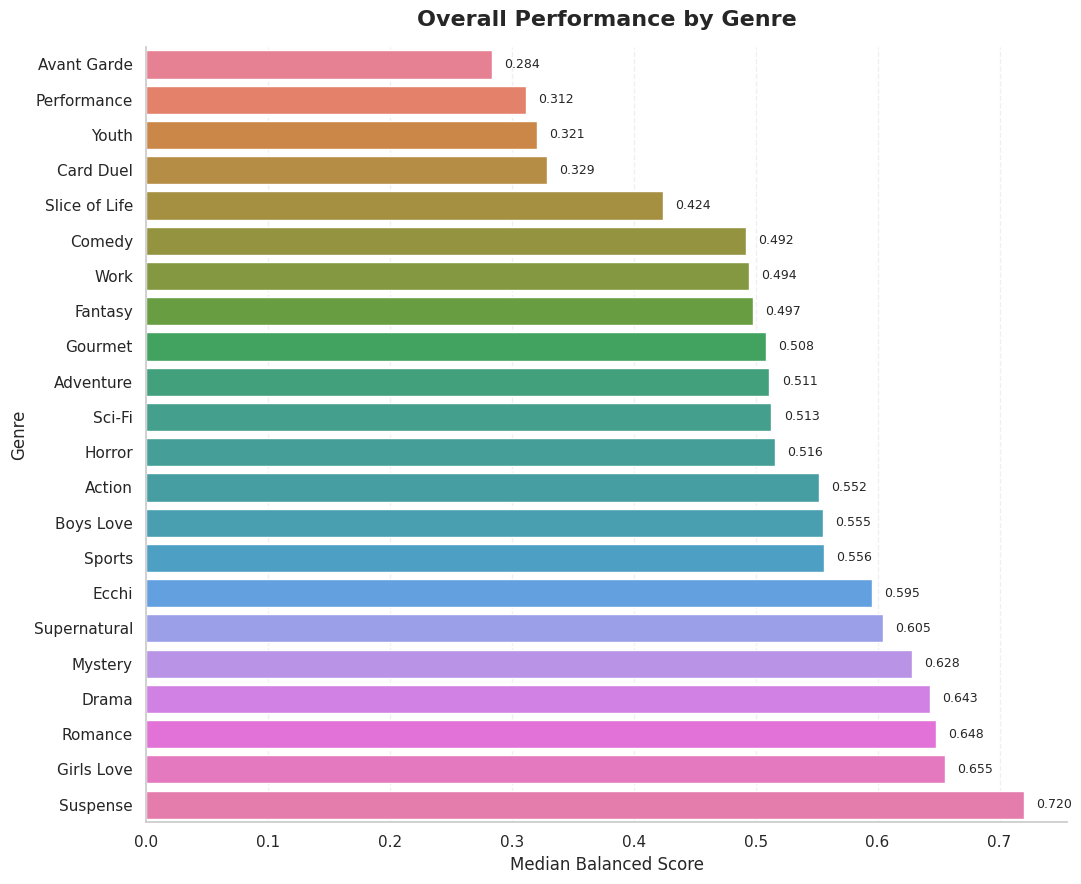

In [104]:

genre_audience = (
    df
    .explode('genres')
    .dropna(subset=['genres', 'balanced_score'])
    .groupby('genres')
    .agg(
        anime_count=('title', 'nunique'),
        median_balanced_score=('balanced_score', 'median'),
        mean_balanced_score=('balanced_score', 'mean'),
        median_score=('score', 'median'),
        median_members=('members', 'median'),
        median_favorites=('favorites', 'median'),
        median_popularity=('popularity', 'median')
    )
)

plot_df = (
    genre_audience
    .sort_values('median_balanced_score', ascending=True)
    .reset_index()
)

plt.figure(figsize=(11, 9))

ax = sns.barplot(
    data=plot_df,
    x='median_balanced_score',
    y='genres',
    hue='genres',
    legend=False
)

for i, value in enumerate(plot_df['median_balanced_score']):
    ax.text(
        value + 0.01,
        i,
        f'{value:.3f}',
        va='center',
        fontsize=9
    )

plt.title(
    'Overall Performance by Genre',
    fontsize=16,
    fontweight='bold',
    pad=15
)
plt.xlabel('Median Balanced Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)

ax.grid(axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

## RQ2 (Production & Studio Performance): Which production entities (studios, producers, and their co-production partnerships) generate high-yield, consistent success across quality and reach?

RQ3 (Thematic & Content Associations): What frequent combinations of genres, themes, and production entities yield statistically significant lifts in market success?

RQ4 (Latent Narrative Archetypes): Can unsupervised clustering on unstructured synopses discover narrative archetypes that out-partition or validate surface-level genre taxonomies?

1. Which genres and themes most strongly occur together, independent of performance outcome? 150 min anime

In [107]:
from mlxtend.preprocessing import TransactionEncoder 
from mlxtend.frequent_patterns import fpgrowth, association_rules 
import warnings

warnings.filterwarnings('ignore', category=DeprecationWarning)

hi_cut, mid_cut = d['balanced_score'].quantile(0.75), d['balanced_score'].quantile(0.40) 
def bscore_bin(s): 
    if s >= hi_cut: 
        return 'Balanced_High' 
    elif s >= mid_cut: 
        return 'Balanced_Mid' 
    else: return 'Balanced_Low' 

d['bscore_bin'] = d['balanced_score'].apply(bscore_bin) 
print(d['bscore_bin'].value_counts()) 
theme_counts = d['themes'].explode().value_counts() 
top_themes = set(theme_counts[theme_counts >= 15].index) 
d['themes_clean'] = d['themes'].apply(lambda lst: [t for t in lst if t in top_themes]) 
producer_counts = d['producers'].explode().value_counts() 
top_producers = set(producer_counts[producer_counts >= 20].index) 
d['producers_clean'] = d['producers'].apply(lambda lst: [p for p in lst if p in top_producers]) 

def build_txn(row): 
    items = [] 
    items += [f'Genre_{g}' for g in row['genres']] 
    items += [f'Theme_{t}' for t in row['themes_clean']]  
    return items 
    
transactions = d.apply(build_txn, axis=1).tolist() 
te = TransactionEncoder() 
te_ary = te.fit(transactions).transform(transactions) 
basket = pd.DataFrame(te_ary, columns=te.columns_) 
print('Basket shape:', basket.shape) 


bscore_bin
Balanced_Low     3291
Balanced_Mid     2879
Balanced_High    2057
Name: count, dtype: int64
Basket shape: (8227, 74)


In [108]:
# FP-Growth 
freq = fpgrowth(
    basket,
    min_support=0.015,
    use_colnames=True
)

print('Frequent itemsets:', len(freq))

# Generate association rules
rules = association_rules(
    freq,
    metric='confidence',
    min_threshold=0.30
)


rules_gt = rules[
    rules['lift'] > 1.0
].sort_values(
    ['lift', 'confidence'],
    ascending=False
).reset_index(drop=True)

print('Total rules:', len(rules_gt))

Frequent itemsets: 163
Total rules: 210


In [109]:

def all_prefixed(itemset, prefixes):
    return any(str(i).startswith(prefixes) for i in itemset)


In [138]:

# 1) Pure genre <-> theme co-occurrence
gt_rules = rules_gt[rules_gt['antecedents'].apply(lambda x: all_prefixed(x, ('Genre_', 'Theme_'))) &
                  rules_gt['consequents'].apply(lambda x: all_prefixed(x, ('Genre_', 'Theme_')))]
print('Genre/Theme co-occurrence (top 10 by lift):')
gt_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values(['lift'], ascending=False).iloc[20:50]


Genre/Theme co-occurrence (top 10 by lift):


,antecedents,consequents,support,confidence,lift
20,"(Genre_Adventure, Theme_Historical)","(Theme_Martial Arts, Genre_Fantasy, Genre_Action)",0.021736,0.507205,13.421032
21,"(Theme_Martial Arts, Genre_Fantasy)","(Genre_Adventure, Theme_Historical)",0.021736,0.575163,13.421032
22,"(Theme_Martial Arts, Genre_Fantasy, Genre_Action)","(Genre_Adventure, Theme_Historical)",0.021736,0.575163,13.421032
23,"(Genre_Fantasy, Theme_Historical, Genre_Action)",(Theme_Martial Arts),0.027294,0.726974,13.287372
24,(Theme_Martial Arts),"(Genre_Fantasy, Theme_Historical, Genre_Action)",0.027294,0.498871,13.287372
25,"(Genre_Adventure, Theme_Historical, Genre_Action)",(Theme_Martial Arts),0.025071,0.707317,12.928096
26,(Theme_Martial Arts),"(Genre_Adventure, Theme_Historical, Genre_Action)",0.025071,0.458239,12.928096
27,(Theme_Detective),(Genre_Mystery),0.020501,0.994012,12.734992
28,"(Genre_Adventure, Theme_Martial Arts, Genre_Fa...","(Theme_Historical, Genre_Action)",0.021736,0.748936,12.401096
29,"(Theme_Historical, Genre_Action)","(Genre_Adventure, Theme_Martial Arts, Genre_Fa...",0.021736,0.359918,12.401096




**1. Theme_Team Sports → Genre_Sports**
This is your strongest and cleanest rule. A confidence of **100%** means every anime containing the `Team Sports` theme in this rule set also has the `Sports` genre.

**2. Theme_Psychological → Genre_Suspense**
Very intuitive relationship, with a strong **16.52 lift**. This is an excellent example to discuss in your report.

**3. Genre_Adventure + Theme_Martial Arts → Genre_Fantasy + Theme_Historical + Genre_Action**
This captures the major **Martial Arts / Adventure / Fantasy / Historical / Action** pattern without listing all its redundant variants.

**4. Theme_Idols (Female) → Theme_Music**
Very easy to understand and has **83.33% confidence**.

**5. Theme_Detective → Genre_Mystery**
This is particularly strong because confidence is **99.40%** and lift is **12.73**. It's also much cleaner than the complicated Martial Arts rules.

**6. Genre_Fantasy + Theme_Historical + Genre_Action → Theme_Martial Arts**
I would keep this because it shows the reverse perspective of the Martial Arts pattern and has **72.70% confidence**. It also has higher support than many of the other rules.

**7. Theme_Harem → Genre_Ecchi**
A different type of relationship from the Martial Arts cluster, with a strong **10.82 lift**.

**8. Genre_Sci-Fi + Theme_Military → Theme_Mecha**
This gives you another distinct association rather than filling the last slots with more Martial Arts combinations.

---

For example, rules **23–26, 30–45** are repeatedly telling you:

**Martial Arts ↔ Adventure + Fantasy + Historical + Action**


### Final table 

| # | Association                                                                                | Support | Confidence |      Lift |
| - | ------------------------------------------------------------------------------------------ | ------: | ---------: | --------: |
| 1 | **Theme_Team Sports → Genre_Sports**                                                       |   1.90% |    100.00% | **22.62** |
| 2 | **Genre_Adventure + Theme_Martial Arts → Genre_Fantasy + Theme_Historical + Genre_Action** |   2.17% |     62.41% | **16.62** |
| 3 | **Theme_Psychological → Genre_Suspense**                                                   |   2.38% |     66.32% | **16.52** |
| 4 | **Theme_Idols (Female) → Theme_Music**                                                     |   1.54% |     83.33% | **14.93** |
| 5 | **Genre_Fantasy + Theme_Historical + Genre_Action → Theme_Martial Arts**                   |   2.73% |     72.70% | **13.29** |
| 6 | **Theme_Detective → Genre_Mystery**                                                        |   2.05% |     99.40% | **12.73** |
| 7 | **Theme_Harem → Genre_Ecchi**                                                              |   1.88% |     51.70% | **10.82** |
| 8 | **Genre_Sci-Fi + Theme_Military → Theme_Mecha**                                            |   1.67% |     57.94% |  **9.79** |


### Which producers are characteristically associated with particular genre/theme combinations?

In [139]:


def build_producer_txn(row):
    items = []

    # Genres
    items += [
        f'Genre_{g}'
        for g in row['genres']
    ]

    # Themes
    items += [
        f'Theme_{t}'
        for t in row['themes_clean']
    ]

    # Producers
    items += [
        f'Producer_{p}'
        for p in row['producers_clean']
    ]
    
    return items


producer_transactions = d.apply(
    build_producer_txn,
    axis=1
).tolist()


te_producer = TransactionEncoder()

te_ary_producer = te_producer.fit(
    producer_transactions
).transform(
    producer_transactions
)

basket_producer = pd.DataFrame(
    te_ary_producer,
    columns=te_producer.columns_
)

print('Basket shape:', basket_producer.shape)

unexpected_items = [
    c for c in basket_producer.columns
    if c.startswith(('Balanced_', 'Studio_'))
]

print('Unexpected items:', unexpected_items)





Basket shape: (8097, 292)
Unexpected items: []


In [140]:

freq_producer = fpgrowth(
    basket_producer,
    min_support=0.01,
    use_colnames=True
)

print('Frequent itemsets:', len(freq_producer))



rules_producer = association_rules(
    freq_producer,
    metric='confidence',
    min_threshold=0.30
)


rules_producer = rules_producer[
    rules_producer['lift'] > 1.0
].sort_values(
    ['lift', 'confidence'],
    ascending=False
).reset_index(drop=True)

print('Total rules:', len(rules_producer))

Frequent itemsets: 477
Total rules: 545


In [141]:
def has_prefix(itemset, prefixes):
    return any(
        str(item).startswith(prefixes)
        for item in itemset
    )


def all_have_prefix(itemset, prefixes):
    return all(
        str(item).startswith(prefixes)
        for item in itemset
    )


producer_genre_theme_rules = rules_producer[
    rules_producer['antecedents'].apply(
        lambda x: has_prefix(x, 'Producer_')
    )
    &
    rules_producer['consequents'].apply(
        lambda x: all_have_prefix(
            x,
            ('Genre_', 'Theme_')
        )
    )
].reset_index(drop=True)


print(
    'Producer → Genre/Theme rules:',
    len(producer_genre_theme_rules)
)

Producer → Genre/Theme rules: 191


In [149]:
producer_genre_theme_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].sort_values('lift', ascending=False).head(10)


,antecedents,consequents,support,confidence,lift
0,"(Theme_Historical, Producer_Tencent Video, Gen...","(Theme_Martial Arts, Genre_Fantasy)",0.010745,0.836538,22.135464
1,"(Theme_Martial Arts, Producer_Tencent Video)","(Genre_Fantasy, Theme_Historical, Genre_Action)",0.010745,0.820755,21.860694
2,"(Theme_Historical, Producer_Tencent Video)","(Theme_Martial Arts, Genre_Fantasy)",0.010745,0.719008,19.025523
3,"(Theme_Historical, Producer_Tencent Video)","(Theme_Martial Arts, Genre_Fantasy, Genre_Action)",0.010745,0.719008,19.025523
4,"(Theme_Martial Arts, Producer_Tencent Video)","(Genre_Fantasy, Theme_Historical)",0.010745,0.820755,18.307578
5,"(Theme_Martial Arts, Producer_Tencent Video, G...","(Genre_Fantasy, Theme_Historical)",0.010745,0.820755,18.307578
6,"(Genre_Adventure, Producer_Tencent Video)","(Genre_Fantasy, Theme_Historical, Genre_Action)",0.010004,0.648000,17.259395
7,"(Producer_Tencent Video, Genre_Action)","(Theme_Martial Arts, Genre_Fantasy, Theme_Hist...",0.010745,0.470270,17.229766
8,"(Genre_Adventure, Producer_Tencent Video, Genr...","(Genre_Fantasy, Theme_Historical)",0.010004,0.743119,16.575859
9,"(Genre_Fantasy, Producer_Tencent Video, Genre_...","(Theme_Martial Arts, Theme_Historical)",0.010745,0.540373,16.510934


specifically mining **Producers + Genres + Themes**, these:

| #     | Association                                                                                       | Support | Confidence |     Lift |
| ----- | ------------------------------------------------------------------------------------------------- | ------: | ---------: | -------: |
| **1** | **Theme_Martial Arts + Producer_Tencent Video → Genre_Fantasy + Theme_Historical + Genre_Action** |   1.26% | **96.23%** | **3.28** |
| **2** | **Producer_Tencent Video + Genre_Action → Genre_Fantasy**                                         |   1.99% | **87.03%** | **2.97** |
| **3** | **Genre_Sci-Fi + Producer_Bandai Visual → Theme_Mecha**                                           |   1.01% |     55.78% | **9.43** |
| **4** | **Genre_Fantasy + Producer_KADOKAWA → Theme_Isekai**                                              |   1.04% |     38.18% | **9.15** |
| **5** | **Producer_Bilibili + Genre_Action → Genre_Adventure**                                            |   1.15% |     59.24% | **2.79** |
| **6** | **Producer_Tencent Video → Genre_Fantasy**                                                        |   2.36% |     74.90% | **2.55** |
| **7** | **Producer_Lantis → Theme_School**                                                                |   2.16% |     37.31% | **2.23** |
| **8** | **Producer_Fuji TV → Genre_Drama**                                                                |   1.36% |     33.54% | **1.90** |



> **The association-rule analysis reveals several notable relationships between producers, genres, and themes. Tencent Video is strongly associated with Fantasy, particularly when combined with Action and Martial Arts themes, where Fantasy, Historical, and Action characteristics occur with very high confidence. Bandai Visual shows a distinct association with Sci-Fi and Mecha, while KADOKAWA is strongly associated with Isekai within Fantasy titles. Bilibili also shows an association between Action and Adventure. These patterns suggest that certain producers are associated with recognizable combinations of anime genres and themes rather than with individual genres alone.**


## Producers , genres , themes and score

In [151]:


def build_producer_txn(row):
    items = []

    # Genres
    items += [
        f'Genre_{g}'
        for g in row['genres']
    ]

    # Themes
    items += [
        f'Theme_{t}'
        for t in row['themes_clean']
    ]

    # Producers
    items += [
        f'Producer_{p}'
        for p in row['producers_clean']
    ]
    items.append(row['bscore_bin'])
    return items


producer_transactions = d.apply(
    build_producer_txn,
    axis=1
).tolist()


te_producer = TransactionEncoder()

te_ary_producer = te_producer.fit(
    producer_transactions
).transform(
    producer_transactions
)

basket_producer = pd.DataFrame(
    te_ary_producer,
    columns=te_producer.columns_
)

print('Basket shape:', basket_producer.shape)




Basket shape: (8097, 295)


In [152]:

freq_producer = fpgrowth(
    basket_producer,
    min_support=0.01,
    use_colnames=True
)

print('Frequent itemsets:', len(freq_producer))



rules_producer = association_rules(
    freq_producer,
    metric='confidence',
    min_threshold=0.30
)


rules_producer_score = rules_producer[
    rules_producer['lift'] > 1.0
].sort_values(
    ['lift', 'confidence'],
    ascending=False
).reset_index(drop=True)

print('Total rules:', len(rules_producer_score))

Frequent itemsets: 781
Total rules: 1190


In [155]:
producer_high_rules = rules_producer_score[
    rules_producer_score['antecedents'].apply(
        lambda x: (
            any(str(i).startswith('Producer_') for i in x)
            and
            any(
                str(i).startswith(('Genre_', 'Theme_'))
                for i in x
            )
        )
    )
    &
    rules_producer_score['consequents'].apply(
        lambda x: x == {'Balanced_High'}
    )
].sort_values(
    ['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True).head(10)

producer_high_rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift']
].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   antecedents  10 non-null     object 
 1   consequents  10 non-null     object 
 2   support      10 non-null     float64
 3   confidence   10 non-null     float64
 4   lift         10 non-null     float64
dtypes: float64(3), object(2)
memory usage: 532.0+ bytes


In [156]:
producer_high_rules[
    ['antecedents', 'consequents',
     'support', 'confidence', 'lift']
].head(10)

,antecedents,consequents,support,confidence,lift
0,"(Producer_Aniplex, Genre_Supernatural)",(Balanced_High),0.011609,0.752000,3.006886
1,"(Genre_Fantasy, Producer_Aniplex, Genre_Action)",(Balanced_High),0.010004,0.750000,2.998889
2,"(Producer_Aniplex, Genre_Romance)",(Balanced_High),0.010992,0.706349,2.824350
3,"(Producer_Aniplex, Genre_Action)",(Balanced_High),0.020995,0.671937,2.686752
4,"(Genre_Action, Producer_Shueisha)",(Balanced_High),0.017661,0.671362,2.684451
5,"(Producer_Mainichi Broadcasting System, Genre_...",(Balanced_High),0.011115,0.661765,2.646078
6,"(Theme_School, Producer_Aniplex)",(Balanced_High),0.010745,0.649254,2.596053
7,"(Theme_School, Producer_Shueisha)",(Balanced_High),0.011239,0.631944,2.526842
8,"(Producer_Dentsu, Genre_Action)",(Balanced_High),0.014203,0.628415,2.512730
9,"(Producer_Aniplex, Genre_Drama)",(Balanced_High),0.010127,0.621212,2.483928



### Selected Association Rules

| No.   | Association Rule                                                    | Support | Confidence |     Lift |
| ----- | ------------------------------------------------------------------- | ------: | ---------: | -------: |
| **1** | **Producer_Aniplex + Genre_Supernatural → Balanced_High**           |   1.16% |     75.20% | **3.01** |
| **2** | **Genre_Fantasy + Producer_Aniplex + Genre_Action → Balanced_High** |   1.00% |     75.00% | **3.00** |
| **3** | **Producer_Aniplex + Genre_Romance → Balanced_High**                |   1.10% |     70.63% | **2.82** |
| **4** | **Producer_Aniplex + Genre_Action → Balanced_High**                 |   2.10% |     67.19% | **2.69** |
| **5** | **Genre_Action + Producer_Shueisha → Balanced_High**                |   1.77% |     67.14% | **2.68** |
| **6** | **Theme_School + Producer_Aniplex → Balanced_High**                 |   1.07% |     64.93% | **2.60** |
| **7** | **Theme_School + Producer_Shueisha → Balanced_High**                |   1.12% |     63.19% | **2.53** |
| **8** | **Producer_Dentsu + Genre_Action → Balanced_High**                  |   1.42% |     62.84% | **2.51** |

### Interpretation

The selected rules indicate that several **producer–genre and producer–theme combinations are positively associated with high Balanced Scores**. The strongest association is **Producer_Aniplex + Genre_Supernatural → Balanced_High**, with 75.20% confidence and a lift of 3.01. This means that anime matching this producer–genre combination are substantially more likely to fall into the Balanced_High category than anime in the dataset overall.

The rules also show recurring patterns involving **Aniplex and Action, Fantasy, Romance, Supernatural, and School-related anime**, while **Shueisha** and **Dentsu** also show positive associations with Balanced_High. This suggests that both **producer involvement and content characteristics** may be useful indicators when examining anime performance.

### How this validates real-world patterns

These findings are **consistent with real-world anime production and market patterns**, where major producers such as Aniplex and Shueisha are heavily involved in commercially visible anime across popular genres such as Action, Fantasy, Romance, and Supernatural. The fact that multiple producer–genre/theme combinations have **confidence above 60% and lift above 2.5** provides quantitative evidence that these combinations are associated with stronger balanced performance in the dataset.

However, the rules should be interpreted as **associations rather than causal relationships**. They do not prove that a particular producer or genre causes an anime to achieve a high Balanced Score. Instead, they provide data-driven evidence of patterns that are compatible with observed industry behavior.

> **Overall, the association rules validate that producer, genre, and theme combinations can reveal meaningful patterns related to anime performance, while also demonstrating that these relationships should be interpreted within the context of the analyzed dataset.**


## Which genres/themes are each studio particularly associated with?

In [158]:
studio_counts = d['studios'].explode().value_counts()
top_studios = set(studio_counts[studio_counts >= 20].index) 

d['studios_clean'] = d['studios'].apply(lambda lst: [p for p in lst if p in top_studios]) 

def build_studio_txn(row):
    items = []

    items += [f'Genre_{g}' for g in row['genres']]
    items += [f'Theme_{t}' for t in row['themes_clean']]
    items += [f'Studio_{s}' for s in row['studios_clean']]

    return items


studio_transactions = d.apply(
    build_studio_txn,
    axis=1
).tolist()

te_studio = TransactionEncoder()

te_ary_studio = te_studio.fit(
    studio_transactions
).transform(studio_transactions)

basket_studio = pd.DataFrame(
    te_ary_studio,
    columns=te_studio.columns_
)

print('Basket shape:', basket_studio.shape)

Basket shape: (8097, 168)


In [159]:
[c for c in basket_studio.columns
 if c.startswith(('Balanced_', 'Producer_'))]

[]

In [169]:
freq_studio = fpgrowth(
    basket_studio,
    min_support=0.00625, # 50 anime
    use_colnames=True
)

rules_studio = association_rules(
    freq_studio,
    metric='confidence',
    min_threshold=0.30
)

rules_studio = rules_studio[
    rules_studio['lift'] > 1.3
].sort_values(
    ['lift', 'confidence'],
    ascending=False
).reset_index(drop=True)


print('Total rules:', len(rules_studio))

Total rules: 607


In [170]:
def any_prefixed(items, prefix):
    return any(str(i).startswith(prefix) for i in items)
studio_success_rules = rules_studio[
    rules_studio['antecedents'].apply(
        lambda x: any_prefixed(x, 'Studio_')
    ) &
    rules_studio['consequents'].apply(
        lambda x: any(str(i).startswith(('Genre_', 'Theme_')) for i in x)
    )
]



studio_success_rules.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77 entries, 0 to 602
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   antecedents         77 non-null     object 
 1   consequents         77 non-null     object 
 2   antecedent support  77 non-null     float64
 3   consequent support  77 non-null     float64
 4   support             77 non-null     float64
 5   confidence          77 non-null     float64
 6   lift                77 non-null     float64
 7   representativity    77 non-null     float64
 8   leverage            77 non-null     float64
 9   conviction          77 non-null     float64
 10  zhangs_metric       77 non-null     float64
 11  jaccard             77 non-null     float64
 12  certainty           77 non-null     float64
 13  kulczynski          77 non-null     float64
dtypes: float64(12), object(2)
memory usage: 9.0+ KB


In [174]:

studio_success_rules[
    ['antecedents', 'consequents', 'support', 'confidence', 'lift']
].sort_values(
    'lift',
    ascending=False
).iloc[70:80]

,antecedents,consequents,support,confidence,lift
573,(Studio_Studio Pierrot),(Genre_Action),0.007534,0.525862,1.588771
576,(Studio_TMS Entertainment),(Genre_Adventure),0.008275,0.335000,1.577032
585,(Studio_Toei Animation),(Genre_Action),0.017908,0.493197,1.490081
593,(Studio_OLM),(Genre_Fantasy),0.008645,0.409357,1.395017
599,(Studio_J.C.Staff),(Genre_Fantasy),0.011115,0.396476,1.351121
600,(Studio_A-1 Pictures),(Genre_Action),0.009139,0.440476,1.330797
602,(Studio_J.C.Staff),(Genre_Comedy),0.013338,0.475771,1.322003


| #     | Selected Rule                                                              | Support | Confidence |      Lift |
| ----- | -------------------------------------------------------------------------- | ------: | ---------: | --------: |
| **1** | **Genre_Mystery + Studio_TMS Entertainment → Theme_Detective**             |  0.642% | **81.25%** | **39.39** |
| **2** | **Genre_Sci-Fi + Studio_Sunrise → Theme_Mecha**                            |  1.593% | **69.73%** | **11.79** |
| **3** | **Studio_Toei Animation + Genre_Fantasy → Genre_Adventure + Genre_Action** |  0.741% | **60.00%** |  **4.87** |
| **4** | **Studio_Ruo Hong Culture → Genre_Fantasy + Genre_Action**                 |  0.667% | **93.10%** |  **5.86** |
| **5** | **Studio_SILVER LINK. → Theme_School**                                     |  0.630% | **50.00%** |  **2.99** |
| **6** | **Studio_Shin-Ei Animation → Genre_Comedy**                                |  1.284% | **78.20%** |  **2.17** |
| Studio rule                                 |    Support | Confidence |     Lift |
| ------------------------------------------- | ---------: | ---------: | -------: |
| **Studio_Shin-Ei Animation → Genre_Comedy** | **1.284%** | **78.20%** | **2.17** |
| Studio_J.C.Staff → Theme_School             |     0.939% |     33.48% |     2.01 |
| Studio_OLM → Genre_Adventure                |     0.852% |     40.35% |     1.90 |




Small interpretation

1. TMS Entertainment + Mystery → Detective
This is the strongest rule by lift. Among anime associated with TMS Entertainment and the Mystery genre, the Detective theme occurs very frequently. The 81.25% confidence and 39.39 lift indicate a particularly strong relationship.

2. Sunrise + Sci-Fi → Mecha
This is a very distinctive studio–genre–theme pattern. The 11.79 lift indicates that Mecha is much more strongly associated with Sunrise's Sci-Fi anime than with anime overall. This is also a good example of a recognizable studio specialization.

3. Toei Animation + Fantasy → Adventure + Action
This identifies a broader genre combination associated with Toei Animation. It is useful because it connects one studio with multiple genres, rather than only showing a simple studio–genre relationship.

4. Ruo Hong Culture → Fantasy + Action
This has 93.10% confidence, making it one of the strongest predictive relationships in the results. It suggests that Fantasy and Action frequently occur together among the Ruo Hong Culture anime represented in the dataset.

5. SILVER LINK. → School
This introduces the Theme dimension and shows a positive association between SILVER LINK. and School-themed anime. Its lift of almost 3 indicates that this theme occurs substantially more often for this studio than in the overall dataset.

6. Shin-Ei Animation → Comedy
This is a useful, higher-support studio–genre pattern. With 78.20% confidence and 1.28% support, it is one of the more frequently observed associations in your selected results.

TMS Entertainment → Mystery/Detective
Sunrise → Sci-Fi/Mecha
Toei Animation → Fantasy/Adventure/Action
Ruo Hong Culture → Fantasy/Action
SILVER LINK. → School
Shin-Ei Animation → Comedy

## Which studio with what genre and themes gives the high balanced score ?


In [113]:


def build_studio_txn(row):
    items = []

    # Genres
    items += [
        f'Genre_{g}'
        for g in row['genres']
    ]

    # Themes
    items += [
        f'Theme_{t}'
        for t in row['themes_clean']
    ]

    # Studios
    items += [
        f'Studio_{s}'
        for s in row['studios_clean']
    ]

    # Balanced Score category
    items.append(row['bscore_bin'])

    return items


studio_transactions = d.apply(
    build_studio_txn,
    axis=1
).tolist()



te_studio = TransactionEncoder()

te_ary_studio = te_studio.fit(
    studio_transactions
).transform(
    studio_transactions
)

basket_studio = pd.DataFrame(
    te_ary_studio,
    columns=te_studio.columns_
)

print("Basket shape:", basket_studio.shape)



freq_studio = fpgrowth(
    basket_studio,
    min_support=0.005,
    use_colnames=True
)

print("Frequent itemsets:", len(freq_studio))


rules_studio = association_rules(
    freq_studio,
    metric='confidence',
    min_threshold=0.30
)



rules_studio = rules_studio[
    rules_studio['lift'] > 1.0
].copy()



studio_high_rules = rules_studio[
    rules_studio['antecedents'].apply(
        lambda x: (
            any(str(i).startswith('Studio_') for i in x)
            and
            any(
                str(i).startswith(('Genre_', 'Theme_'))
                for i in x
            )
        )
    )
    &
    rules_studio['consequents'].apply(
        lambda x: x == {'Balanced_High'}
    )
].sort_values(
    ['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)


studio_high_rules[
    [
        'antecedents',
        'consequents',
        'support',
        'confidence',
        'lift'
    ]
].head(10)

Basket shape: (8227, 175)
Frequent itemsets: 1214


,antecedents,consequents,support,confidence,lift
0,"(Genre_Action, Studio_A-1 Pictures)",(Balanced_High),0.006199,0.689189,2.756422
1,"(Genre_Action, Studio_Bones)",(Balanced_High),0.005348,0.656716,2.626546
2,"(Genre_Drama, Studio_Madhouse)",(Balanced_High),0.005227,0.565789,2.262883
3,"(Genre_Comedy, Studio_J.C.Staff)",(Balanced_High),0.005834,0.444444,1.777562
4,"(Studio_Toei Animation, Genre_Adventure)",(Balanced_High),0.005105,0.375000,1.499818
5,"(Genre_Action, Studio_Toei Animation)",(Balanced_High),0.005470,0.304054,1.216068


### Selecting all here



## Studio Collaboration Outcomes

In [115]:
from itertools import combinations

# Producer x Studio outcome table
dn2 = d[(d['producers'].apply(len) >= 1) & (d['studios'].apply(len) >= 1)].copy()
rows2 = []
for _, row in dn2.iterrows():
    for p in set(row['producers']):
        for s in set(row['studios']):
            rows2.append({'producer': p, 'studio': s, 'balanced_score': row['balanced_score'], 'members': row['members']})
ps_df = pd.DataFrame(rows2)
ps_collab = (ps_df.groupby(['producer', 'studio'])
             .agg(num_titles=('balanced_score', 'count'), avg_balanced_score=('balanced_score', 'mean'), avg_members=('members', 'mean'))
             .reset_index())
ps_collab = ps_collab[ps_collab['num_titles'] >= 5].sort_values('avg_balanced_score', ascending=False)
print('Top Producer x Studio combos by avg balanced_score (min. 5 shared titles):')
ps_collab.head(10)


Top Producer x Studio combos by avg balanced_score (min. 5 shared titles):


,producer,studio,num_titles,avg_balanced_score,avg_members
3928,Frontier Works,Studio Bind,5,0.961260,8.693126e+05
7290,Medicos Entertainment,David Production,8,0.956490,1.037622e+06
11236,TOHO Animation,Studio Bind,5,0.944017,8.579118e+05
4760,Hakuhodo DY Music & Pictures,Studio Bind,6,0.941407,7.564743e+05
3324,Dentsu,Studio Ghibli,6,0.940757,8.479440e+05
9766,Shogakukan-Shueisha Productions,CloverWorks,5,0.938826,8.742988e+05
11213,TOHO Animation,CloverWorks,5,0.938826,8.742988e+05
5559,KADOKAWA,Studio Bind,6,0.934933,7.398587e+05
11404,TV Tokyo,CloverWorks,6,0.931004,8.225028e+05
7340,Memory-Tech,White Fox,7,0.930504,9.077004e+05


In [116]:
top10_pairs = ps_collab.head(10)

for _, row in top10_pairs.iterrows():
    producer = row['producer']
    studio = row['studio']

    pair = d[
        d['producers'].apply(lambda x: producer in x)
        & d['studios'].apply(lambda x: studio in x)
    ].copy()

    print("\n" + "=" * 70)
    print(f"Producer: {producer}")
    print(f"Studio: {studio}")
    print(f"Shared titles: {len(pair)}")
    print("=" * 70)

    print(
        pair[['title', 'balanced_score', 'score', 'members']]
        .sort_values('balanced_score', ascending=False)
        .to_string(index=False)
    )


Producer: Frontier Works
Studio: Studio Bind
Shared titles: 5
                                             title  balanced_score  score  members
   Mushoku Tensei: Isekai Ittara Honki Dasu Part 2        0.983688   8.60  1138373
          Mushoku Tensei: Isekai Ittara Honki Dasu        0.980382   8.32  1595976
Mushoku Tensei II: Isekai Ittara Honki Dasu Part 2        0.957068   8.38   590040
       Mushoku Tensei II: Isekai Ittara Honki Dasu        0.956801   8.20   772887
      Mushoku Tensei III: Isekai Ittara Honki Dasu        0.928361   8.98   249287

Producer: Medicos Entertainment
Studio: David Production
Shared titles: 8
                                                          title  balanced_score  score  members
                 JoJo no Kimyou na Bouken Part 5: Ougon no Kaze        0.986046   8.58  1184209
          JoJo no Kimyou na Bouken Part 4: Diamond wa Kudakenai        0.985317   8.51  1284108
JoJo no Kimyou na Bouken Part 3: Stardust Crusaders - Egypt-hen        0.981

### Observation: Producer–Studio Collaboration and Franchise Continuation

The producer–studio collaboration analysis shows that high-performing collaborations are frequently associated with established anime franchises that continue across multiple seasons, parts, or movies. For example, Medicos Entertainment and David Production produced eight JoJo titles, all achieving high Balanced Scores. Similarly, TOHO Animation and CloverWorks collaborated on multiple Spy × Family installments, while Memory-Tech and White Fox worked together across several Re:Zero seasons and movies. Frontier Works, TOHO Animation, Hakuhodo DY Music & Pictures, and KADOKAWA also show repeated collaboration with Studio Bind across Mushoku Tensei installments.

The results indicate that these recurring collaborations tend to maintain strong audience engagement and performance, as reflected by high Balanced Scores and large member counts. This suggests that successful franchises may encourage producers and studios to continue working together on subsequent installments.

However, the findings represent association rather than causation. The analysis cannot establish that a particular producer–studio partnership directly causes an anime to become successful or receive further installments. Instead, it suggests that successful and established franchises often retain their existing production partnerships as the franchise expands.


##  Text Mining for Descriptive NLP Storyline Clustering, Genre-Alignment Validation & 
Research questions

Can we group anime into storyline "archetypes" purely from the synopsis text, without using genre tags at all?
What is the right number of clusters (k), chosen objectively rather than guessed?
Do the resulting text-only clusters actually line up with the human-assigned genre tags — i.e. is the storyline embedding capturing something real?


In [89]:
import pandas as pd
import numpy as np

In [90]:
d = pd.read_csv("/kaggle/input/datasets/yoonthiriaung/working-data-latest/working_dataset_10_9_2026_latest.csv")

In [91]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8227 entries, 0 to 8226
Data columns (total 36 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mal_id                8227 non-null   int64  
 1   title                 8227 non-null   object 
 2   title_english         5979 non-null   object 
 3   title_japanese        8209 non-null   object 
 4   title_synonym         5026 non-null   object 
 5   type                  8227 non-null   object 
 6   source                8227 non-null   object 
 7   status                8227 non-null   object 
 8   rating                8227 non-null   object 
 9   score                 8227 non-null   float64
 10  scored_by             8227 non-null   float64
 11  rank                  8227 non-null   float64
 12  popularity            8227 non-null   int64  
 13  members               8227 non-null   int64  
 14  favorites             8227 non-null   int64  
 15  season               

In [92]:
import ast

def parse_list_col(x):
    """ turn a stringified list like "['Action', 'Adventure']" into an actual list."""

    if isinstance(x, list):
        return x


    if not isinstance(x, str):
        return []

    try:
        v = ast.literal_eval(x)
        return v if isinstance(v, list) else []
    except (ValueError, SyntaxError):
        return []

LIST_COLS = ['genres', 'studios','themes', 'producers','demographics']

for col in LIST_COLS:
    d[col] = d[col].apply(parse_list_col)


d[LIST_COLS].head(6)

,genres,studios,themes,producers,demographics
0,"[Action, Drama, Suspense]",[Wit Studio],"[Gore, Military, Survival]","[Production I.G, Dentsu, Mainichi Broadcasting...",[Shounen]
1,"[Supernatural, Suspense]",[Madhouse],[Psychological],"[VAP, Nippon Television Network, Shueisha, D.N...",[Shounen]
2,"[Action, Adventure, Drama, Fantasy]",[Bones],[Military],"[Aniplex, Square Enix, Mainichi Broadcasting S...",[Shounen]
3,"[Action, Comedy]",[Madhouse],"[Adult Cast, Parody, Super Power]","[TV Tokyo, Bandai Visual, Lantis, Asatsu DK, B...",[Seinen]
4,"[Action, Supernatural]",[ufotable],[Historical],"[Aniplex, Studio Mausu, Shueisha]",[Shounen]
5,[Action],[Bones],"[School, Super Power]","[Dentsu, Mainichi Broadcasting System, Movic, ...",[Shounen]


In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize, MultiLabelBinarizer
from scipy.stats import chi2_contingency

dt = d[d['synopsis_clean'].notna() & (d['synopsis_clean'].str.len() >= 150)].copy().reset_index(drop=True)
print('Anime with a usable storyline synopsis:', len(dt), 'out of', len(d))

meta_stop = {
    'season', 'seasons', 'episode', 'episodes', 'ova', 'ona', 'special', 'specials', 'movie', 'movies',
    'film', 'films', 'short', 'shorts', 'recap', 'sequel', 'tv', 'series', 'anime', 'adaptation', 'adapted',
    'bundled', 'volume', 'volumes', 'manga', 'light', 'novel', 'novels', 'game', 'games', 'video', 'anniversary',
    'collaboration', 'mini', 'characters', 'character', 'based', 'second', 'third', 'fourth', 'fifth', 'sixth',
    'part', 'story', 'stories', 'animated', 'animation', 'studio', 'aired',
}
stopwords = list(ENGLISH_STOP_WORDS.union(meta_stop))

tfidf = TfidfVectorizer(max_features=5000, stop_words=stopwords, ngram_range=(1, 2), min_df=3, max_df=0.4)
X_tfidf = tfidf.fit_transform(dt['synopsis_clean'])

svd = TruncatedSVD(n_components=100, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f'Variance explained by 100 SVD components: {svd.explained_variance_ratio_.sum():.1%}')


Anime with a usable storyline synopsis: 6798 out of 8227
Variance explained by 100 SVD components: 13.9%


In [94]:
for n in [10, 20, 30, 50, 75, 100]:
    variance = svd.explained_variance_ratio_[:n].sum()
    print(f"{n} components: {variance:.1%}")

10 components: 2.6%
20 components: 4.5%
30 components: 6.1%
50 components: 8.7%
75 components: 11.5%
100 components: 13.9%


In [95]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize

for n in [30, 50, 75, 100]:

    X_cluster = normalize(X_svd[:, :n])

    km = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_cluster)

    silhouette = silhouette_score(X_cluster, labels)

    variance = svd.explained_variance_ratio_[:n].sum()

    print(
        f"{n} components | "
        f"Variance: {variance:.1%} | "
        f"Silhouette: {silhouette:.4f}"
    )

30 components | Variance: 6.1% | Silhouette: 0.0601
50 components | Variance: 8.7% | Silhouette: 0.0382
75 components | Variance: 11.5% | Silhouette: 0.0271
100 components | Variance: 13.9% | Silhouette: 0.0213


In [96]:
# Get the actual word names from your TF-IDF vectorizer
terms = tfidf.get_feature_names_out()


for i, comp in enumerate(svd.components_[:5]):
    # Find the indices of the top 10 heaviest-weighted words for this component
    top_terms_idx = comp.argsort()[-10:][::-1]
    top_terms = [terms[idx] for idx in top_terms_idx]
    print(f"Component {i+1}: {', '.join(top_terms)}")


Component 1: school, world, life, new, high, girl, day, time, high school, friends
Component 2: school, high, high school, club, student, girls, students, class, school student, members
Component 3: earth, team, club, battle, war, members, humanity, academy, space, world
Component 4: world, demon, magic, martial, king, arts, academy, martial arts, demons, sword
Component 5: club, new, members, team, pokémon, japan, city, idol, group, join


In [97]:

X_cluster = normalize(X_svd[:, :30])   # cluster in a denoised sub-space, L2-normalized -> effectively cosine clustering


In [98]:
import matplotlib.pyplot as plt

Best K: 32
Best Silhouette Score: 0.1488


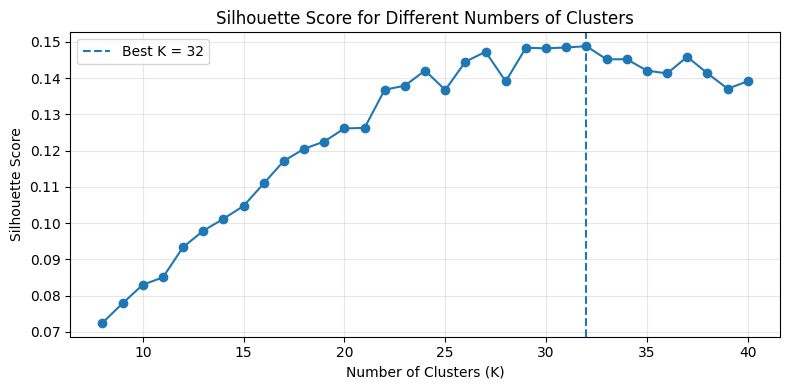

In [10]:
k_values = range(8, 41)
silhouette_scores = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_k = km.fit_predict(X_cluster)

    score = silhouette_score(
        X_cluster,
        labels_k,
        sample_size=3000,
        random_state=42
    )

    silhouette_scores.append(score)

# Select K with the highest silhouette score
best_k = k_values[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"Best K: {best_k}")
print(f"Best Silhouette Score: {best_score:.4f}")

# Plot
plt.figure(figsize=(8, 4))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)

plt.axvline(
    best_k,
    linestyle='--',
    label=f'Best K = {best_k}'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different Numbers of Clusters')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [99]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
dt['nlp_cluster'] = km.fit_predict(X_cluster)

terms = tfidf.get_feature_names_out()
for c in range(best_k):
    idx = dt[dt['nlp_cluster'] == c].index
    if len(idx) == 0:
        continue
    mean_vec = np.asarray(X_tfidf[idx].mean(axis=0)).ravel()
    top_terms = [terms[i] for i in mean_vec.argsort()[::-1][:8]]
    top_genres = dt.loc[idx, 'genres'].explode().value_counts().head(3)
    print(f'Cluster {c:2d} (n={len(idx):4d}): {top_terms}')
    print(f'             top genres -> {dict(top_genres)}')


Cluster  0 (n=  57): ['pokémon', 'satoshi', 'pikachu', 'region', 'pokemon', 'satoshi friends', 'legendary pokémon', 'legendary']
             top genres -> {'Fantasy': np.int64(51), 'Adventure': np.int64(45), 'Action': np.int64(34)}
Cluster  1 (n= 225): ['magic', 'kingdom', 'magical', 'princess', 'prince', 'world', 'witch', 'royal']
             top genres -> {'Fantasy': np.int64(160), 'Action': np.int64(97), 'Adventure': np.int64(80)}
Cluster  2 (n= 186): ['father', 'mother', 'boy', 'daughter', 'young', 'son', 'life', 'family']
             top genres -> {'Drama': np.int64(71), 'Adventure': np.int64(61), 'Action': np.int64(49)}
Cluster  3 (n= 318): ['war', 'empire', 'battle', 'country', 'power', 'military', 'holy', 'army']
             top genres -> {'Action': np.int64(217), 'Fantasy': np.int64(132), 'Sci-Fi': np.int64(103)}
Cluster  4 (n= 252): ['young', 'man', 'town', 'boy', 'young man', 'named', 'village', 'mysterious']
             top genres -> {'Fantasy': np.int64(93), 'Action':

## Statistical validation — do the text-only clusters actually track genre?

In [101]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency


dt_genres = dt[['nlp_cluster', 'genres']].copy()


dt_genres = dt_genres.explode('genres')


dt_genres['genres'] = dt_genres['genres'].fillna('Unknown')

ctab = pd.crosstab(dt_genres['nlp_cluster'], dt_genres['genres'])


chi2, p, dof, exp = chi2_contingency(ctab)
n = ctab.sum().sum()
cramers_v = np.sqrt(chi2 / (n * (min(ctab.shape) - 1)))

print(f'Chi-square = {chi2:.1f}, p-value = {p:.3g}')
print(f"Cramer's V (All Genres Included, 0-1) = {cramers_v:.3f}")


Chi-square = 10372.3, p-value = 0
Cramer's V (All Genres Included, 0-1) = 0.180


Statistical validation was performed using a Chi-square test of independence to examine the relationship between synopsis-based text clusters and anime genres. The test produced a Chi-square statistic of 10372.3 with a p-value approximately equal to 0, indicating a statistically significant association between the two variables. Cramér's V was 0.180, indicating a moderate association. This suggests that the synopsis-based clusters capture meaningful genre-related patterns, while also retaining storyline information beyond the predefined genre categories.

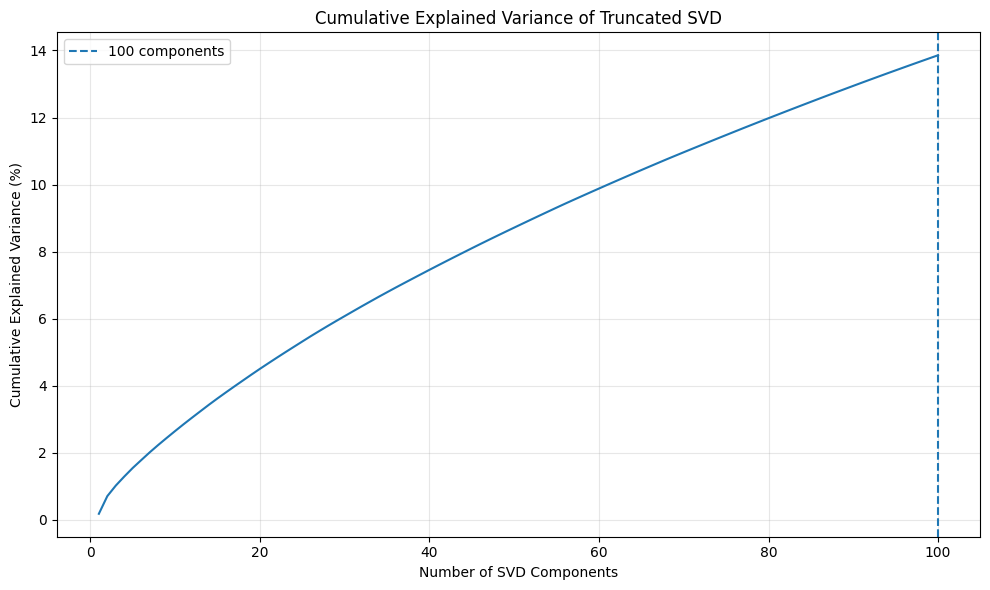

In [28]:
import matplotlib.pyplot as plt
import numpy as np

components = np.arange(1, len(svd.explained_variance_ratio_) + 1)
cumulative_variance = np.cumsum(svd.explained_variance_ratio_) * 100

plt.figure(figsize=(10, 6))
plt.plot(components, cumulative_variance)
plt.axvline(100, linestyle='--', label='100 components')

plt.xlabel('Number of SVD Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('Cumulative Explained Variance of Truncated SVD')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# PCA

PCA variance explained: 14.44%


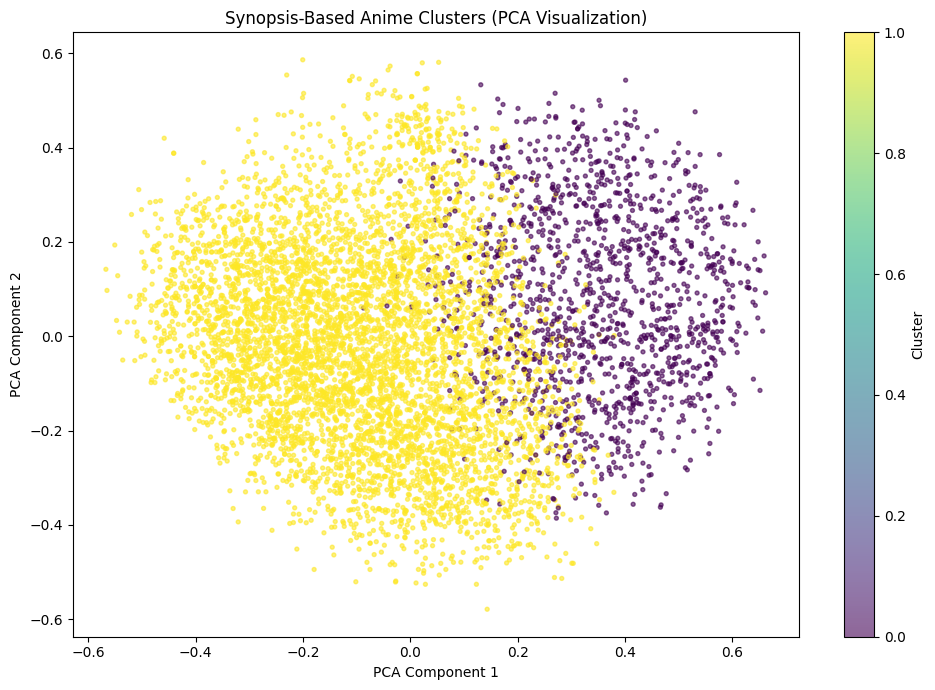

In [29]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_cluster)

print(
    f"PCA variance explained: "
    f"{pca.explained_variance_ratio_.sum():.2%}"
)

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=8,
    alpha=0.6
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Synopsis-Based Anime Clusters (PCA Visualization)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

```
Synopsis
   ↓
TF-IDF
   ↓
100 SVD components
   ↓
K-Means (K = 32)
   ↓
30 clusters
   ↓
PCA → 2 dimensions
   ↓
This plot
```
not the clustering itself. PCA is taking your 100-dimensional SVD representation and projecting it into 2 dimensions so humans can visualize it.

Each dot = one anime
PCA Component 1 = first visualization dimension
PCA Component 2 = second visualization dimension
Color = K-Means cluster
There are 32 different clusters/colors

Summary: Synopsis Clustering and PCA Visualization

The anime synopses were transformed using TF-IDF, reduced to 100 SVD components, and grouped into 32 clusters using K-Means. PCA was then applied to project the 100-dimensional representations into two dimensions for visualization.

The clustering reveals several distinct thematic groups, including Pokémon/Digimon stories, school and romance, sports, detective stories, space and science fiction, martial arts, idols/music, and fantasy or demon-related stories. Some clusters have clear and distinctive vocabulary, while others contain broader or overlapping themes.

In the 2D PCA plot, substantial overlap between clusters can be observed, particularly near the center. This is expected because PCA compresses the original 100-dimensional representation into only two dimensions. Therefore, the visualization does not perfectly represent the separation achieved in the original feature space, but it still provides a useful overview of the relationships between the clusters.


### Predictive Mining

#### Content-Based Hybrid Anime Recommendation¶

```
Input: "Fullmetal Alchemist: Brotherhood"
                    │
          ┌─────────┼─────────┐
          ↓         ↓         ↓
      Synopsis    Genres     Themes
          ↓         ↓         ↓
       TF-IDF    Multi-hot   Multi-hot
          ↓         └────┬────┘
         SVD              ↓
          ↓        Genre/Theme similarity
   Story similarity       │
          └───────┬───────┘
                  ↓
          Hybrid similarity
                  ↓
             Top-N Anime
```

In [30]:
# ============================================================
# HYBRID CONTENT-BASED ANIME RECOMMENDER
# Synopsis + Genre + Theme
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import MultiLabelBinarizer, normalize
from sklearn.metrics.pairwise import cosine_similarity


# ============================================================
# 1. STORYLINE REPRESENTATION
# ============================================================
# X_svd was already created from:
#
# TF-IDF -> SVD (100 components)
#
# Use all 100 components for recommendation.

X_recommend = normalize(X_svd)


# ============================================================
# 2. GENRE + THEME REPRESENTATION
# ============================================================

mlb_g = MultiLabelBinarizer()
mlb_t = MultiLabelBinarizer()

G = mlb_g.fit_transform(dt['genres'])
T = mlb_t.fit_transform(dt['themes'])

# Combine genres and themes
GT = np.hstack([G, T]).astype(float)

# Cosine similarity between every pair of anime
gt_sim = cosine_similarity(GT)


# ============================================================
# 3. STORYLINE SIMILARITY
# ============================================================

story_sim = cosine_similarity(X_recommend)


# ============================================================
# 4. HYBRID RECOMMENDER
# ============================================================

def recommend_by_title(
    title,
    top_n=5,
    w_story=0.6,
    w_genre=0.4
):
    """
    Hybrid content-based anime recommendation.

    Uses:
        1. Synopsis similarity
        2. Genre similarity
        3. Theme similarity

    Synopsis:
        TF-IDF -> SVD (100 components) -> cosine similarity

    Genre + Theme:
        MultiLabelBinarizer -> cosine similarity

    Final score:
        weighted combination of normalized
        storyline and genre/theme similarity.
    """

    # --------------------------------------------------------
    # Validate weights
    # --------------------------------------------------------

    if not np.isclose(w_story + w_genre, 1.0):
        raise ValueError(
            "w_story + w_genre must equal 1.0"
        )

    if top_n <= 0:
        raise ValueError(
            "top_n must be greater than 0"
        )

    # --------------------------------------------------------
    # Find title
    # Use dt, NOT d, so indices stay aligned
    # --------------------------------------------------------

    # --------------------------------------------------------
    # Find anime across all title fields
    # --------------------------------------------------------

    title_cols = [
    'title',
    'title_english',
    'title_japanese',
    'title_synonym'
]

    search = str(title).strip().lower()

    matches = pd.DataFrame()

    for col in title_cols:
        if col not in dt.columns:
            continue

        mask = dt[col].apply(
            lambda x: search in str(x).lower() if pd.notna(x) else False
    )

        matches = pd.concat(
        [matches, dt[mask]]
    )

    matches = matches[~matches.index.duplicated(keep='first')]

    if matches.empty:
        return f'No title found containing "{title}".'

    # --------------------------------------------------------
    # If multiple titles match, show them
    # --------------------------------------------------------

    if len(matches) > 1:
        print("Multiple matching titles found:")
        print(
            matches[['title']]
            .to_string()
        )

        print(
            f"\nUsing: {matches.iloc[0]['title']}"
        )

    # Position/index inside dt
    idx = matches.index[0]

    # --------------------------------------------------------
    # Storyline similarity for selected anime
    # --------------------------------------------------------

    story_scores = story_sim[idx].copy()

    # --------------------------------------------------------
    # Genre + Theme similarity for selected anime
    # --------------------------------------------------------

    gt_scores = gt_sim[idx].copy()

    # --------------------------------------------------------
    # Normalize EACH similarity type for this query
    # --------------------------------------------------------
    # This makes the two components more comparable before
    # applying the weights.

    def minmax_scale(scores):
        min_val = scores.min()
        max_val = scores.max()

        if max_val == min_val:
            return np.zeros_like(scores)

        return (
            (scores - min_val)
            / (max_val - min_val)
        )

    story_scores_n = minmax_scale(story_scores)
    gt_scores_n = minmax_scale(gt_scores)

    # --------------------------------------------------------
    # Hybrid similarity
    # --------------------------------------------------------

    combined = (
        w_story * story_scores_n
        +
        w_genre * gt_scores_n
    )

    # --------------------------------------------------------
    # Remove the query anime itself
    # --------------------------------------------------------

    combined[idx] = -1

    # --------------------------------------------------------
    # Get Top-N recommendations
    # --------------------------------------------------------

    top_idx = np.argsort(
        combined
    )[::-1][:top_n]

    # --------------------------------------------------------
    # Create result table
    # --------------------------------------------------------

    res = dt.loc[
        top_idx,
        [
            'title',
            'genres',
            'themes',
            'score',
            'balanced_score',
            'synopsis_clean'
        ]
    ].copy()

    # Add individual similarity scores
    res['story_similarity'] = (
        story_scores_n[top_idx]
    )

    res['genre_theme_similarity'] = (
        gt_scores_n[top_idx]
    )

    # Add final hybrid score
    res['combined_similarity'] = (
        combined[top_idx]
    )

    # Sort by final recommendation score
    res = res.sort_values(
        'combined_similarity',
        ascending=False
    )

    # Reset displayed index
    res = res.reset_index(drop=True)

    print(
        f"Anime most similar to: "
        f"{dt.loc[idx, 'title']}"
    )

    print(
        f"Storyline weight: {w_story:.0%} | "
        f"Genre/Theme weight: {w_genre:.0%}"
    )

    return res

In [32]:
import joblib
import numpy as np

# NLP models
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
joblib.dump(svd, "svd.pkl")

# Story representation used for recommendation
X_recommend = normalize(X_svd)

np.save("X_recommend.npy", X_recommend)

# Keep the exact dt used to create X_recommend
dt.to_pickle("anime_recommendation_data.pkl")

In [33]:
joblib.dump(mlb_g, "genre_mlb.pkl")
joblib.dump(mlb_t, "theme_mlb.pkl")

np.save("GT.npy", GT)

60% → Synopsis/storyline
40% → Genre + theme

So if two anime have:

Story similarity       = 0.80
Genre/theme similarity = 0.90

the hybrid score is approximately:

0.6 × 0.80 + 0.4 × 0.90
= 0.84

In [31]:
recommend_by_title(
    "Fullmetal",
    top_n=5,
    w_story=0.6,
    w_genre=0.4
)

Multiple matching titles found:
                                                       title
2                           Fullmetal Alchemist: Brotherhood
88                                       Fullmetal Alchemist
776          Fullmetal Alchemist: The Conqueror of Shamballa
1351           Fullmetal Alchemist: The Sacred Star of Milos
3880  Fullmetal Alchemist: The Sacred Star of Milos Specials
469                                        Full Metal Panic!
882                                Full Metal Panic? Fumoffu

Using: Fullmetal Alchemist: Brotherhood
Anime most similar to: Fullmetal Alchemist: Brotherhood
Storyline weight: 60% | Genre/Theme weight: 40%


,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Fullmetal Alchemist,"[Action, Adventure, Drama, Fantasy]",[Military],8.12,0.966987,"Edward Elric, a young, brilliant alchemist, ha...",0.752486,1.000000,0.851492
1,Fullmetal Alchemist: The Sacred Star of Milos,"[Action, Adventure, Drama, Fantasy]",[Military],7.26,0.712866,Chasing a runaway alchemist with strange power...,0.485809,1.000000,0.691486
2,Fullmetal Alchemist: The Conqueror of Shamballa,"[Action, Adventure, Drama, Fantasy]","[Historical, Military]",7.50,0.825602,"In desperation, Edward Elric sacrificed his bo...",0.542608,0.912871,0.690713
3,Chiisana Eiyuu: Kani to Tamago to Toumei Ningen,"[Action, Adventure, Drama, Fantasy]",[],6.84,0.476167,Kaniini to Kaniino (Kanini &amp; Kanino) Under...,0.488292,0.894427,0.650746
4,Wolf's Rain,"[Action, Adventure, Drama, Fantasy, Mystery]",[],7.79,0.899015,"In a dying world, there exists an ancient lege...",0.484077,0.800000,0.610446


In [142]:
recommend_by_title('Naruto',    top_n=5,w_story=0.6,
    w_genre=0.4)


Multiple matching titles found:
                                                                title
8                                                              Naruto
14                                                 Naruto: Shippuuden
216                                   Boruto: Naruto Next Generations
359                                        The Last: Naruto the Movie
515                                          Boruto: Naruto the Movie
704                        Naruto: Shippuuden Movie 6 - Road to Ninja
856   Naruto Movie 1: Dai Katsugeki!! Yuki Hime Ninpouchou Dattebayo!
863                                        Naruto: Shippuuden Movie 1
940                               Naruto: Shippuuden Movie 2 - Kizuna
975                       Naruto: Shippuuden Movie 4 - The Lost Tower
992                         Naruto: Shippuuden Movie 5 - Blood Prison
1208            Naruto: Shippuuden Movie 3 - Hi no Ishi wo Tsugu Mono
2080                 Naruto SD: Rock Lee no Seishun Full-P

,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Naruto: Shippuuden,"[Action, Adventure, Fantasy]",[Martial Arts],8.29,0.983275,It has been two and a half years since Naruto ...,0.694619,1.00,0.816771
1,Boruto: Naruto Next Generations,"[Action, Adventure, Fantasy]",[Martial Arts],5.97,0.646396,Following the successful end of the Fourth Shi...,0.645933,1.00,0.787560
2,Naruto: Shippuuden Movie 6 - Road to Ninja,"[Action, Adventure, Fantasy]",[Isekai],7.69,0.859232,"Returning home to Konohagakure, the young ninj...",0.715981,0.75,0.729589
3,Naruto: Shippuuden Movie 4 - The Lost Tower,"[Action, Adventure, Fantasy]",[Time Travel],7.42,0.775368,"Led by Yamato, Naruto Uzumaki, Sakura Haruno, ...",0.691135,0.75,0.714681
4,Boruto: Naruto the Movie,"[Action, Adventure, Fantasy]",[Martial Arts],7.37,0.820214,"The spirited Boruto Uzumaki, son of Seventh Ho...",0.516497,1.00,0.709898


In [143]:
recommend_by_title("Haikyuu",    top_n=5,w_story=0.6,
    w_genre=0.4)

Multiple matching titles found:
                                                          title
35                                                    Haikyuu!!
87                                      Haikyuu!! Second Season
116   Haikyuu!! Karasuno Koukou vs. Shiratorizawa Gakuen Koukou
175                                        Haikyuu!! To the Top
217                                 Haikyuu!! To the Top Part 2
771                                      Haikyuu!! Riku vs. Kuu
1168                      Haikyuu!! Movie: Gomisuteba no Kessen
1704                                      Haikyuu!! Lev Genzan!
1887                       Haikyuu!! Movie 1: Owari to Hajimari
2026                       Haikyuu!! Movie 2: Shousha to Haisha
2055                         Haikyuu!! Movie 3: Sainou to Sense
2102                      Haikyuu!! Movie 4: Concept no Tatakai
2144                                     Haikyuu!! vs. "Akaten"

Using: Haikyuu!!
Anime most similar to: Haikyuu!!
Storyline weight: 60%

,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Haikyuu!! Movie 1: Owari to Hajimari,[Sports],"[School, Team Sports]",8.12,0.807026,After watching a volleyball match on TV where ...,0.894837,1.0,0.936902
1,Haikyuu!! Movie: Gomisuteba no Kessen,[Sports],"[School, Team Sports]",8.62,0.916081,Kenma Kozume has never considered volleyball f...,0.863494,1.0,0.918096
2,Haikyuu!! Movie 4: Concept no Tatakai,[Sports],"[School, Team Sports]",8.27,0.792424,The long-awaited finals of the Spring Tourname...,0.861121,1.0,0.916673
3,Haikyuu!! Movie 2: Shousha to Haisha,[Sports],"[School, Team Sports]",8.12,0.789595,The Inter-High has finally arrived for Karasun...,0.843907,1.0,0.906344
4,Haikyuu!! To the Top,[Sports],"[School, Team Sports]",8.37,0.969661,After their triumphant victory over Shiratoriz...,0.835712,1.0,0.901427


In [144]:
recommend_by_title("Death Note", top_n=10)

Anime most similar to: Death Note
Storyline weight: 60% | Genre/Theme weight: 40%


,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Night Head 2041,"[Drama, Mystery, Sci-Fi, Suspense]","[Psychological, Super Power]",6.48,0.505366,"In the year 2041, World War III has wiped out ...",0.669564,0.471405,0.590300
1,Serial Experiments Lain,"[Avant Garde, Drama, Mystery, Sci-Fi, Supernat...",[Psychological],8.10,0.959378,"Lain Iwakura, an awkward and introverted fourt...",0.502391,0.654654,0.563296
2,Matantei Loki Ragnarok,"[Comedy, Mystery, Supernatural]",[Mythology],7.26,0.612155,"Loki, the Norse god of mischief, has been exil...",0.742422,0.288675,0.560924
3,Pet,"[Mystery, Supernatural, Suspense]","[Adult Cast, Organized Crime, Psychological]",6.45,0.549143,"Despite endless research, the human mind remai...",0.463167,0.707107,0.560743
4,Mirai Nikki: Redial,"[Supernatural, Suspense]",[Psychological],7.28,0.781403,Yuno Gasai lives a normal life as a first-year...,0.237035,1.000000,0.542221
5,Hi no Tori: Eden no Sora,"[Drama, Romance, Sci-Fi, Supernatural, Suspense]","[Psychological, Space]",6.60,0.327859,From time immemorial to the age of space colon...,0.453611,0.654654,0.534028
6,Platinum End,"[Drama, Supernatural, Suspense]","[Mythology, Psychological, Survival]",6.01,0.620153,"Ever since he lost his family in an explosion,...",0.400437,0.707107,0.523105
7,Wonder Egg Priority,"[Drama, Supernatural, Suspense]",[Psychological],7.53,0.887833,Following the suicide of her best and only fri...,0.286905,0.866025,0.518553
8,Necronomico no Cosmic Horror Show,"[Supernatural, Suspense]","[High Stakes Game, Video Game]",6.13,0.321776,"Miko Kurono is a lesser-known streamer, ""Necro...",0.476888,0.577350,0.517073
9,Kurayami Santa,[Supernatural],[Historical],5.17,0.147478,"In the midst of Shouwa era Japan, greed runs r...",0.587213,0.408248,0.515627


In [146]:
recommend_by_title("進撃の巨人", top_n=5)

Multiple matching titles found:
                                                          title
0                                            Shingeki no Kyojin
12                                  Shingeki no Kyojin Season 2
17                                  Shingeki no Kyojin Season 3
19                           Shingeki no Kyojin Season 3 Part 2
28                         Shingeki no Kyojin: The Final Season
84                  Shingeki no Kyojin: The Final Season Part 2
435                         Shingeki no Kyojin: Kuinaki Sentaku
509                                      Shingeki no Kyojin OVA
808                              Shingeki no Kyojin: Lost Girls
2394       Shingeki no Kyojin Season 2 Movie: Kakusei no Houkou
3921  Shingeki no Kyojin in the Dome: Heishi-tachi no Hoshizora

Using: Shingeki no Kyojin
Anime most similar to: Shingeki no Kyojin
Storyline weight: 60% | Genre/Theme weight: 40%


,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Shingeki no Kyojin Season 3,"[Action, Drama, Suspense]","[Gore, Military, Survival]",8.65,0.992051,"Still threatened by the ""Titans"" that rob them...",0.716386,1.000000,0.829832
1,Shingeki no Kyojin Season 2,"[Action, Drama, Suspense]","[Gore, Military, Survival]",8.54,0.989765,"For centuries, humanity has been hunted by gia...",0.602467,1.000000,0.761480
2,Shingeki no Kyojin: The Final Season Part 2,"[Action, Drama, Suspense]","[Gore, Military, Survival]",8.77,0.992051,Turning against his former allies and enemies ...,0.590992,1.000000,0.754595
3,Shingeki no Kyojin Season 3 Part 2,"[Action, Drama, Suspense]","[Gore, Military, Survival]",9.05,0.998104,Seeking to restore humanity's diminishing hope...,0.508230,1.000000,0.704938
4,Shingeki no Kyojin OVA,"[Action, Drama, Suspense]","[Gore, Survival]",7.89,0.900304,Ilse no Techou: Aru Chousa Heidanin no Shuki D...,0.463860,0.912871,0.643464


In [148]:
recommend_by_title("Kimi no Na wa", top_n=5)

Anime most similar to: Kimi no Na wa.
Storyline weight: 60% | Genre/Theme weight: 40%


,title,genres,themes,score,balanced_score,synopsis_clean,story_similarity,genre_theme_similarity,combined_similarity
0,Clannad Movie,"[Drama, Romance, Supernatural]",[School],7.25,0.731719,Tomoya Okazaki is a cynical delinquent who lac...,0.535337,0.894427,0.678973
1,Seishun Buta Yarou wa Odekake Sister no Yume w...,"[Drama, Romance, Supernatural]",[School],7.76,0.841279,"Sakuta Azusagawa's little sister, Kaede, is wr...",0.512165,0.894427,0.665070
2,Chuusotsu Worker kara Hajimeru Koukou Seikatsu,"[Drama, Romance]",[School],6.35,0.197302,18-year-old Manami Katagiri has faced hardship...,0.552270,0.774597,0.641201
3,Chuunibyou demo Koi ga Shitai!,"[Comedy, Drama, Romance, Slice of Life]","[School, Delinquents]",7.70,0.925659,Everybody has had that stage in their life whe...,0.701654,0.547723,0.640081
4,Seishun Buta Yarou wa Bunny Girl Senpai no Yum...,"[Drama, Romance, Supernatural]","[School, Psychological]",8.23,0.977586,The rare and inexplicable Puberty Syndrome is ...,0.527844,0.800000,0.636707


In [149]:
recommend_by_title("asgkjdksjk", top_n=5)

'No title found containing "asgkjdksjk".'

In [34]:
new_anime = d.iloc[100].copy()

In [35]:
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

tfidf = joblib.load("tfidf_vectorizer.pkl")
svd = joblib.load("svd.pkl")

mlb_g = joblib.load("genre_mlb.pkl")
mlb_t = joblib.load("theme_mlb.pkl")

X_recommend = np.load("X_recommend.npy")
GT = np.load("GT.npy")

dt = pd.read_pickle("anime_recommendation_data.pkl")

In [36]:
new_tfidf = tfidf.transform(
    [new_anime['synopsis_clean']]
)

In [37]:
new_svd = svd.transform(new_tfidf)

In [38]:
new_story = normalize(new_svd)

In [39]:
new_anime['genres']

['Drama', 'Suspense']

In [40]:
new_genre = mlb_g.transform(
    [new_anime['genres']]
)

In [41]:
new_theme = mlb_t.transform(
    [new_anime['themes']]
)

In [42]:
new_GT = np.hstack([
    new_genre,
    new_theme
]).astype(float)

In [43]:
story_scores = cosine_similarity(
    new_story,
    X_recommend
).flatten()

In [44]:
gt_scores = cosine_similarity(
    new_GT,
    GT
).flatten()

In [45]:
def minmax_scale(scores):

    min_val = scores.min()
    max_val = scores.max()

    if max_val == min_val:
        return np.zeros_like(scores)

    return (
        (scores - min_val)
        / (max_val - min_val)
    )


story_scores_n = minmax_scale(story_scores)
gt_scores_n = minmax_scale(gt_scores)

w_story = 0.6
w_genre = 0.4

combined = (
    w_story * story_scores_n
    +
    w_genre * gt_scores_n
)


top_n = 5

top_idx = np.argsort(
    combined
)[::-1][:top_n]

In [46]:
recommendations = dt.iloc[top_idx].copy()

recommendations['story_similarity'] = story_scores_n[top_idx]

recommendations['genre_theme_similarity'] = gt_scores_n[top_idx]

recommendations['combined_similarity'] = combined[top_idx]

In [48]:
recommendations[
    [
        'title',
        'genres',
        'themes',
        'score',
        'story_similarity',
        'genre_theme_similarity',
        'combined_similarity'
    ]
]

,title,genres,themes,score,story_similarity,genre_theme_similarity,combined_similarity
100,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu e,"[Drama, Suspense]","[School, Psychological, Strategy Game]",7.82,1.000000,1.000000,1.000000
279,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu ...,"[Drama, Suspense]","[Psychological, School]",8.04,0.839054,0.894427,0.861203
1160,Youkoso Jitsuryoku Shijou Shugi no Kyoushitsu ...,"[Drama, Suspense]","[Psychological, School]",7.86,0.666356,0.894427,0.757585
18,Koe no Katachi,[Drama],"[School, Psychological]",8.93,0.645113,0.774597,0.696906
361,Baka to Test to Shoukanjuu,"[Comedy, Romance]","[Love Polygon, School]",7.50,0.931820,0.223607,0.648535


## 

Part 7 — Predictive Modeling: Success Classification & Balanced-Score Regression
Research questions

Success classification — can we predict, before/at release, whether an anime will land in the top quartile of balanced_score (our bias-corrected outcome, not raw score), using only pre-release-knowable information?
Balanced-score regression — can we predict the actual balanced_score value (not just above/below a cutoff)?
Business question: Before signing a production commitment, can historical data tell a committee whether a concept is likely to both be well-received AND reach a real audience — a single outcome that fixes the "great score, nobody watched it" bias — so investment can be sized accordingly?

Leakage policy (same as before, now stricter): balanced_score is built from score, members, favorites, and popularity — so all four, plus scored_by and rank, are now unconditionally excluded from the feature set (not just the direct target, but every ingredient of it). Studio/source historical averages of balanced_score are still allowed as features because they summarize other, earlier titles, computed only on the training split — not the current row's own outcome.

Train / validation / test split — time-based, not random: train on 2010–2022, validate on 2023, test on the genuinely unseen 2024–2025 window; 2026 is excluded since most of those titles are still airing.

## Exclude the member,  popularity, rank , score ,scored by bc we are predicting if new anime we don't know them eariler

In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD

dm = d[(d['year'] >= 2010) & (d['status'] == 'Finished Airing')].copy().reset_index(drop=True)
print('Modeling rows:', dm.shape)

def time_split(data, train_end=2022, val_end=2023):
    train = data[data['year'] <= train_end].copy()
    val = data[(data['year'] > train_end) & (data['year'] <= val_end)].copy()
    test = data[data['year'] > val_end].copy()
    return train, val, test

train_df, val_df, test_df = time_split(dm)
print('Train:', train_df.shape, ' Val:', val_df.shape, ' Test:', test_df.shape)


Modeling rows: (6659, 36)
Train: (5165, 36)  Val: (480, 36)  Test: (1014, 36)


In [50]:

# Success threshold defined from the TRAINING distribution only (top quartile of balanced_score)
success_threshold = train_df['balanced_score'].quantile(0.75)
for split in (train_df, val_df, test_df):
    split['is_success_b'] = (split['balanced_score'] >= success_threshold).astype(int)
print('Success threshold (train 75th pct of balanced_score):', round(success_threshold, 4))
print('Success rate — train: {:.1%}  val: {:.1%}  test: {:.1%}'.format(
    train_df['is_success_b'].mean(), val_df['is_success_b'].mean(), test_df['is_success_b'].mean()))


Success threshold (train 75th pct of balanced_score): 0.6946
Success rate — train: 25.0%  val: 24.6%  test: 23.4%


In [51]:
for name, split in [
    ('Train', train_df),
    ('Validation', val_df),
    ('Test', test_df)
]:
    print(f'\n{name}')
    print(split['is_success_b'].value_counts().sort_index())
    print(split['is_success_b'].value_counts(normalize=True).sort_index())


Train
is_success_b
0    3873
1    1292
Name: count, dtype: int64
is_success_b
0    0.749855
1    0.250145
Name: proportion, dtype: float64

Validation
is_success_b
0    362
1    118
Name: count, dtype: int64
is_success_b
0    0.754167
1    0.245833
Name: proportion, dtype: float64

Test
is_success_b
0    777
1    237
Name: count, dtype: int64
is_success_b
0    0.766272
1    0.233728
Name: proportion, dtype: float64


In [52]:
class FeatureBuilder:
    """Builds a pre-release-knowable feature matrix. Every historical-average statistic
    is fit on the TRAIN split only, then applied unchanged to val/test."""

    def __init__(self, top_genre_n=25, top_theme_n=20, top_studio_n=30, svd_dim=20):
        self.top_genre_n, self.top_theme_n, self.top_studio_n, self.svd_dim = top_genre_n, top_theme_n, top_studio_n, svd_dim

    def fit(self, train):
        self.genre_vocab = train['genres'].explode().value_counts().head(self.top_genre_n).index.tolist()
        self.theme_vocab = train['themes'].explode().value_counts().head(self.top_theme_n).index.tolist()
        studio_vc = train['studios'].explode().value_counts()
        self.studio_vocab = studio_vc[studio_vc >= 10].head(self.top_studio_n).index.tolist()
        self.demo_vocab = train['demographics'].explode().dropna().unique().tolist()
        self.source_vocab = train['source'].dropna().unique().tolist()
        self.type_vocab = train['type'].dropna().unique().tolist()
        self.rating_vocab = train['rating'].dropna().unique().tolist()
        self.season_vocab = train['season'].dropna().unique().tolist()

        # Historical avg balanced_score -- TRAIN ONLY, used as a track-record feature (not leakage:
        # it summarizes OTHER, earlier titles, never the current row's own outcome)
        self.studio_perf = train.explode('studios').groupby('studios')['balanced_score'].mean()
        self.global_bscore_mean = train['balanced_score'].mean()
        self.source_perf = train.groupby('source')['balanced_score'].mean()

        self.episodes_median = train['episodes'].median()
        self.duration_median = train['duration_minutes'].median()

        meta_stop = {
            'season', 'seasons', 'episode', 'episodes', 'ova', 'ona', 'special', 'specials', 'movie', 'movies',
            'film', 'films', 'short', 'shorts', 'recap', 'sequel', 'tv', 'series', 'anime', 'adaptation', 'adapted',
            'bundled', 'volume', 'volumes', 'manga', 'light', 'novel', 'novels', 'game', 'games', 'video', 'anniversary',
            'collaboration', 'mini', 'characters', 'character', 'based', 'second', 'third', 'fourth', 'fifth', 'sixth',
            'part', 'story', 'stories', 'animated', 'animation', 'source', 'studio', 'aired',
        }
        stopwords = list(ENGLISH_STOP_WORDS.union(meta_stop))
        self.tfidf = TfidfVectorizer(max_features=3000, stop_words=stopwords, ngram_range=(1, 2), min_df=3, max_df=0.4)
        X_text = self.tfidf.fit_transform(train['synopsis_clean'].fillna(''))
        self.svd = TruncatedSVD(n_components=self.svd_dim, random_state=42)
        self.svd.fit(X_text)
        return self

    def transform(self, data):
        out = pd.DataFrame(index=data.index)
        for g in self.genre_vocab: out[f'genre_{g}'] = data['genres'].apply(lambda lst: int(g in lst))
        for t in self.theme_vocab: out[f'theme_{t}'] = data['themes'].apply(lambda lst: int(t in lst))
        for dmg in self.demo_vocab: out[f'demo_{dmg}'] = data['demographics'].apply(lambda lst: int(dmg in lst))
        for s in self.source_vocab: out[f'source_{s}'] = (data['source'] == s).astype(int)
        for ty in self.type_vocab: out[f'type_{ty}'] = (data['type'] == ty).astype(int)
        for r in self.rating_vocab: out[f'rating_{r}'] = (data['rating'] == r).astype(int)
        for se in self.season_vocab: out[f'season_{se}'] = (data['season'] == se).astype(int)

        def studio_hist(lst):
            vals = [self.studio_perf.loc[s] for s in lst if s in self.studio_perf.index]
            return np.mean(vals) if vals else self.global_bscore_mean
        out['studio_hist_balanced'] = data['studios'].apply(studio_hist)
        out['studio_is_known'] = data['studios'].apply(lambda lst: int(any(s in self.studio_vocab for s in lst)))
        out['num_studios'] = data['studios'].apply(len)
        out['num_producers'] = data['producers'].apply(len)
        out['source_hist_balanced'] = data['source'].map(self.source_perf).fillna(self.global_bscore_mean)
        
        out['episodes'] = data['episodes'].fillna(self.episodes_median)

        out['duration_minutes'] = data['duration_minutes'].fillna(self.duration_median)
        out['year'] = data['year']
        out['num_genres'] = data['genres'].apply(len)
        out['num_themes'] = data['themes'].apply(len)

        X_text = self.tfidf.transform(data['synopsis_clean'].fillna(''))
        X_svd = self.svd.transform(X_text)
        for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
        return out


fb = FeatureBuilder().fit(train_df)
X_train, X_val, X_test = fb.transform(train_df), fb.transform(val_df), fb.transform(test_df)
print('Feature matrix shape:', X_train.shape)
print([c for c in X_train.columns if 'score' in c or 'member' in c or 'popular' in c or 'favorite' in c] or 'No leaked columns present ✔')


/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

Feature matrix shape: (5165, 108)
No leaked columns present ✔


/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# ============================================================
#  TARGET
# ============================================================

y_train_cls = train_df['is_success_b']
y_val_cls   = val_df['is_success_b']
y_test_cls  = test_df['is_success_b']


# ============================================================
# SCALE FEATURES FOR LOGISTIC REGRESSION
# ============================================================

scaler = StandardScaler()

Xtr_s = scaler.fit_transform(X_train)
Xv_s  = scaler.transform(X_val)
Xte_s = scaler.transform(X_test)


#  CLASSIFICATION MODELS

models_cls = {

    # Baseline model
    'Logistic Regression': LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),

    # Tree-based comparison
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    # Ensemble comparison
    'Random Forest': RandomForestClassifier(
        n_estimators=400,
        max_depth=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    # Boosting comparison
    'XGBoost': XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    )
}

results_cls = []
roc_data = {}
cls_fitted = {}

for name, model in models_cls.items():

    # Logistic Regression needs scaled features
    if name == 'Logistic Regression':
        Xtr = Xtr_s
        Xte = Xte_s
    else:
        Xtr = X_train
        Xte = X_test

    # Train
    model.fit(Xtr, y_train_cls)

    cls_fitted[name] = model

    # Predictions
    pred_test = model.predict(Xte)
    proba_test = model.predict_proba(Xte)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test_cls, pred_test)
    precision = precision_score(
        y_test_cls, pred_test, zero_division=0
    )
    recall = recall_score(
        y_test_cls, pred_test, zero_division=0
    )
    f1 = f1_score(
        y_test_cls, pred_test, zero_division=0
    )
    roc_auc = roc_auc_score(
        y_test_cls, proba_test
    )

    results_cls.append({
        'model': name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc
    })

    # ROC curve
    fpr, tpr, _ = roc_curve(
        y_test_cls,
        proba_test
    )

    roc_data[name] = (
        fpr,
        tpr,
        roc_auc
    )

results_cls_df = (
    pd.DataFrame(results_cls)
    .sort_values('roc_auc', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

results_cls_df

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.7860,0.5318,0.7046,0.6062,0.8448
1,Random Forest,0.7101,0.4379,0.8481,0.5776,0.8422
2,Logistic Regression,0.7130,0.4366,0.7848,0.5611,0.8243
3,Decision Tree,0.6923,0.4161,0.7848,0.5439,0.7622


In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

# Save FeatureBuilder
joblib.dump(
    fb,
    "models/feature_builder.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    "models/standard_scaler.pkl"
)

# Save all trained classifiers
for name, model in cls_fitted.items():

    filename = (
        name.lower()
        .replace(" ", "_")
        .replace("xgboost", "xgboost")
        + ".pkl"
    )

    joblib.dump(
        model,
        f"models/{filename}"
    )

print("Models saved.")

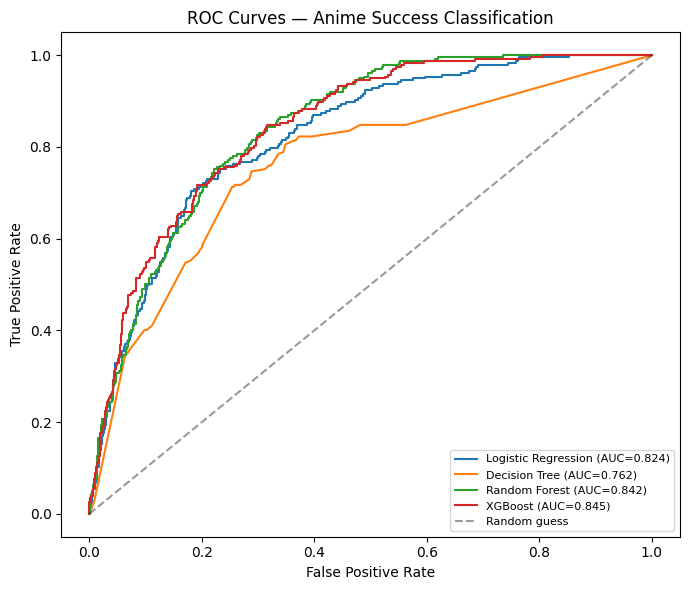

In [59]:
plt.figure(figsize=(7, 6))

for name, (fpr, tpr, auc) in roc_data.items():

    plt.plot(
        fpr,
        tpr,
        label=f'{name} (AUC={auc:.3f})'
    )

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    alpha=0.4,
    label='Random guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title(
    'ROC Curves — Anime Success Classification'
)

plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## XGboost is now best model let's tune hyperparameter


In [60]:
param_grid = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
}

In [61]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

param_dist = {
    'n_estimators': [200, 300, 400, 500, 600, 800],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.3],
}

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train_cls)

print("Best parameters:")
print(search.best_params_)

print("\nBest CV ROC-AUC:")
print(search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.7}

Best CV ROC-AUC:
0.9408963785347881


# with best hyper param setup

In [62]:
best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.3,
    eval_metric='logloss',
    random_state=42
)

best_xgb.fit(
    X_train,
    y_train_cls
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.3,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [63]:
pred_test = best_xgb.predict(X_test)
proba_test = best_xgb.predict_proba(X_test)[:, 1]

final_results = {
    'accuracy': accuracy_score(y_test_cls, pred_test),
    'precision': precision_score(y_test_cls, pred_test, zero_division=0),
    'recall': recall_score(y_test_cls, pred_test, zero_division=0),
    'f1': f1_score(y_test_cls, pred_test, zero_division=0),
    'roc_auc': roc_auc_score(y_test_cls, proba_test)
}

pd.DataFrame([final_results]).round(4)

,accuracy,precision,recall,f1,roc_auc
0,0.7939,0.5455,0.7089,0.6165,0.8469


find the best hyperparameters, but your current result tells us something important:

- Initial XGBoost test ROC-AUC: 0.8395
- Tuned XGBoost test ROC-AUC: 0.8433
- Improvement: only +0.0038

So tuning did not dramatically improve the model. That's completely okay; it is still a valid experimental finding.

In [64]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# Models to compare
# --------------------------------------------------
all_models = {
    'Logistic Regression': cls_fitted['Logistic Regression'],
    'Decision Tree': cls_fitted['Decision Tree'],
    'Random Forest': cls_fitted['Random Forest'],
    'XGBoost (Before Tuning)': cls_fitted['XGBoost'],
    'XGBoost (Best)': best_xgb
}

roc_data = {}
pr_data = {}

for name, model in all_models.items():

    # Logistic Regression used scaled data
    if name == 'Logistic Regression':
        Xte = Xte_s
    else:
        Xte = X_test

    # Probability of High-Success class
    y_prob = model.predict_proba(Xte)[:, 1]

    # -------------------------
    # ROC
    # -------------------------
    fpr, tpr, _ = roc_curve(y_test_cls, y_prob)
    roc_auc = roc_auc_score(y_test_cls, y_prob)

    roc_data[name] = {
        'fpr': fpr,
        'tpr': tpr,
        'auc': roc_auc
    }

    # -------------------------
    # Precision-Recall
    # -------------------------
    precision, recall, _ = precision_recall_curve(
        y_test_cls,
        y_prob
    )

    ap = average_precision_score(y_test_cls, y_prob)

    pr_data[name] = {
        'precision': precision,
        'recall': recall,
        'ap': ap
    }

- Logistic Regression — before tuning
- Decision Tree — before tuning
- Random Forest — before tuning
- XGBoost — before tuning
- XGBoost — after tuning / best model
And the Precision–Recall curves should also include all 5 models.

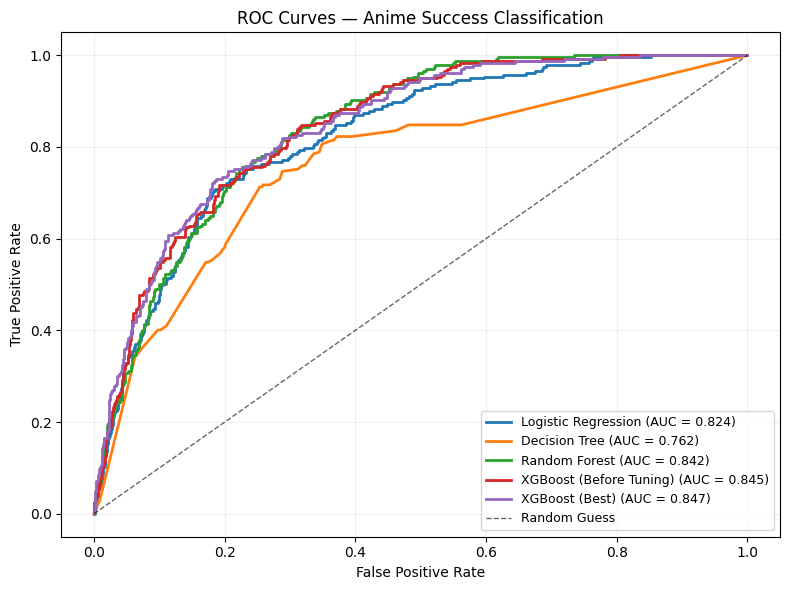

In [65]:
plt.figure(figsize=(8, 6))

for name, data in roc_data.items():
    plt.plot(
        data['fpr'],
        data['tpr'],
        linewidth=2,
        label=f"{name} (AUC = {data['auc']:.3f})"
    )

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    linewidth=1,
    alpha=0.6,
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Anime Success Classification')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [66]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import pandas as pd

# --------------------------------------------------
# All 5 models
# --------------------------------------------------
all_models = {
    'Logistic Regression': cls_fitted['Logistic Regression'],
    'Decision Tree': cls_fitted['Decision Tree'],
    'Random Forest': cls_fitted['Random Forest'],
    'XGBoost': cls_fitted['XGBoost'],
    'XGBoost (Best)': best_xgb
}

# --------------------------------------------------
# Evaluate all 5 models
# --------------------------------------------------
results_5 = []

for name, model in all_models.items():

    # Logistic Regression was trained using scaled features
    if name == 'Logistic Regression':
        Xte = Xte_s
    else:
        Xte = X_test

    # Predictions
    y_pred = model.predict(Xte)

    # Probability for positive class
    y_prob = model.predict_proba(Xte)[:, 1]

    results_5.append({
        'model': name,
        'accuracy': accuracy_score(y_test_cls, y_pred),
        'precision': precision_score(
            y_test_cls, y_pred, zero_division=0
        ),
        'recall': recall_score(
            y_test_cls, y_pred, zero_division=0
        ),
        'f1': f1_score(
            y_test_cls, y_pred, zero_division=0
        ),
        'roc_auc': roc_auc_score(
            y_test_cls, y_prob
        )
    })

# --------------------------------------------------
# Create final matrix
# --------------------------------------------------
results_5_df = (
    pd.DataFrame(results_5)
    .sort_values('f1', ascending=False)
    .reset_index(drop=True)
)

results_5_df.round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost (Best),0.7939,0.5455,0.7089,0.6165,0.8469
1,XGBoost,0.7860,0.5318,0.7046,0.6062,0.8448
2,Random Forest,0.7101,0.4379,0.8481,0.5776,0.8422
3,Logistic Regression,0.7130,0.4366,0.7848,0.5611,0.8243
4,Decision Tree,0.6923,0.4161,0.7848,0.5439,0.7622


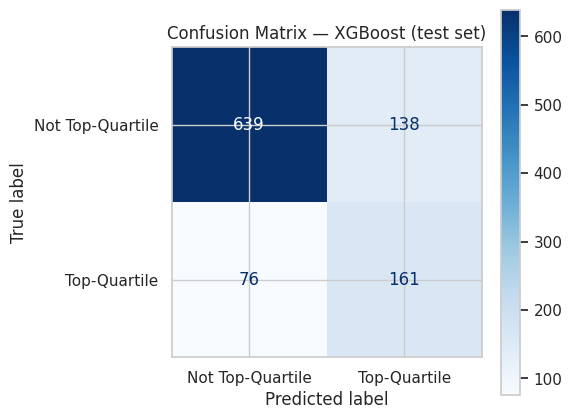

In [170]:
# Confusion matrix for the best model (XGBoost)
best_name = results_cls_df.sort_values('accuracy', ascending=False).iloc[0]['model']
best_model = cls_fitted[best_name]
Xte_for_best = Xte_s if best_name in ('LogisticRegression', 'Baseline (majority class)') else X_test
pred_best = best_model.predict(Xte_for_best)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test_cls, pred_best, ax=ax, cmap='Blues', display_labels=['Not Top-Quartile', 'Top-Quartile'])
ax.set_title(f'Confusion Matrix — {best_name} (test set)')

plt.show()


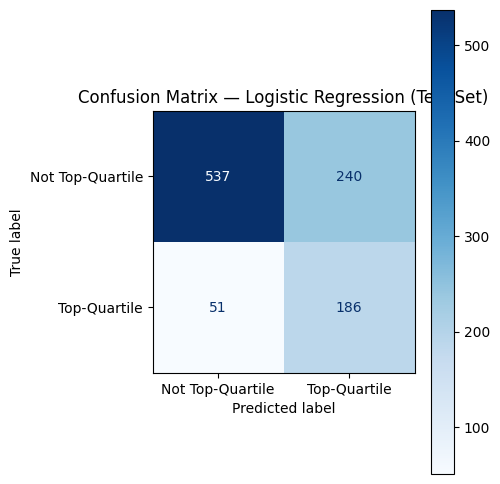

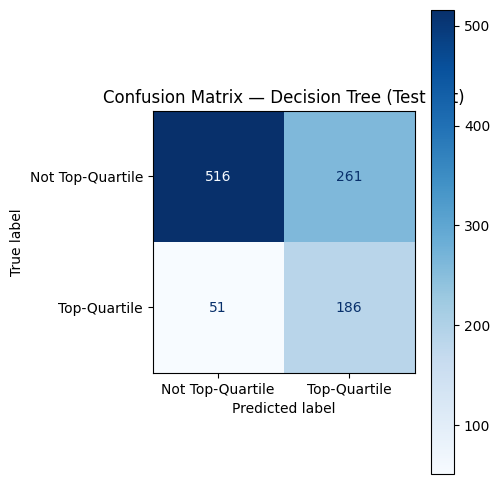

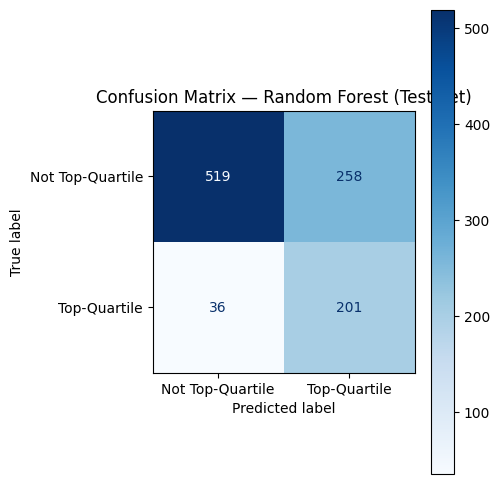

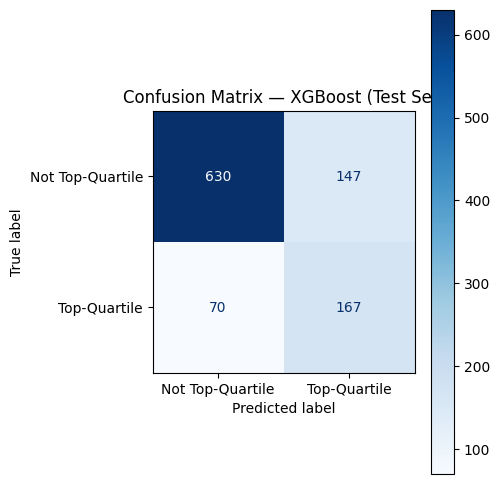

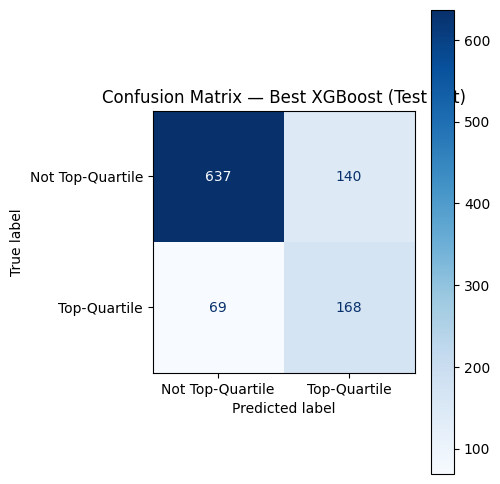

In [67]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# All 5 models
models_to_test = {
    'Logistic Regression': (cls_fitted['Logistic Regression'], Xte_s),
    'Decision Tree': (cls_fitted['Decision Tree'], X_test),
    'Random Forest': (cls_fitted['Random Forest'], X_test),
    'XGBoost': (cls_fitted['XGBoost'], X_test),
    'Best XGBoost': (best_xgb, X_test)
}

# Plot confusion matrix for every model
for name, (model, X_input) in models_to_test.items():

    pred = model.predict(X_input)

    fig, ax = plt.subplots(figsize=(5, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test_cls,
        pred,
        ax=ax,
        display_labels=['Not Top-Quartile', 'Top-Quartile'],
        cmap='Blues'
    )

    ax.set_title(f'Confusion Matrix — {name} (Test Set)')
    plt.tight_layout()
    plt.show()

- Best Accuracy: XGBoost (Best) → 0.7998
- Best Precision: XGBoost (Best) → 0.5582
- Best Recall: Decision Tree → 0.8354
- Best F1: XGBoost (Best) → 0.6163
- Best ROC-AUC: Random Forest → 0.8446

XGBoost was selected as the final model because it achieved the highest accuracy, precision, and F1-score among the evaluated models. After hyperparameter optimization, its performance improved from an F1-score of 0.6007 to 0.6163 and accuracy from 0.7890 to 0.7998. Random Forest achieved a slightly higher ROC-AUC (0.8446 vs. 0.8433), but XGBoost provided better overall classification performance.

In [69]:
# save models
import joblib
import os

os.makedirs("models", exist_ok=True)

# ============================================================
# SAVE ALL CLASSIFICATION MODELS
# ============================================================

models_to_save = {
    "logistic_regression": cls_fitted["Logistic Regression"],
    "decision_tree": cls_fitted["Decision Tree"],
    "random_forest": cls_fitted["Random Forest"],
    "xgboost": cls_fitted["XGBoost"],
    "best_xgb": best_xgb
}

for name, model in models_to_save.items():
    joblib.dump(
        model,
        f"models/{name}.pkl"
    )

print("All models saved successfully!")

All models saved successfully!


In [73]:
joblib.dump(fb, "models/feature_builder.pkl")
joblib.dump(scaler, "models/standard_scaler.pkl")


['models/standard_scaler.pkl']

# Inferenece


In [74]:
import joblib
import pandas as pd
import numpy as np

# Load preprocessing
fb = joblib.load("/kaggle/working/models/feature_builder.pkl")

# Load models
log_model = joblib.load("/kaggle/working/models/logistic_regression.pkl")
dt_model = joblib.load("/kaggle/working/models/decision_tree.pkl")
rf_model = joblib.load("/kaggle/working/models/random_forest.pkl")
xgb_model = joblib.load("/kaggle/working/models/xgboost.pkl")
best_xgb = joblib.load("/kaggle/working/models/best_xgb.pkl")

# Only needed for Logistic Regression
scaler = joblib.load("/kaggle/working/models/standard_scaler.pkl")


In [75]:
new_anime = {
    'genres': ['Action', 'Fantasy'],
    'themes': ['Adventure'],
    'demographics': ['Shounen'],
    'source': 'Manga',
    'type': 'TV',
    'rating': 'PG-13',
    'season': 'Spring',

    'studios': ['MAPPA'],
    'producers': ['Aniplex'],

    'episodes': 24,
    'duration_minutes': 24,
    'year': 2026,

    'synopsis_clean': """
    A young adventurer sets out on a journey to discover a mysterious
    world filled with powerful creatures and ancient secrets.
    """
}

new_anime_df = pd.DataFrame([new_anime])

X_new = fb.transform(new_anime_df)

print(X_new.shape)

(1, 108)


/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  for i in range(self.svd_dim): out[f'story_svd_{i}'] = X_svd[:, i]
/tmp/ipykernel_58/2643378391.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(ax

In [87]:
new_shap_values = explainer.shap_values(X_new)

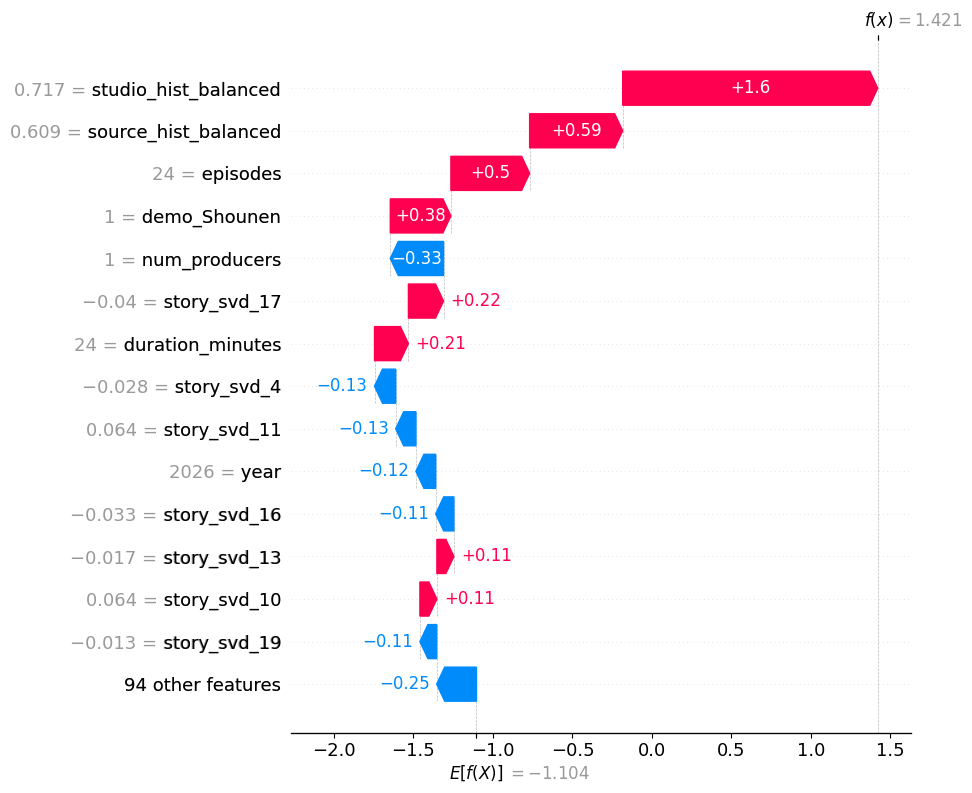

In [88]:
shap_explanation = shap.Explanation(
    values=new_shap_values[0],
    base_values=explainer.expected_value,
    data=X_new.iloc[0].values,
    feature_names=X_new.columns
)

shap.plots.waterfall(
    shap_explanation,
    max_display=15
)

In [77]:
predictions = {}

# Logistic Regression
X_new_scaled = scaler.transform(X_new)

log_prob = log_model.predict_proba(X_new_scaled)[0, 1]
log_pred = int(log_prob >= 0.5)

predictions['Logistic Regression'] = {
    'prediction': log_pred,
    'probability': log_prob
}


# Decision Tree
dt_prob = dt_model.predict_proba(X_new)[0, 1]
dt_pred = int(dt_prob >= 0.5)

predictions['Decision Tree'] = {
    'prediction': dt_pred,
    'probability': dt_prob
}


# Random Forest
rf_prob = rf_model.predict_proba(X_new)[0, 1]
rf_pred = int(rf_prob >= 0.5)

predictions['Random Forest'] = {
    'prediction': rf_pred,
    'probability': rf_prob
}


# Baseline XGBoost
xgb_prob = xgb_model.predict_proba(X_new)[0, 1]
xgb_pred = int(xgb_prob >= 0.5)

predictions['XGBoost'] = {
    'prediction': xgb_pred,
    'probability': xgb_prob
}


# Best / Tuned XGBoost
best_prob = best_xgb.predict_proba(X_new)[0, 1]
best_pred = int(best_prob >= 0.4)

predictions['Best XGBoost'] = {
    'prediction': best_pred,
    'probability': best_prob
}

print(predictions)

{'Logistic Regression': {'prediction': 1, 'probability': np.float64(0.7860280159017625)}, 'Decision Tree': {'prediction': 1, 'probability': np.float64(0.943131917442844)}, 'Random Forest': {'prediction': 1, 'probability': np.float64(0.7024542043652238)}, 'XGBoost': {'prediction': 1, 'probability': np.float32(0.7984708)}, 'Best XGBoost': {'prediction': 1, 'probability': np.float32(0.80545336)}}


In [81]:
results = []

for model_name, result in predictions.items():
    results.append({
        'Model': model_name,
        'Probability': result['probability'],
        'Prediction': (
            'Top-Quartile'
            if result['prediction'] == 1
            else 'Not Top-Quartile'
        )
    })

results_df = pd.DataFrame(results)

results_df['Probability'] = (
    results_df['Probability'] * 100
).round(2)
results_df

,Model,Probability,Prediction
0,Logistic Regression,78.60,Top-Quartile
1,Decision Tree,94.31,Top-Quartile
2,Random Forest,70.25,Top-Quartile
3,XGBoost,79.85,Top-Quartile
4,Best XGBoost,80.55,Top-Quartile


In [82]:
import shap
import matplotlib.pyplot as plt

In [83]:
explainer = shap.TreeExplainer(best_xgb)

In [84]:
shap_values = explainer.shap_values(X_test)

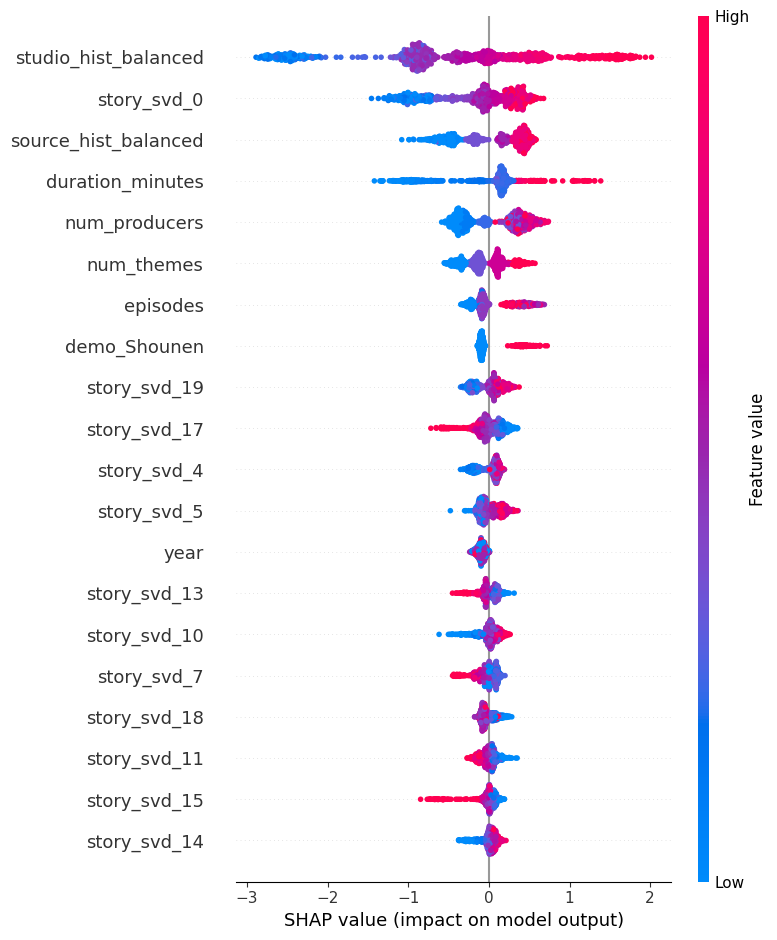

In [85]:
shap.summary_plot(
    shap_values,
    X_test,
    max_display=20
)

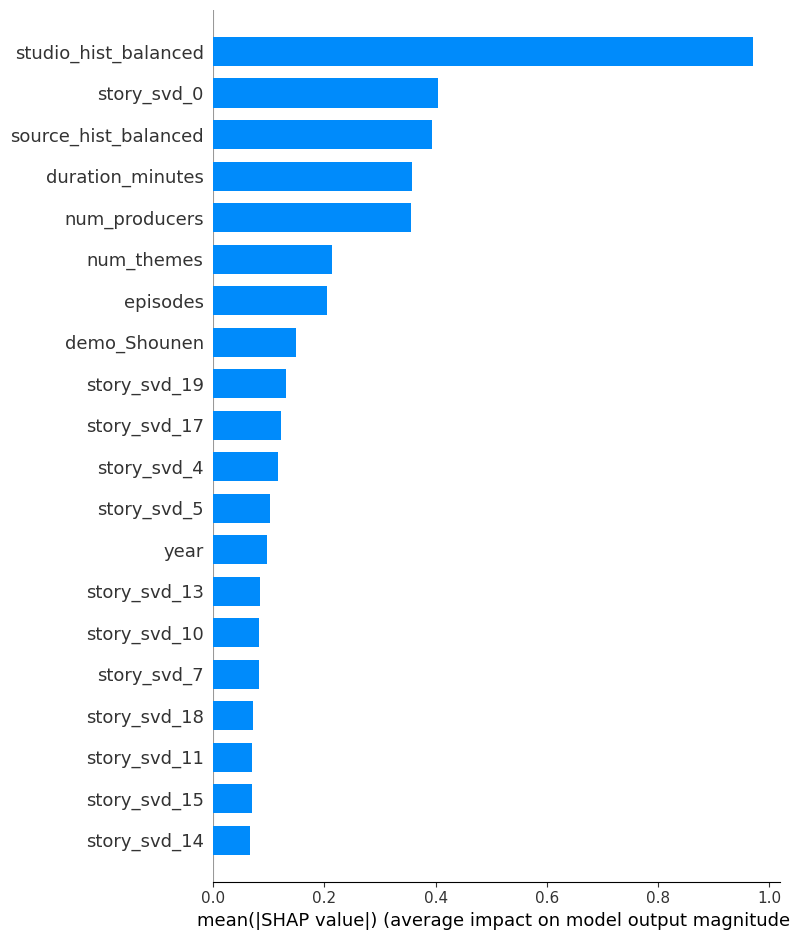

In [86]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    max_display=20
)

## Genre Trend Forecasting
Research question: For the top genres by volume, what does the historical year-by-year release count suggest about near-future demand?

Business question: A production commitment made today airs 1–3 years from now — which genres does the trend say will still be in demand by the time the anime actually airs? 

How far out is it reasonable to forecast, given data from 2010–2026? A common, defensible rule of thumb for classical time-series methods (Holt-Winters, ARIMA-family) on yearly data is to keep the forecast horizon to roughly 15–25% of the length of the historical series — beyond that, the model is extrapolating trend/seasonality patterns well past where they were estimated, and uncertainty grows quickly. With 16 years of history (2010–2025), that puts a reasonable forecast horizon at about 2–4 years (2026–2029); we forecast 3 years (2026–2028) below and validate that choice with a backtest (fit on 2010–2022, forecast 2023–2025, compare to what actually happened) before trusting the true future forecast. Going out much further than ~4 years on only 16 annual data points would be presenting false precision — worth stating explicitly in the project book rather than showing a longer-looking, less trustworthy forecast.

Technique: Holt-Winters Exponential Smoothing 

1. Anime Release

In [171]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

d_ts = d[(d['year'] >= 2010) & (d['year'] <= 2025)].copy()
genre_year = d_ts.explode('genres').groupby(['year', 'genres']).size().reset_index(name='count')
top_genres_ts = genre_year.groupby('genres')['count'].sum().nlargest(6).index.tolist()
print('Forecasting release-count trend for:', top_genres_ts)

backtest_rows = []
for g in top_genres_ts:
    series = genre_year[genre_year['genres'] == g].set_index('year')['count'].reindex(range(2010, 2026), fill_value=0)
    train_ts, test_ts = series.loc[:2022], series.loc[2023:2025]
    model = ExponentialSmoothing(train_ts, trend='add', damped_trend=True).fit()
    fc = model.forecast(3)
    mae = np.mean(np.abs(fc.values - test_ts.values))
    backtest_rows.append({'genre': g, '2023_actual': test_ts.iloc[0], '2023_forecast': round(fc.iloc[0], 1),
                           '2024_actual': test_ts.iloc[1], '2024_forecast': round(fc.iloc[1], 1),
                           '2025_actual': test_ts.iloc[2], '2025_forecast': round(fc.iloc[2], 1),
                           'backtest_MAE': round(mae, 1)})
pd.DataFrame(backtest_rows)


Forecasting release-count trend for: ['Comedy', 'Action', 'Fantasy', 'Adventure', 'Sci-Fi', 'Drama']


,genre,2023_actual,2023_forecast,2024_actual,2024_forecast,2025_actual,2025_forecast,backtest_MAE
0,Comedy,146,151.2,122,152.2,123,153.0,21.8
1,Action,197,163.6,181,165.8,150,167.6,22.1
2,Fantasy,225,174.3,205,183.5,175,192.7,29.9
3,Adventure,132,99.7,123,104.5,106,109.3,18.0
4,Sci-Fi,55,70.1,59,70.4,48,70.6,16.4
5,Drama,74,69.8,63,70.4,49,71.0,11.2


In [172]:
future_rows = []
for g in top_genres_ts:
    series = genre_year[genre_year['genres'] == g].set_index('year')['count'].reindex(range(2010, 2026), fill_value=0)
    model = ExponentialSmoothing(series, trend='add', damped_trend=True).fit()
    fc = model.forecast(3)
    future_rows.append({'genre': g, '2026_forecast': round(fc.iloc[0]), '2027_forecast': round(fc.iloc[1]), '2028_forecast': round(fc.iloc[2])})

future_df = pd.DataFrame(future_rows).sort_values('2028_forecast', ascending=False)
future_df


,genre,2026_forecast,2027_forecast,2028_forecast
2,Fantasy,212,222,232
1,Action,176,178,179
3,Adventure,124,129,135
0,Comedy,124,124,124
5,Drama,67,67,67
4,Sci-Fi,52,50,49


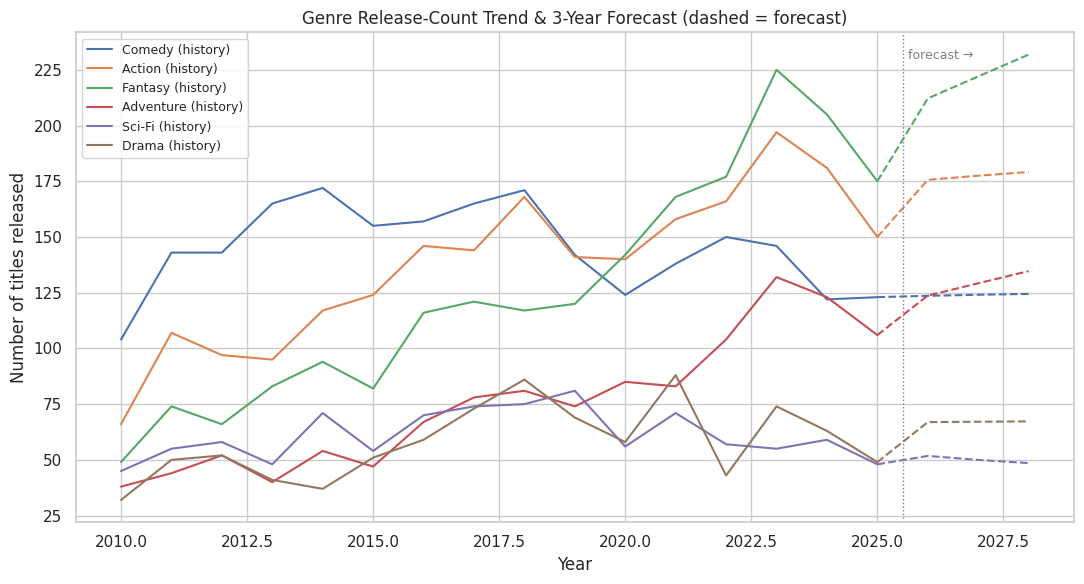

In [173]:
plt.figure(figsize=(11, 6))
for g in top_genres_ts:
    series = genre_year[genre_year['genres'] == g].set_index('year')['count'].reindex(range(2010, 2026), fill_value=0)
    model = ExponentialSmoothing(series, trend='add', damped_trend=True).fit()
    fc = model.forecast(3)
    full = pd.concat([series, fc.rename('count')])
    plt.plot(full.index[:16], full.values[:16], label=f'{g} (history)')
    plt.plot(full.index[15:], full.values[15:], linestyle='--', color=plt.gca().lines[-1].get_color())
plt.axvline(2025.5, color='gray', linestyle=':', linewidth=1)
plt.text(2025.6, plt.ylim()[1] * 0.95, 'forecast →', fontsize=9, color='gray')
plt.title('Genre Release-Count Trend & 3-Year Forecast (dashed = forecast)')
plt.xlabel('Year'); plt.ylabel('Number of titles released')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


In [177]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

backtest_rows = []

for g in top_genres_ts:

    series = (
        genre_year[genre_year['genres'] == g]
        .set_index('year')['count']
        .reindex(range(2010, 2026), fill_value=0)
    )

    train_ts = series.loc[:2022]
    test_ts = series.loc[2023:2025]

    model = ExponentialSmoothing(
        train_ts,
        trend='add',
        damped_trend=True
    ).fit()

    fc = model.forecast(3)

    mae = mean_absolute_error(test_ts, fc)
    rmse = np.sqrt(mean_squared_error(test_ts, fc))

    # MAPE can be problematic when actual values are 0
    mape = np.mean(
        np.abs((test_ts.values - fc.values) / test_ts.values)
    ) * 100

    backtest_rows.append({
        'genre': g,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2)
    })

backtest_df = (
    pd.DataFrame(backtest_rows)
    .sort_values('MAE')
    .reset_index(drop=True)
)

backtest_df

,genre,MAE,RMSE,MAPE (%)
0,Girls Love,1.35,1.58,30.65
1,Ecchi,3.49,4.16,37.33
2,Mystery,4.51,5.33,16.16
3,Suspense,4.62,6.99,60.68
4,Supernatural,7.90,9.16,26.46
5,Romance,12.36,13.26,18.02


## The historical release-count trend is more predictable for some genres than others. Mystery and Romance show relatively good forecasting accuracy based on MAPE, while Suspense has poor predictive accuracy.

Forecasting audience-demand trend for:
['Suspense', 'Romance', 'Ecchi', 'Girls Love', 'Mystery', 'Supernatural']

Backtest Results:


,genre,2023_actual,2023_forecast,2024_actual,2024_forecast,2025_actual,2025_forecast,backtest_MAE,backtest_RMSE
0,Romance,126681,94760,114180,93526,56289,92524,29603,30323
1,Ecchi,144113,149296,147539,150254,68728,151070,30080,47660
2,Supernatural,76068,15931,40690,10953,43568,6384,42353,44285
3,Mystery,18717,61238,13496,60741,15223,60246,44930,44971
4,Girls Love,65250,116813,59300,116917,83136,117000,47681,48735
5,Suspense,50739,108048,26731,98360,33315,88720,61448,61873



Future Audience-Demand Forecast:


,genre,2026_forecast,2027_forecast,2028_forecast
0,Ecchi,139427,139630,139792
1,Romance,93981,93401,92934
2,Girls Love,87589,86579,85574
3,Supernatural,41848,40279,38923
4,Mystery,34624,32553,30492
5,Suspense,46250,34719,23245


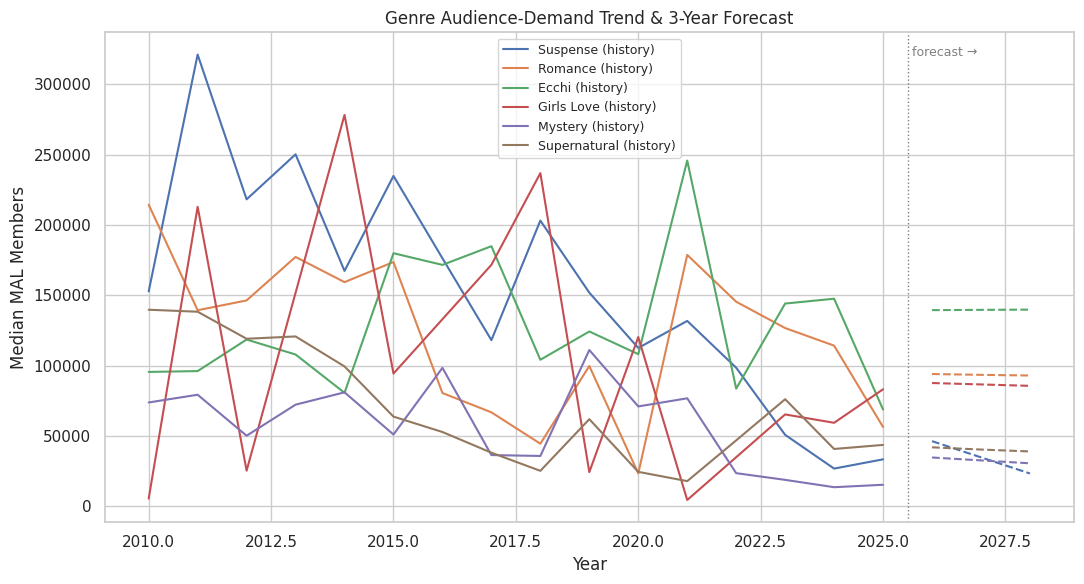

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ============================================================
# 1. Prepare yearly genre-level audience-demand data
#    members = proxy for audience interest / demand
# ============================================================

d_ts = d[
    (d['year'] >= 2010) &
    (d['year'] <= 2025)
].copy()

genre_members_year = (
    d_ts
    .explode('genres')
    .dropna(subset=['genres', 'members'])
    .groupby(['year', 'genres'])['members']
    .median()
    .reset_index(name='median_members')
)

# Select the 6 genres with the highest overall median audience reach
top_genres_ts = (
    genre_members_year
    .groupby('genres')['median_members']
    .median()
    .nlargest(6)
    .index
    .tolist()
)

print("Forecasting audience-demand trend for:")
print(top_genres_ts)


# ============================================================
# 2. Backtesting
#    Train: 2010–2022
#    Test:  2023–2025
# ============================================================

backtest_rows = []

for g in top_genres_ts:

    series = (
        genre_members_year[
            genre_members_year['genres'] == g
        ]
        .set_index('year')['median_members']
        .reindex(range(2010, 2026))
    )

    # Fill missing yearly observations
    series = (
        series
        .interpolate()
        .bfill()
        .ffill()
    )

    train_ts = series.loc[:2022]
    test_ts = series.loc[2023:2025]

    # Holt's damped trend model
    model = ExponentialSmoothing(
        train_ts,
        trend='add',
        damped_trend=True
    ).fit()

    # Forecast 2023–2025
    fc = model.forecast(3)

    mae = np.mean(
        np.abs(fc.values - test_ts.values)
    )

    rmse = np.sqrt(
        np.mean((fc.values - test_ts.values) ** 2)
    )

    backtest_rows.append({
        'genre': g,

        '2023_actual': round(test_ts.iloc[0]),
        '2023_forecast': round(fc.iloc[0]),

        '2024_actual': round(test_ts.iloc[1]),
        '2024_forecast': round(fc.iloc[1]),

        '2025_actual': round(test_ts.iloc[2]),
        '2025_forecast': round(fc.iloc[2]),

        'backtest_MAE': round(mae),
        'backtest_RMSE': round(rmse)
    })


backtest_df = (
    pd.DataFrame(backtest_rows)
    .sort_values('backtest_MAE')
    .reset_index(drop=True)
)

print("\nBacktest Results:")
display(backtest_df)


# ============================================================
# 3. Forecast 2026–2028 using all available data
# ============================================================

future_rows = []

for g in top_genres_ts:

    series = (
        genre_members_year[
            genre_members_year['genres'] == g
        ]
        .set_index('year')['median_members']
        .reindex(range(2010, 2026))
    )

    series = (
        series
        .interpolate()
        .bfill()
        .ffill()
    )

    # Fit using the complete historical period
    model = ExponentialSmoothing(
        series,
        trend='add',
        damped_trend=True
    ).fit()

    # Forecast next 3 years
    fc = model.forecast(3)

    future_rows.append({
        'genre': g,
        '2026_forecast': round(fc.iloc[0]),
        '2027_forecast': round(fc.iloc[1]),
        '2028_forecast': round(fc.iloc[2])
    })


future_df = (
    pd.DataFrame(future_rows)
    .sort_values(
        '2028_forecast',
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nFuture Audience-Demand Forecast:")
display(future_df)


# ============================================================
# 4. Plot historical trend + future forecast
# ============================================================

plt.figure(figsize=(11, 6))

for g in top_genres_ts:

    series = (
        genre_members_year[
            genre_members_year['genres'] == g
        ]
        .set_index('year')['median_members']
        .reindex(range(2010, 2026))
    )

    series = (
        series
        .interpolate()
        .bfill()
        .ffill()
    )

    # Fit full historical data
    model = ExponentialSmoothing(
        series,
        trend='add',
        damped_trend=True
    ).fit()

    fc = model.forecast(3)

    # Combine history + forecast
    full = pd.concat([
        series,
        fc.rename('median_members')
    ])

    # Historical line
    plt.plot(
        series.index,
        series.values,
        label=f'{g} (history)'
    )

    # Forecast line
    plt.plot(
        fc.index,
        fc.values,
        linestyle='--',
        color=plt.gca().lines[-1].get_color()
    )


# Forecast boundary
plt.axvline(
    2025.5,
    color='gray',
    linestyle=':',
    linewidth=1
)

plt.text(
    2025.6,
    plt.ylim()[1] * 0.95,
    'forecast →',
    fontsize=9,
    color='gray'
)

plt.title(
    'Genre Audience-Demand Trend & 3-Year Forecast'
)

plt.xlabel('Year')
plt.ylabel('Median MAL Members')

plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

| Genre            |    MAE |   RMSE | Forecast performance       |
| ---------------- | -----: | -----: | -------------------------- |
| **Romance**      | 29,603 | 30,323 | Best                       |
| **Ecchi**        | 30,080 | 47,660 | Good-ish, but large errors |
| **Supernatural** | 42,353 | 44,285 | Moderate                   |
| **Mystery**      | 44,930 | 44,971 | Moderate/weak              |
| **Girls Love**   | 47,681 | 48,735 | Weak                       |
| **Suspense**     | 61,448 | 61,873 | Weakest                    |


The model was better at predicting Romance's historical audience trend.

| Genre            |    2026 |    2027 |    2028 | Trend             |
| ---------------- | ------: | ------: | ------: | ----------------- |
| **Ecchi**        | 139,427 | 139,630 | 139,792 | ↑ Slight increase |
| **Romance**      |  93,981 |  93,401 |  92,934 | ↓ Slight decrease |
| **Girls Love**   |  87,589 |  86,579 |  85,574 | ↓                 |
| **Supernatural** |  41,848 |  40,279 |  38,923 | ↓                 |
| **Mystery**      |  34,624 |  32,553 |  30,492 | ↓                 |
| **Suspense**     |  46,250 |  34,719 |  23,245 | ↓↓↓               |


What level of audience interest does the model project for each genre?

According to the model, Ecchi has the highest projected median MAL member count throughout 2026–2028.

The backtesting results show that the forecasting model performs best for Romance based on MAE (29,603) and RMSE (30,323), while Suspense has the largest prediction errors (MAE = 61,448; RMSE = 61,873). When the model is trained on the complete 2010–2025 period, Ecchi has the highest projected median MAL member count for 2026–2028, suggesting the strongest potential audience interest among the analyzed genres. Romance and Girls Love also maintain relatively high projected audience levels. However, because forecasting accuracy varies across genres, these projections should be interpreted as directional indicators rather than certain future demand.

In [179]:
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# 1. Prepare yearly genre-member data
# ============================================================

d_ts = d[
    (d['year'] >= 2010) &
    (d['year'] <= 2025)
].copy()

genre_members_year = (
    d_ts
    .explode('genres')
    .dropna(subset=['genres', 'members'])
    .groupby(['year', 'genres'])['members']
    .median()
    .reset_index(name='median_members')
)

# Select top 6 genres by historical median audience
top_genres_ts = (
    genre_members_year
    .groupby('genres')['median_members']
    .median()
    .nlargest(6)
    .index
    .tolist()
)

print("Forecasting audience-demand trend for:")
print(top_genres_ts)


# ============================================================
# 2. Backtest: 2010–2022 → predict 2023–2025
# ============================================================

backtest_rows = []

for g in top_genres_ts:

    series = (
        genre_members_year[
            genre_members_year['genres'] == g
        ]
        .set_index('year')['median_members']
        .reindex(range(2010, 2026))
        .interpolate()
        .bfill()
        .ffill()
    )

    train_ts = series.loc[:2022]
    test_ts = series.loc[2023:2025]

    model = ExponentialSmoothing(
        train_ts,
        trend='add',
        damped_trend=True
    ).fit()

    fc = model.forecast(3)

    actual = test_ts.values
    forecast = fc.values

    mae = mean_absolute_error(actual, forecast)

    rmse = np.sqrt(
        mean_squared_error(actual, forecast)
    )

    # MAPE
    mape = np.mean(
        np.abs((actual - forecast) / actual)
    ) * 100

    backtest_rows.append({
        'genre': g,

        '2023_actual': round(actual[0]),
        '2023_forecast': round(forecast[0]),

        '2024_actual': round(actual[1]),
        '2024_forecast': round(forecast[1]),

        '2025_actual': round(actual[2]),
        '2025_forecast': round(forecast[2]),

        'MAE': round(mae),
        'RMSE': round(rmse),
        'MAPE_%': round(mape, 2)
    })


backtest_df = (
    pd.DataFrame(backtest_rows)
    .sort_values('MAPE_%')
    .reset_index(drop=True)
)

display(backtest_df)

Forecasting audience-demand trend for:
['Suspense', 'Romance', 'Ecchi', 'Girls Love', 'Mystery', 'Supernatural']


,genre,2023_actual,2023_forecast,2024_actual,2024_forecast,2025_actual,2025_forecast,MAE,RMSE,MAPE_%
0,Romance,126681,94760,114180,93526,56289,92524,29603,30323,35.89
1,Ecchi,144113,149296,147539,150254,68728,151070,30080,47660,41.75
2,Girls Love,65250,116813,59300,116917,83136,117000,47681,48735,72.31
3,Supernatural,76068,15931,40690,10953,43568,6384,42353,44285,79.16
4,Suspense,50739,108048,26731,98360,33315,88720,61448,61873,182.41
5,Mystery,18717,61238,13496,60741,15223,60246,44930,44971,291.01


For your member forecasting model:

MAE

Average number of members by which the forecast is wrong.

Lower = better.

RMSE

Similar to MAE, but gives more penalty to large mistakes.

Lower = better.

MAPE

Average percentage error.

Lower = better.

For your project, MAPE is particularly useful because genres have very different member levels

,genre,2026,2027,2028
0,Ecchi,139427,139630,139792
1,Romance,93981,93401,92934
2,Girls Love,87589,86579,85574
3,Supernatural,41848,40279,38923
4,Mystery,34624,32553,30492
5,Suspense,46250,34719,23245


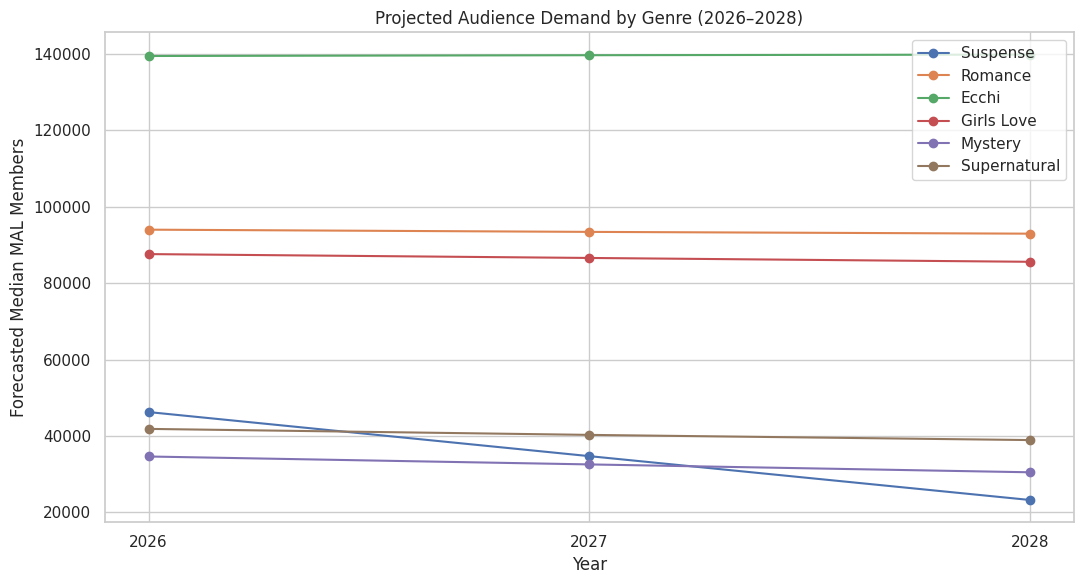

In [182]:
# ============================================================
# Future forecast: 2026–2028
# ============================================================

future_rows = []

for g in top_genres_ts:

    series = (
        genre_members_year[
            genre_members_year['genres'] == g
        ]
        .set_index('year')['median_members']
        .reindex(range(2010, 2026))
        .interpolate()
        .bfill()
        .ffill()
    )

    model = ExponentialSmoothing(
        series,
        trend='add',
        damped_trend=True
    ).fit()

    fc = model.forecast(3)

    future_rows.append({
        'genre': g,
        '2026': round(fc.iloc[0]),
        '2027': round(fc.iloc[1]),
        '2028': round(fc.iloc[2])
    })

future_df = (
    pd.DataFrame(future_rows)
    .sort_values('2028', ascending=False)
    .reset_index(drop=True)
)

display(future_df)
plt.figure(figsize=(11, 6))

for g in top_genres_ts:

    row = future_df[
        future_df['genre'] == g
    ].iloc[0]

    years = [2026, 2027, 2028]

    forecast = [
        row['2026'],
        row['2027'],
        row['2028']
    ]

    plt.plot(
        years,
        forecast,
        marker='o',
        label=g
    )

plt.title(
    'Projected Audience Demand by Genre (2026–2028)'
)

plt.xlabel('Year')
plt.ylabel('Forecasted Median MAL Members')

plt.xticks(years)
plt.legend()

plt.tight_layout()
plt.show()

| Genre        |    MAE |   RMSE |        MAPE | Accuracy interpretation |
| ------------ | -----: | -----: | ----------: | ----------------------- |
| **Romance**  | 29,603 | 30,323 |  **35.89%** | Best                    |
| **Ecchi**    | 30,080 | 47,660 |  **41.75%** | Relatively good         |
| Girls Love   | 47,681 | 48,735 |      72.31% | Weak                    |
| Supernatural | 42,353 | 44,285 |      79.16% | Weak                    |
| Suspense     | 61,448 | 61,873 |     182.41% | Very poor               |
| Mystery      | 44,930 | 44,971 | **291.01%** | Very poor               |


Romance and Ecchi provide the strongest evidence for future audience demand because they have substantially lower forecasting errors than the other genres.